# Машинное обучение и интеграция количественных ЭЭГ-признаков

Ноутбук оформлен как воспроизводимый аналитический модуль для ВКР. Логика анализа: сборка признакового пространства, контроль качества признаков, статистическая проверка, построение базовой спектральной модели, блочное сравнение групп признаков и финальная компактная событийная модель. Все ключевые расчёты выполняются на уровне субъектов, чтобы снизить риск утечки между обучающей и тестовой частями.

In [1]:
#@title Установка зависимостей
!pip -q install mne numpy scipy pandas matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 117.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [2]:
#@title Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
# @title 0. Подготовка окружения: импорты, стиль графиков, папки для результатов
# ВАЖНО: ячейка настраивает единый стиль визуализаций (контрастные цвета групп),
# создаёт структуру папок для сохранения рисунков/таблиц и задаёт вспомогательные функции.

import os
import re
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# MNE для чтения Epochs (.fif)
import mne

# tqdm для прогресса (в Colab часто уже есть)
try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# -----------------------------
# 1) Пути (можно переопределить в следующей ячейке)
# -----------------------------
STD_DIR_DEFAULT = Path("/content/drive/MyDrive/VKR/TBI/work/output/standardized")
OUT_ROOT_DEFAULT = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral")

# -----------------------------
# 2) Единый стиль графиков (контрастная палитра без полупрозрачных заливок)
# -----------------------------
# Единая палитра ВКР: контроль — тёмно-синий, ЧМТ — тёмно-красный
# ВАЖНО: set не индексируется. Эта ячейка переопределяет палитру и применяет стиль.

import matplotlib.pyplot as plt

# Единая палитра для всех графиков ВКР.
# Контроль — тёмно-синий, ЧМТ — тёмно-красный; дополнительные цвета используются для служебных графиков.
PASTEL_COLORS = [
    "#1F3B73",  # Контроль: тёмно-синий
    "#8B1E2D",  # ЧМТ: тёмно-красный
    "#90DBA5",  # нежный зелёный
    "#B8B8FF",  # лавандовый
    "#FFD166",  # пастельный янтарный
    "#9AD0EC",  # голубовато-мятный
    "#F7A1C4",  # розово-лиловый
    "#CDEAC0",  # светло-зелёный
]
color_control = "#1F3B73"   # Контроль: тёмно-синий
color_tbi = "#8B1E2D"       # ЧМТ: тёмно-красный
COLOR_CONTROL = color_control
COLOR_TBI = color_tbi

# На случай, если где-то выше палитра была set — принудительно делаем list
if not isinstance(PASTEL_COLORS, list):
    PASTEL_COLORS = list(PASTEL_COLORS)

# Применяем общий стиль с новой палитрой
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PASTEL_COLORS)

print("Готово: задана единая палитра ВКР для ML-ноутбука.")
print("PASTEL_COLORS =", PASTEL_COLORS)


STYLE = {
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 16,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "axes.grid": True,
        "grid.linestyle": "--",
}

def apply_plot_style():
    """Применяем единый стиль ко всем графикам в ноутбуке."""
    for k, v in STYLE.items():
        plt.rcParams[k] = v
    # Устанавливаем циклическую палитру
    plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PASTEL_COLORS)

def ensure_dir(path: Path) -> Path:
    """Создаём папку, если её нет."""
    path.mkdir(parents=True, exist_ok=True)
    return path

def savefig(fig, out_path: Path, tight: bool = True):
    """Сохраняем рисунок и печатаем путь (удобно для анализа)."""
    ensure_dir(out_path.parent)
    if tight:
        fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    print(f"[savefig] Сохранено изображение: {out_path}")

def show_df(df: pd.DataFrame, n: int = 5, title: str = ""):
    """Удобный вывод DataFrame (первые строки + размер)."""
    if title:
        print(title)
    print(f"Размер таблицы: {df.shape[0]} строк × {df.shape[1]} столбцов")
    display(df.head(n))

apply_plot_style()

# -----------------------------
# 3) Папки по умолчанию (можно будет поменять во 2-й ячейке)
# -----------------------------
STD_DIR = STD_DIR_DEFAULT
OUT_ROOT = OUT_ROOT_DEFAULT

OUT_FIG = ensure_dir(OUT_ROOT / "figures")
OUT_TAB = ensure_dir(OUT_ROOT / "tables")
OUT_LOG = ensure_dir(OUT_ROOT / "logs")
OUT_CACHE = ensure_dir(OUT_ROOT / "cache")

print("Готово.")
print(f"STD_DIR  = {STD_DIR}")
print(f"OUT_ROOT = {OUT_ROOT}")
print("Папки результатов:")
print(f"  figures: {OUT_FIG}")
print(f"  tables : {OUT_TAB}")
print(f"  logs   : {OUT_LOG}")
print(f"  cache  : {OUT_CACHE}")


Готово: задана единая палитра ВКР для ML-ноутбука.
PASTEL_COLORS = ['#1F3B73', '#8B1E2D', '#90DBA5', '#B8B8FF', '#FFD166', '#9AD0EC', '#F7A1C4', '#CDEAC0']
Готово.
STD_DIR  = /content/drive/MyDrive/VKR/TBI/work/output/standardized
OUT_ROOT = /content/drive/MyDrive/VKR/TBI/work/output/spectral
Папки результатов:
  figures: /content/drive/MyDrive/VKR/TBI/work/output/spectral/figures
  tables : /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables
  logs   : /content/drive/MyDrive/VKR/TBI/work/output/spectral/logs
  cache  : /content/drive/MyDrive/VKR/TBI/work/output/spectral/cache


## 1. Формирование единой матрицы признаков

На этом этапе объединяются признаки, рассчитанные в отдельных модулях анализа ЭЭГ. Цель блока — получить единую record-level таблицу без повторного пересчёта исходных сигналов.

In [6]:
# @title 1.1. Сборка итоговой record-level матрицы признаков

import pandas as pd
import re
from pathlib import Path


# =========================================
# 0. Пути
# =========================================
if "OUT_TAB" in globals():
    BASE_TAB = Path(OUT_TAB)
else:
    BASE_TAB = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")

BASE_TAB.mkdir(parents=True, exist_ok=True)

OUT_CORE_REC = BASE_TAB / "all_features_record_level_core.csv"
OUT_CORE_REC_MAP = BASE_TAB / "all_features_record_level_core_feature_map.csv"
OUT_CORE_REC_MISSING = BASE_TAB / "all_features_record_level_core_missing_sources.csv"


# =========================================
# 1. Источники core
# =========================================
SOURCES_CORE = [
    {
        "name": "inventory",
        "filename": "inventory_epochs_standardized.csv",
        "prefix": "meta",
        "entity_cols": [],
        "direct_wide": True,
    },
    {
        "name": "bandpower",
        "filename": "subject_level_bandpower_roi.csv",
        "prefix": "bp",
        "entity_cols": ["roi", "band"],
        "direct_wide": False,
    },
    {
        "name": "indices",
        "filename": "subject_level_indices_roi.csv",
        "prefix": "idx",
        "entity_cols": ["roi"],
        "direct_wide": False,
    },
    {
        "name": "alpha_peak",
        "filename": "subject_level_alpha_peak_metrics_roi.csv",
        "prefix": "alpha_peak",
        "entity_cols": ["roi"],
        "direct_wide": False,
    },
    {
        "name": "sef_entropy",
        "filename": "subject_level_sef95_entropy_roi.csv",
        "prefix": "spec_shape",
        "entity_cols": ["roi"],
        "direct_wide": False,
    },
    {
        "name": "aperiodic",
        "filename": "subject_level_aperiodic_and_alpha_peak_over_bg_roi.csv",
        "prefix": "aper",
        "entity_cols": ["roi"],
        "direct_wide": False,
    },
    {
        "name": "gamma_views",
        "filename": "METRIC_gamma_three_views_subject_level.csv",
        "prefix": "gamma",
        "entity_cols": ["roi"],
        "direct_wide": False,
    },
    {
        "name": "dfa",
        "filename": "LRTC_DFA_subject_level.csv",
        "prefix": "dfa",
        "entity_cols": ["roi", "band"],
        "direct_wide": False,
    },
    {
        "name": "burst",
        "filename": "BURST_subject_level_metrics.csv",
        "prefix": "burst",
        "entity_cols": ["roi", "band"],
        "direct_wide": False,
    },
    {
        "name": "tfr",
        "filename": "TFR_morlet_subject_level_metrics.csv",
        "prefix": "tfr",
        "entity_cols": ["roi", "band", "metric"],
        "direct_wide": False,
    },
    {
        "name": "conn_graph_adv",
        "filename": "CONNECTIVITY_ADV_graph_metrics_subject_level.csv",
        "prefix": "conn",
        "entity_cols": ["measure", "band"],
        "direct_wide": False,
    },
    {
        "name": "events_subject",
        "filename": "EVENTS_ADV_event_features_subject_level.csv",
        "prefix": "event",
        "entity_cols": [],
        "direct_wide": True,
    },
]

KEY_COLS = ["group", "record_id"]


# =========================================
# 2. Вспомогательные функции
# =========================================
def find_csv(filename):
    p = BASE_TAB / filename
    if p.exists():
        return p
    found = list(BASE_TAB.rglob(filename))
    return found[0] if found else None


def safe_read_csv(path):
    df = pd.read_csv(path)
    if "group" in df.columns:
        df["group"] = df["group"].astype(str)
    if "record_id" in df.columns:
        df["record_id"] = df["record_id"].astype(str)
    return df


def clean_token(x):
    s = str(x).strip().lower()
    s = s.replace(" ", "_")
    s = s.replace("/", "_per_")
    s = s.replace("%", "pct")
    s = re.sub(r"[^a-zA-Z0-9_а-яА-Я]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s


def numeric_feature_cols(df, exclude):
    cols = []
    for c in df.columns:
        if c in exclude:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(c)
    return cols


def make_wide_from_long(df, prefix, entity_cols):
    entity_cols = [c for c in entity_cols if c in df.columns]
    value_cols = numeric_feature_cols(df, exclude=KEY_COLS + entity_cols)

    if len(value_cols) == 0:
        return df[KEY_COLS].drop_duplicates().copy()

    tmp = df[KEY_COLS + entity_cols + value_cols].copy()

    if len(entity_cols) > 0:
        for c in entity_cols:
            tmp[c] = tmp[c].astype(str).map(clean_token)
        tmp["_entity_key"] = tmp[entity_cols].agg("__".join, axis=1)
    else:
        tmp["_entity_key"] = "global"

    pieces = []
    for val_col in value_cols:
        w = tmp.pivot_table(
            index=KEY_COLS,
            columns="_entity_key",
            values=val_col,
            aggfunc="first",
        )
        w.columns = [
            f"{prefix}__{clean_token(val_col)}__{clean_token(col)}"
            for col in w.columns
        ]
        pieces.append(w)

    out = pd.concat(pieces, axis=1).reset_index()
    return out


def make_prefixed_wide_numeric_only(df, prefix):
    num_cols = numeric_feature_cols(df, exclude=KEY_COLS)
    keep_cols = [c for c in KEY_COLS if c in df.columns] + num_cols
    out = df[keep_cols].copy()

    if out.duplicated(KEY_COLS).any():
        out = out.groupby(KEY_COLS, as_index=False)[num_cols].median()

    rename_map = {}
    for c in num_cols:
        rename_map[c] = f"{prefix}__{clean_token(c)}"
    out = out.rename(columns=rename_map)
    return out


# =========================================
# 3. Merge
# =========================================
merged = None
feature_map_rows = []
missing_rows = []

for src in SOURCES_CORE:
    path = find_csv(src["filename"])
    if path is None:
        missing_rows.append({
            "source_name": src["name"],
            "filename": src["filename"],
            "status": "missing",
        })
        print(f"⚠️ Не найден файл: {src['filename']}")
        continue

    print(f"Читаю: {path.name}")
    df0 = safe_read_csv(path)

    if not all(c in df0.columns for c in KEY_COLS):
        missing_rows.append({
            "source_name": src["name"],
            "filename": src["filename"],
            "status": "missing_keys",
        })
        print(f"⚠️ Пропуск {src['filename']}: нет group/record_id")
        continue

    if src["direct_wide"]:
        dfw = make_prefixed_wide_numeric_only(df0, prefix=src["prefix"])
    else:
        dfw = make_wide_from_long(df0, prefix=src["prefix"], entity_cols=src["entity_cols"])

    for c in dfw.columns:
        if c in KEY_COLS:
            continue
        feature_map_rows.append({
            "feature_name": c,
            "source_name": src["name"],
            "source_file": src["filename"],
            "source_prefix": src["prefix"],
        })

    if merged is None:
        merged = dfw.copy()
    else:
        merged = merged.merge(dfw, on=KEY_COLS, how="outer")

if merged is None:
    raise RuntimeError("Не удалось собрать record-level core матрицу.")

merged["group"] = merged["group"].astype(str)
merged["record_id"] = merged["record_id"].astype(str)
merged = merged.sort_values(["group", "record_id"]).reset_index(drop=True)

non_key = [c for c in merged.columns if c not in KEY_COLS]
drop_cols = [c for c in non_key if merged[c].isna().all()]
if len(drop_cols) > 0:
    merged = merged.drop(columns=drop_cols)

df_map = pd.DataFrame(feature_map_rows).drop_duplicates().reset_index(drop=True)
df_missing = pd.DataFrame(missing_rows)

merged.to_csv(OUT_CORE_REC, index=False, encoding="utf-8")
df_map.to_csv(OUT_CORE_REC_MAP, index=False, encoding="utf-8")
df_missing.to_csv(OUT_CORE_REC_MISSING, index=False, encoding="utf-8")

print("\n✅ RECORD-LEVEL CORE-матрица готова")
print("Путь:", OUT_CORE_REC)
print("shape =", merged.shape)
print("groups:")
print(merged["group"].value_counts(dropna=False))

display(merged.head(3))
display(df_map.head(20))
display(df_missing.head(20))

Читаю: inventory_epochs_standardized.csv
Читаю: subject_level_bandpower_roi.csv
Читаю: subject_level_indices_roi.csv
Читаю: subject_level_alpha_peak_metrics_roi.csv
Читаю: subject_level_sef95_entropy_roi.csv
Читаю: subject_level_aperiodic_and_alpha_peak_over_bg_roi.csv
Читаю: METRIC_gamma_three_views_subject_level.csv
Читаю: LRTC_DFA_subject_level.csv
Читаю: BURST_subject_level_metrics.csv
Читаю: TFR_morlet_subject_level_metrics.csv
Читаю: CONNECTIVITY_ADV_graph_metrics_subject_level.csv
Читаю: EVENTS_ADV_event_features_subject_level.csv

✅ RECORD-LEVEL CORE-матрица готова
Путь: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/all_features_record_level_core.csv
shape = (579, 657)
groups:
group
Control    364
TBI        215
Name: count, dtype: int64


,group,record_id,meta__size_mb,meta__n_epochs,meta__sfreq_hz,meta__n_channels,meta__tmin_sec,meta__tmax_sec,meta__epoch_len_sec,bp__band_fmin__central_alpha,...,event__slope_fall_uvs,event__sharpness_uv,event__z_peak,event__slow_peak_uv,event__spike_to_slow_ratio,event__n_involved_ch,event__lr_index,event__spread_rois,event__propagation_ms,event__n_events
0,Control,ctlraw_soft_sub-001_ses-1_task-EyesClosed_acq-...,21.250,48,500.0,58,0.0,3.998,3.998,8.0,...,-2192.838788,12.126265,4.162415,21.592249,0.723467,12.0,0.0,4.0,41.0,72
1,Control,ctlraw_soft_sub-001_ses-1_task-EyesClosed_acq-pre,20.365,46,500.0,58,0.0,3.998,3.998,8.0,...,-1957.175493,11.004203,4.044839,24.261977,0.786108,11.0,0.0,3.0,36.0,110
2,Control,ctlraw_soft_sub-001_ses-1_task-EyesOpen_acq-post,20.365,46,500.0,58,0.0,3.998,3.998,8.0,...,-2040.191174,11.580379,4.482171,22.131896,0.757124,10.5,0.0,3.0,46.0,144


,feature_name,source_name,source_file,source_prefix
0,meta__size_mb,inventory,inventory_epochs_standardized.csv,meta
1,meta__n_epochs,inventory,inventory_epochs_standardized.csv,meta
2,meta__sfreq_hz,inventory,inventory_epochs_standardized.csv,meta
3,meta__n_channels,inventory,inventory_epochs_standardized.csv,meta
4,meta__tmin_sec,inventory,inventory_epochs_standardized.csv,meta
5,meta__tmax_sec,inventory,inventory_epochs_standardized.csv,meta
6,meta__epoch_len_sec,inventory,inventory_epochs_standardized.csv,meta
7,bp__band_fmin__central_alpha,bandpower,subject_level_bandpower_roi.csv,bp
8,bp__band_fmin__central_beta,bandpower,subject_level_bandpower_roi.csv,bp
9,bp__band_fmin__central_delta,bandpower,subject_level_bandpower_roi.csv,bp


""


=== SHAPES ===
inventory: (579, 15)
core: (579, 779)

=== KEYS ===
inventory duplicated keys: 0
core duplicated keys: 0

=== GROUP COUNTS ===
_group_pretty
Контроль    364
ЧМТ         215
Name: count, dtype: int64
_group_pretty
Контроль    364
ЧМТ         215
Name: count, dtype: int64
До удаления:
shape: (164, 549)
Есть n_records_subject: True
Служебный файл сохранён: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/subject_level_service_covariates.csv

После удаления:
shape: (164, 548)
Есть n_records_subject: False

✅ Обновлён основной файл:
/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/subject_level_core_clean.csv

=== SAMPLE STATS ===


,_group_pretty,n_subjects,n_records,n_epochs_sum,n_epochs_median,n_epochs_q1,n_epochs_q3,file_size_mb_median,file_size_mb_q1,file_size_mb_q3,n_channels_median,sfreq_median,epoch_len_median
0,Контроль,72,364,16859,46.0,45.0,46.0,20.365,19.923,20.365,58.0,500.0,3.998
1,ЧМТ,92,215,24734,115.0,114.0,117.0,50.899,50.457,51.784,58.0,500.0,3.998



=== TABLE 2.1 ===


,Параметр,ЧМТ,Контроль
0,Число субъектов,92,72
1,Число записей,215,364
2,Число эпох,24734,16859



=== INVENTORY MISSINGNESS ===


...

,feature,missing_fraction
0,aper__alpha_peak_width_hz__temporal,0.046632
1,aper__alpha_peak_width_hz__frontal,0.020725
2,aper__alpha_peak_width_hz__central,0.006908
3,burst__mean_ibi_sec__occipital_alpha,0.003454
4,conn__small_worldness__wpli_beta,0.003454
5,burst__median_ibi_sec__occipital_alpha,0.003454
6,conn__small_worldness__pdc_delta,0.003454
7,burst__mean_amp__occipital_alpha,0.001727
8,burst__mean_dur_sec__occipital_alpha,0.001727
9,conn__small_worldness__imcoh_delta,0.001727



=== LOWEST VARIANCE FEATURES ===


,feature,variance
0,conn__asymmetry__imcoh_alpha,0.0
1,meta__sfreq_hz,0.0
2,meta__n_channels,0.0
3,bp__band_fmin__central_alpha,0.0
4,bp__band_fmin__central_beta,0.0
5,bp__band_fmin__central_delta,0.0
6,bp__band_fmin__central_gamma,0.0
7,conn__n_roi_used__coh_alpha,0.0
8,conn__n_roi_used__coh_beta,0.0
9,conn__n_roi_used__coh_delta,0.0



=== BLOCK SUMMARY ===


,block,n_features,mean_missing_fraction,max_missing_fraction
0,conn,300,0.000040,0.003454
1,bp,125,0.000000,0.000000
2,burst,100,0.000138,0.003454
3,idx,45,0.000000,0.000000
4,aper,45,0.001689,0.046632
5,dfa,40,0.000000,0.000000
6,tfr,30,0.000000,0.000000
7,alpha_peak,30,0.000000,0.000000
8,spec_shape,25,0.000000,0.000000
9,event,16,0.000000,0.000000


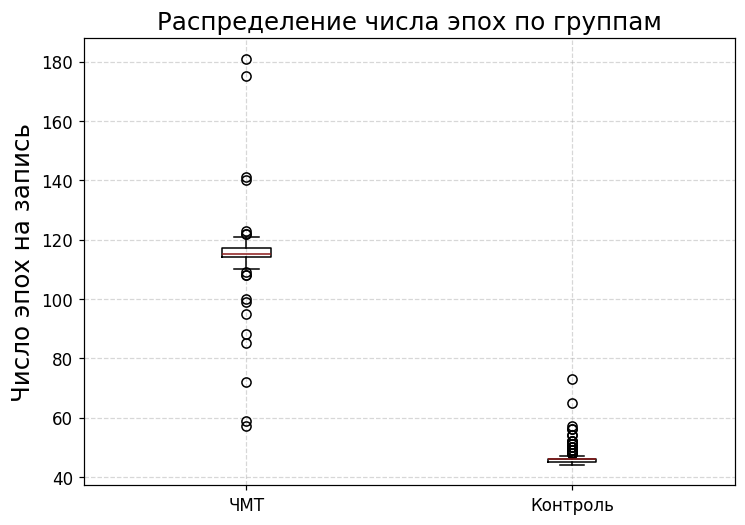

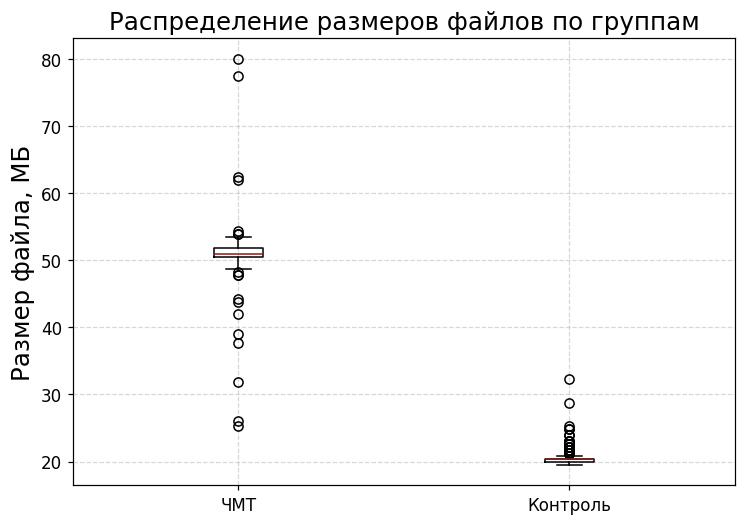

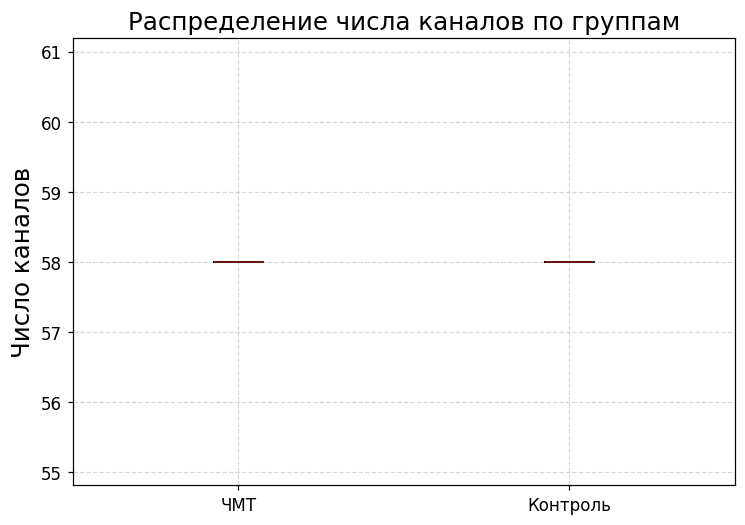

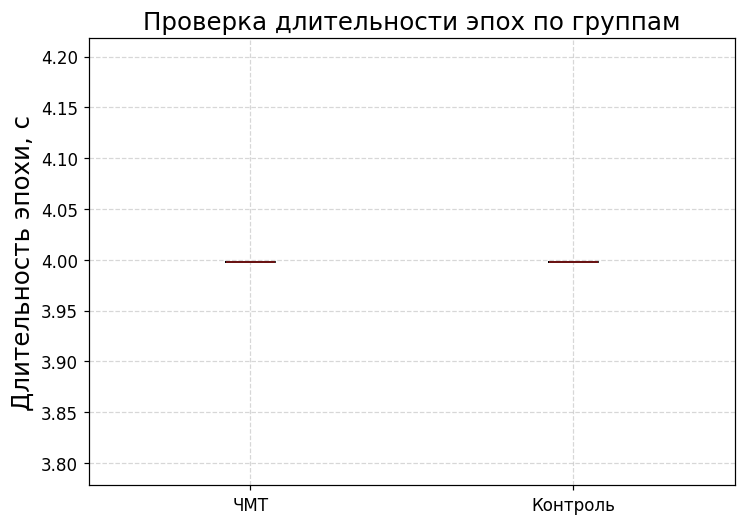

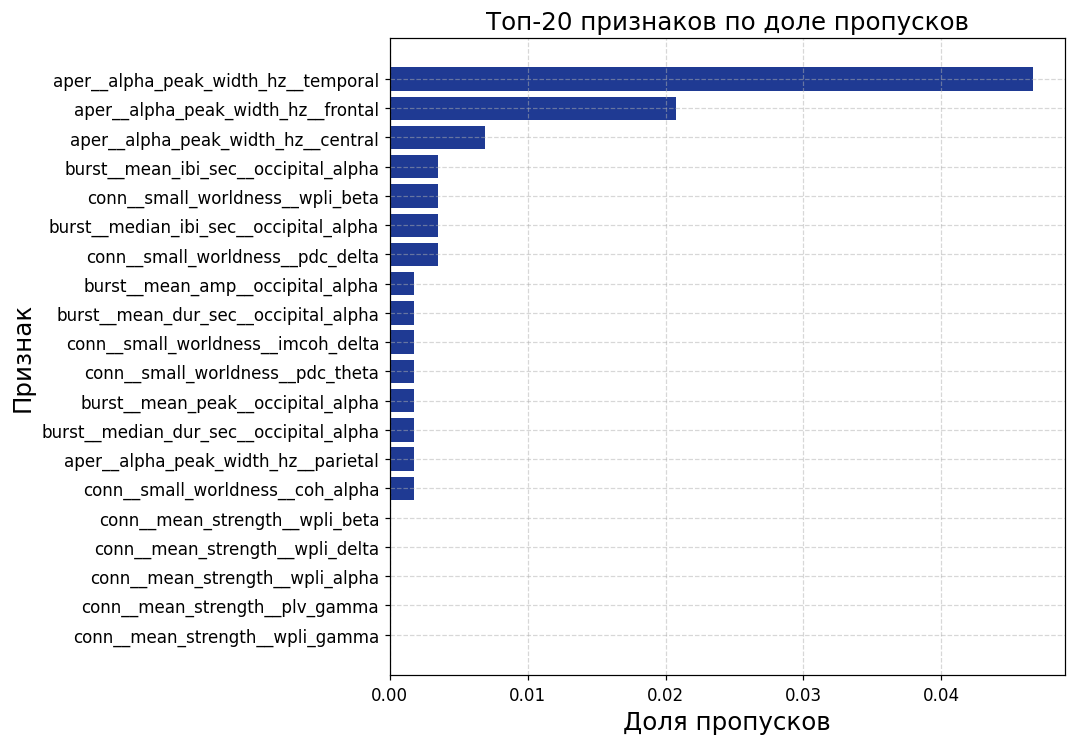

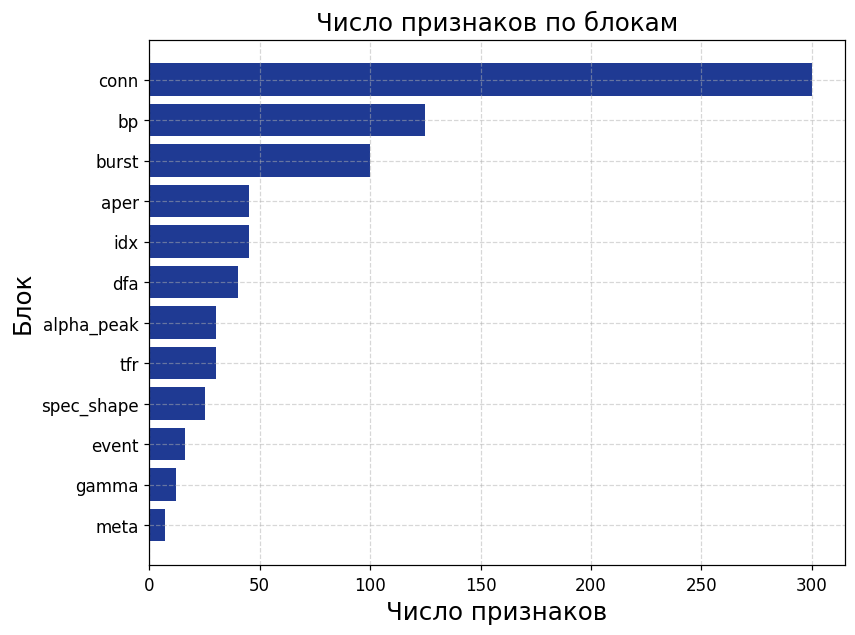


=== QC SUMMARY ===


,n_records_total,n_subjects_total,n_groups,duplicated_record_keys_inventory,duplicated_record_keys_core,median_epochs_control,median_epochs_tbi,median_channels,median_sfreq_hz,median_epoch_len_sec,core_n_features,core_mean_missing_fraction
0,579,164,2,0,0,46.0,115.0,58.0,500.0,3.998,775,0.000131



✅ Полный EDA завершён
Папка с результатами: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core


In [ ]:
# =========================================
# FULL EDA: inventory + all_features_record_level_core

# =========================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")

INV_PATH = BASE_DIR / "inventory_epochs_standardized.csv"
CORE_PATH = BASE_DIR / "all_features_record_level_core.csv"

# запасные пути для файлов, загруженных в чат
if not INV_PATH.exists():
    INV_PATH = Path("/mnt/data/inventory_epochs_standardized.csv")

if not CORE_PATH.exists():
    CORE_PATH = Path("/mnt/data/all_features_record_level_core.csv")

OUT_DIR = CORE_PATH.parent / "eda_record_level_core"
OUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================================
# 1. Загрузка
# =========================================
inv = pd.read_csv(INV_PATH)
core = pd.read_csv(CORE_PATH)

for df in [inv, core]:
    if "group" in df.columns:
        df["group"] = df["group"].astype(str).str.strip()
    if "record_id" in df.columns:
        df["record_id"] = df["record_id"].astype(str).str.strip()


# =========================================
# 2. Красивые подписи групп
# =========================================
group_map = {
    "TBI": "ЧМТ",
    "tbi": "ЧМТ",
    "Control": "Контроль",
    "control": "Контроль",
}
inv["_group_pretty"] = inv["group"].map(lambda x: group_map.get(x, x))
core["_group_pretty"] = core["group"].map(lambda x: group_map.get(x, x))


# =========================================
# 3. Восстановление subject_id из record_id
# =========================================
def infer_subject_id(record_id):
    s = str(record_id)

    # control: sub-001
    m = re.search(r"(sub-\d+)", s, flags=re.IGNORECASE)
    if m:
        return m.group(1).lower()

    # tbi: tbi_soft_3001_1_Rest -> subject = 3001
    m = re.search(r"tbi_soft_(\d+)", s, flags=re.IGNORECASE)
    if m:
        return f"tbi-{m.group(1)}"

    parts = s.split("_")
    if len(parts) >= 2:
        return "_".join(parts[:2]).lower()

    return s.lower()

inv["subject_id"] = inv["record_id"].map(infer_subject_id)
core["subject_id"] = core["record_id"].map(infer_subject_id)


# =========================================
# 4. Общая структура данных
# =========================================
print("=== SHAPES ===")
print("inventory:", inv.shape)
print("core:", core.shape)

print("\n=== KEYS ===")
print("inventory duplicated keys:", inv.duplicated(["group", "record_id"]).sum())
print("core duplicated keys:", core.duplicated(["group", "record_id"]).sum())

print("\n=== GROUP COUNTS ===")
print(inv["_group_pretty"].value_counts(dropna=False))
print(core["_group_pretty"].value_counts(dropna=False))

#  REMOVE n_records_subject FROM FINAL SUBJECT-LEVEL MATRIX


# Пути
EDA_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core")
SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"

# 1. Загрузка
df = pd.read_csv(SUBJ_PATH)

print("До удаления:")
print("shape:", df.shape)
print("Есть n_records_subject:", "n_records_subject" in df.columns)

# 2. При желании сохраняем служебную версию с covariate
if "n_records_subject" in df.columns:
    service_cols = ["group", "subject_id", "n_records_subject"]
    service_df = df[service_cols].copy()
    service_path = EDA_DIR / "subject_level_service_covariates.csv"
    service_df.to_csv(service_path, index=False, encoding="utf-8")
    print("Служебный файл сохранён:", service_path)

# 3. Удаляем из основной матрицы
df_model = df.drop(columns=["n_records_subject"], errors="ignore").copy()

print("\nПосле удаления:")
print("shape:", df_model.shape)
print("Есть n_records_subject:", "n_records_subject" in df_model.columns)

# 4. Перезаписываем основной файл
df_model.to_csv(SUBJ_PATH, index=False, encoding="utf-8")
print("\n✅ Обновлён основной файл:")
print(SUBJ_PATH)

# =========================================
# 5. Основная таблица характеристик выборки
# =========================================
sample_stats = (
    inv.groupby("_group_pretty")
    .agg(
        n_subjects=("subject_id", "nunique"),
        n_records=("record_id", "nunique"),
        n_epochs_sum=("n_epochs", "sum"),
        n_epochs_median=("n_epochs", "median"),
        n_epochs_q1=("n_epochs", lambda x: x.quantile(0.25)),
        n_epochs_q3=("n_epochs", lambda x: x.quantile(0.75)),
        file_size_mb_median=("size_mb", "median"),
        file_size_mb_q1=("size_mb", lambda x: x.quantile(0.25)),
        file_size_mb_q3=("size_mb", lambda x: x.quantile(0.75)),
        n_channels_median=("n_channels", "median"),
        sfreq_median=("sfreq_hz", "median"),
        epoch_len_median=("epoch_len_sec", "median"),
    )
    .reset_index()
)

sample_stats.to_csv(OUT_DIR / "sample_stats_by_group.csv", index=False, encoding="utf-8")

print("\n=== SAMPLE STATS ===")
display(sample_stats)


# =========================================
# 6. Маленькая таблица для текста ВКР
# =========================================
groups_order = ["ЧМТ", "Контроль"]

subj_stat = inv.groupby("_group_pretty")["subject_id"].nunique()
record_stat = inv.groupby("_group_pretty")["record_id"].nunique()
epoch_stat = inv.groupby("_group_pretty")["n_epochs"].sum()

rows = [
    {"Параметр": "Число субъектов"},
    {"Параметр": "Число записей"},
    {"Параметр": "Число эпох"},
]

for g in groups_order:
    rows[0][g] = int(subj_stat[g]) if g in subj_stat.index else "—"
    rows[1][g] = int(record_stat[g]) if g in record_stat.index else "—"
    rows[2][g] = int(epoch_stat[g]) if g in epoch_stat.index else "—"

sample_table = pd.DataFrame(rows)
sample_table.to_csv(OUT_DIR / "table_2_1_sample_characteristics.csv", index=False, encoding="utf-8")

print("\n=== TABLE 2.1 ===")
display(sample_table)


# =========================================
# 7. Проверка полноты inventory
# =========================================
inventory_missing = (
    inv.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .reset_index()
    .rename(columns={"index": "column"})
)

inventory_missing.to_csv(OUT_DIR / "inventory_missingness.csv", index=False, encoding="utf-8")

print("\n=== INVENTORY MISSINGNESS ===")
display(inventory_missing.head(20))


# =========================================
# 8. Контроль согласованности параметров
# =========================================
consistency_rows = []

for col in ["sfreq_hz", "n_channels", "epoch_len_sec", "tmin_sec", "tmax_sec"]:
    if col in inv.columns:
        vals = inv[col].dropna()
        consistency_rows.append({
            "parameter": col,
            "n_unique": vals.nunique(),
            "min": vals.min() if len(vals) else np.nan,
            "median": vals.median() if len(vals) else np.nan,
            "max": vals.max() if len(vals) else np.nan,
        })

consistency_df = pd.DataFrame(consistency_rows)
consistency_df.to_csv(OUT_DIR / "inventory_consistency_check.csv", index=False, encoding="utf-8")

print("\n=== CONSISTENCY CHECK ===")
display(consistency_df)


# =========================================
# 9. EDA по итоговой матрице признаков
# =========================================
key_cols = ["group", "record_id", "_group_pretty", "subject_id"]
feature_cols = [c for c in core.columns if c not in key_cols]
numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(core[c])]

core_num = core[numeric_cols].copy()

# пропуски по признакам
feature_missing = (
    core_num.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .reset_index()
    .rename(columns={"index": "feature"})
)

feature_missing.to_csv(OUT_DIR / "core_feature_missingness.csv", index=False, encoding="utf-8")

# околонулевая вариативность
feature_var = core_num.var(numeric_only=True)
low_var_df = (
    feature_var.sort_values()
    .rename("variance")
    .reset_index()
    .rename(columns={"index": "feature"})
)

low_var_df.to_csv(OUT_DIR / "core_feature_variance.csv", index=False, encoding="utf-8")

# базовая сводка по матрице
core_overview = pd.DataFrame([{
    "n_rows": core.shape[0],
    "n_columns_total": core.shape[1],
    "n_feature_columns": len(feature_cols),
    "n_numeric_features": len(numeric_cols),
    "mean_missing_fraction_over_features": core_num.isna().mean().mean(),
    "max_missing_fraction": core_num.isna().mean().max(),
    "n_features_with_any_missing": int((core_num.isna().mean() > 0).sum()),
    "n_features_all_missing": int((core_num.isna().mean() == 1).sum()),
    "n_features_zero_variance": int((feature_var.fillna(0) == 0).sum()),
}])

core_overview.to_csv(OUT_DIR / "core_overview.csv", index=False, encoding="utf-8")

print("\n=== CORE OVERVIEW ===")
display(core_overview)

print("\n=== TOP FEATURES BY MISSINGNESS ===")
display(feature_missing.head(20))

print("\n=== LOWEST VARIANCE FEATURES ===")
display(low_var_df.head(20))


# =========================================
# 10. Признаки по блокам / источникам
# =========================================
def extract_block_name(col):
    if "__" in col:
        return col.split("__")[0]
    return "other"

block_counts = (
    pd.Series(numeric_cols)
    .map(extract_block_name)
    .value_counts()
    .rename_axis("block")
    .reset_index(name="n_features")
)

block_missing = []
for block in block_counts["block"]:
    cols = [c for c in numeric_cols if extract_block_name(c) == block]
    block_missing.append({
        "block": block,
        "n_features": len(cols),
        "mean_missing_fraction": core_num[cols].isna().mean().mean(),
        "max_missing_fraction": core_num[cols].isna().mean().max(),
    })

block_missing_df = pd.DataFrame(block_missing).sort_values("n_features", ascending=False)
block_missing_df.to_csv(OUT_DIR / "core_blocks_summary.csv", index=False, encoding="utf-8")

print("\n=== BLOCK SUMMARY ===")
display(block_missing_df)


# =========================================
# 11. Рисунки: inventory
# =========================================
plot_group_order = ["ЧМТ", "Контроль"]
plot_data_inv = inv[inv["_group_pretty"].isin(plot_group_order)].copy()

# 11.1 число эпох
plt.figure(figsize=(7, 5))
data = [plot_data_inv.loc[plot_data_inv["_group_pretty"] == g, "n_epochs"].dropna() for g in plot_group_order]
plt.boxplot(data, tick_labels=plot_group_order)
plt.ylabel("Число эпох на запись")
plt.title("Распределение числа эпох по группам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_n_epochs_by_group.png", dpi=200, bbox_inches="tight")
plt.show()

# 11.2 размер файла
plt.figure(figsize=(7, 5))
data = [plot_data_inv.loc[plot_data_inv["_group_pretty"] == g, "size_mb"].dropna() for g in plot_group_order]
plt.boxplot(data, tick_labels=plot_group_order)
plt.ylabel("Размер файла, МБ")
plt.title("Распределение размеров файлов по группам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_size_mb_by_group.png", dpi=200, bbox_inches="tight")
plt.show()

# 11.3 число каналов
plt.figure(figsize=(7, 5))
data = [plot_data_inv.loc[plot_data_inv["_group_pretty"] == g, "n_channels"].dropna() for g in plot_group_order]
plt.boxplot(data, tick_labels=plot_group_order)
plt.ylabel("Число каналов")
plt.title("Распределение числа каналов по группам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_n_channels_by_group.png", dpi=200, bbox_inches="tight")
plt.show()

# 11.4 длительность эпох
plt.figure(figsize=(7, 5))
data = [plot_data_inv.loc[plot_data_inv["_group_pretty"] == g, "epoch_len_sec"].dropna() for g in plot_group_order]
plt.boxplot(data, tick_labels=plot_group_order)
plt.ylabel("Длительность эпохи, с")
plt.title("Проверка длительности эпох по группам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_epoch_len_by_group.png", dpi=200, bbox_inches="tight")
plt.show()


# =========================================
# 12. Рисунки: missingness и feature blocks
# =========================================
# 12.1 топ-20 признаков по пропускам
top_missing = feature_missing.head(20).copy()

plt.figure(figsize=(10, 7))
plt.barh(top_missing["feature"][::-1], top_missing["missing_fraction"][::-1])
plt.xlabel("Доля пропусков")
plt.ylabel("Признак")
plt.title("Топ-20 признаков по доле пропусков")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_top20_missing_features.png", dpi=200, bbox_inches="tight")
plt.show()

# 12.2 число признаков по блокам
tmp = block_missing_df.sort_values("n_features", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(tmp["block"], tmp["n_features"])
plt.xlabel("Число признаков")
plt.ylabel("Блок")
plt.title("Число признаков по блокам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_feature_blocks_counts.png", dpi=200, bbox_inches="tight")
plt.show()


# =========================================
# 13. Кандидаты на QC-таблицу для текста
# =========================================
qc_summary = pd.DataFrame([
    {
        "n_records_total": inv["record_id"].nunique(),
        "n_subjects_total": inv["subject_id"].nunique(),
        "n_groups": inv["_group_pretty"].nunique(),
        "duplicated_record_keys_inventory": int(inv.duplicated(["group", "record_id"]).sum()),
        "duplicated_record_keys_core": int(core.duplicated(["group", "record_id"]).sum()),
        "median_epochs_control": float(inv.loc[inv["_group_pretty"] == "Контроль", "n_epochs"].median()),
        "median_epochs_tbi": float(inv.loc[inv["_group_pretty"] == "ЧМТ", "n_epochs"].median()),
        "median_channels": float(inv["n_channels"].median()),
        "median_sfreq_hz": float(inv["sfreq_hz"].median()),
        "median_epoch_len_sec": float(inv["epoch_len_sec"].median()),
        "core_n_features": len(numeric_cols),
        "core_mean_missing_fraction": float(core_num.isna().mean().mean()),
    }
])

qc_summary.to_csv(OUT_DIR / "eda_qc_summary.csv", index=False, encoding="utf-8")

print("\n=== QC SUMMARY ===")
display(qc_summary)

print("\n✅ Полный EDA завершён")
print("Папка с результатами:", OUT_DIR)

=== SHAPES ===
inventory: (579, 15)
core: (579, 779)

=== KEYS ===
inventory duplicated keys: 0
core duplicated keys: 0

=== GROUP COUNTS ===
_group_pretty
Контроль    364
ЧМТ         215
Name: count, dtype: int64
_group_pretty
Контроль    364
ЧМТ         215
Name: count, dtype: int64

=== SAMPLE STATS ===


,_group_pretty,n_subjects,n_records,n_epochs_sum,n_epochs_median,n_epochs_q1,n_epochs_q3,file_size_mb_median,file_size_mb_q1,file_size_mb_q3,n_channels_median,sfreq_median,epoch_len_median
0,Контроль,72,364,16859,46.0,45.0,46.0,20.365,19.923,20.365,58.0,500.0,3.998
1,ЧМТ,92,215,24734,115.0,114.0,117.0,50.899,50.457,51.784,58.0,500.0,3.998



=== TABLE 2.1 ===


,Параметр,ЧМТ,Контроль
0,Число субъектов,92,72
1,Число записей,215,364
2,Число эпох,24734,16859



=== INVENTORY MISSINGNESS ===


...

,feature,missing_fraction
0,aper__alpha_peak_width_hz__temporal,0.046632
1,aper__alpha_peak_width_hz__frontal,0.020725
2,aper__alpha_peak_width_hz__central,0.006908
3,burst__mean_ibi_sec__occipital_alpha,0.003454
4,conn__small_worldness__wpli_beta,0.003454
5,burst__median_ibi_sec__occipital_alpha,0.003454
6,conn__small_worldness__pdc_delta,0.003454
7,burst__mean_amp__occipital_alpha,0.001727
8,burst__mean_dur_sec__occipital_alpha,0.001727
9,conn__small_worldness__imcoh_delta,0.001727



=== LOWEST VARIANCE FEATURES ===


,feature,variance
0,conn__asymmetry__imcoh_alpha,0.0
1,meta__sfreq_hz,0.0
2,meta__n_channels,0.0
3,bp__band_fmin__central_alpha,0.0
4,bp__band_fmin__central_beta,0.0
5,bp__band_fmin__central_delta,0.0
6,bp__band_fmin__central_gamma,0.0
7,conn__n_roi_used__coh_alpha,0.0
8,conn__n_roi_used__coh_beta,0.0
9,conn__n_roi_used__coh_delta,0.0



=== BLOCK SUMMARY ===


,block,n_features,mean_missing_fraction,max_missing_fraction
0,conn,300,0.000040,0.003454
1,bp,125,0.000000,0.000000
2,burst,100,0.000138,0.003454
3,idx,45,0.000000,0.000000
4,aper,45,0.001689,0.046632
5,dfa,40,0.000000,0.000000
6,tfr,30,0.000000,0.000000
7,alpha_peak,30,0.000000,0.000000
8,spec_shape,25,0.000000,0.000000
9,event,16,0.000000,0.000000


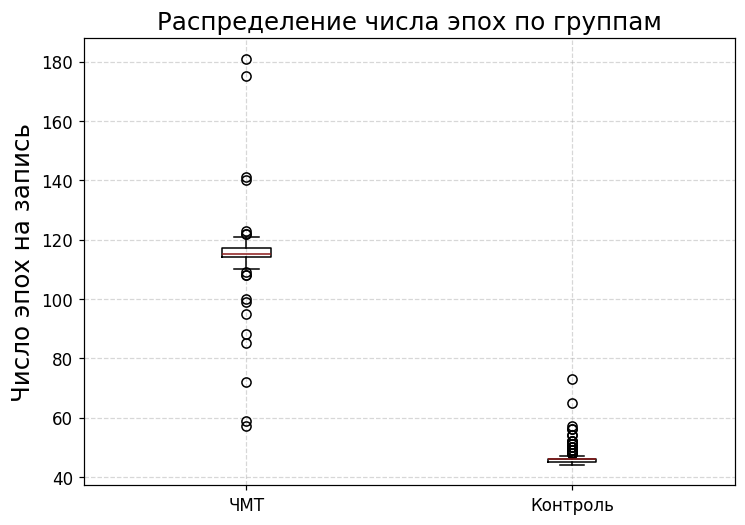

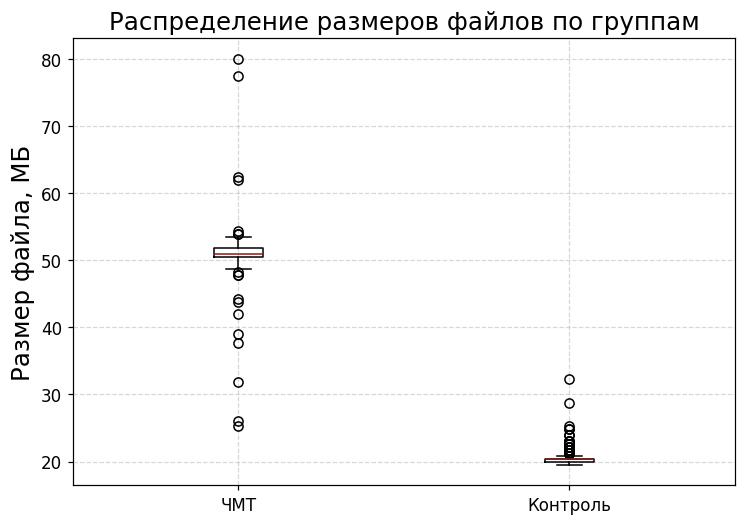

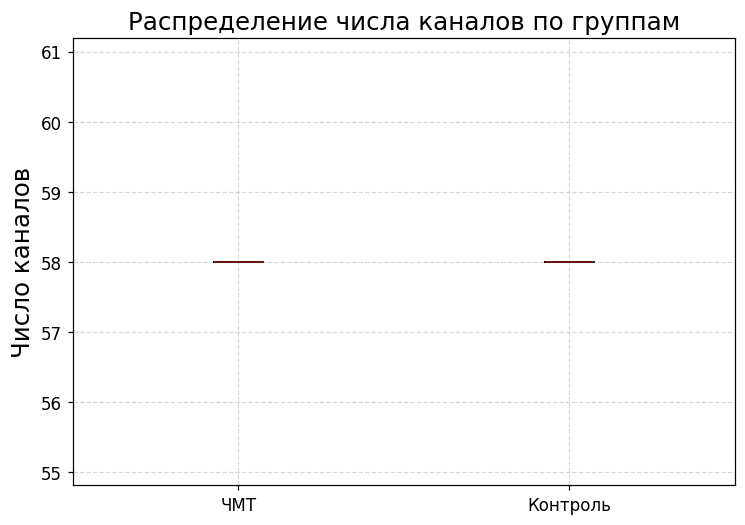

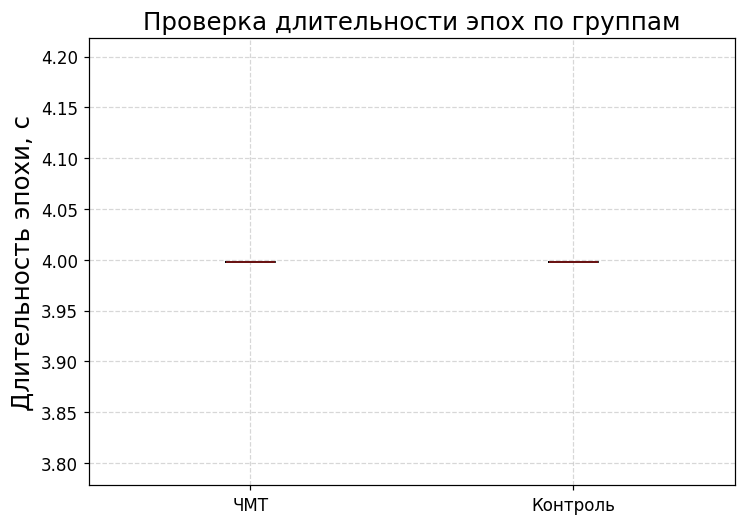

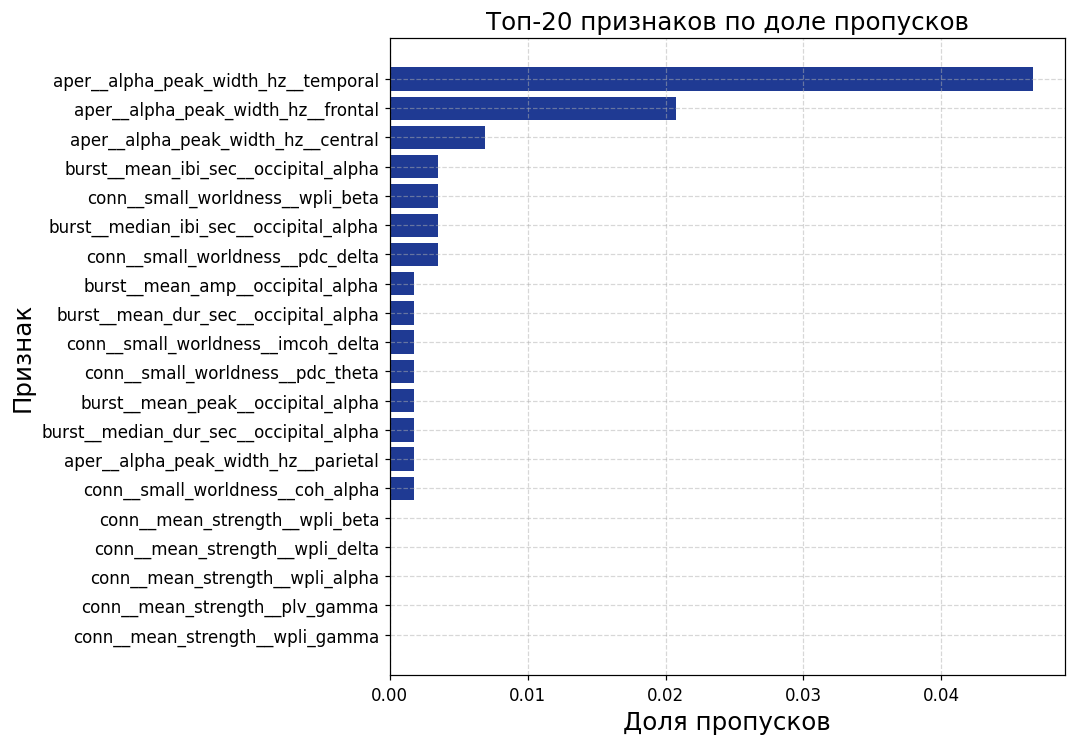

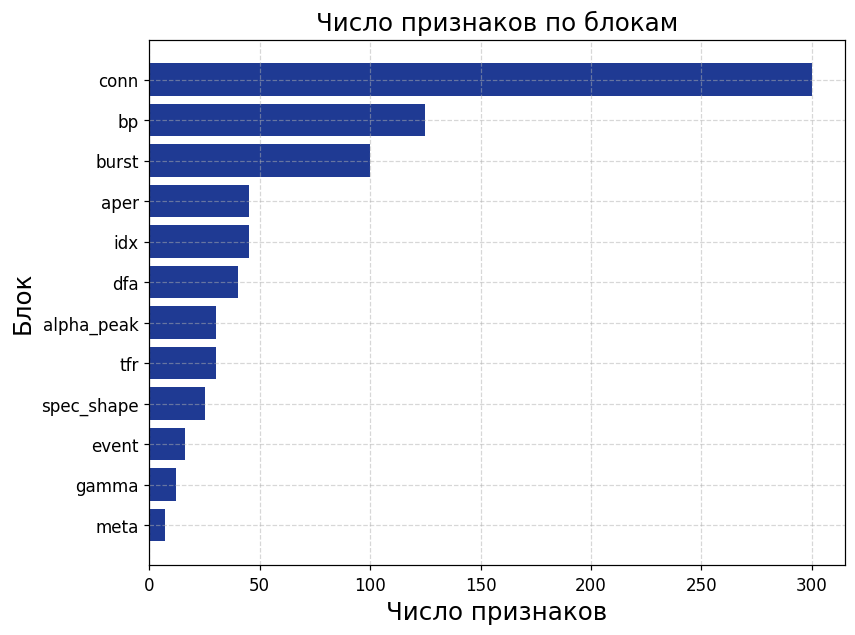


=== QC SUMMARY ===


,n_records_total,n_subjects_total,n_groups,duplicated_record_keys_inventory,duplicated_record_keys_core,median_epochs_control,median_epochs_tbi,median_channels,median_sfreq_hz,median_epoch_len_sec,core_n_features,core_mean_missing_fraction
0,579,164,2,0,0,46.0,115.0,58.0,500.0,3.998,775,0.000131



✅ Полный EDA завершён
Папка с результатами: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core


In [ ]:
# =========================================
# FULL EDA: inventory + all_features_record_level_core

# =========================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")

INV_PATH = BASE_DIR / "inventory_epochs_standardized.csv"
CORE_PATH = BASE_DIR / "all_features_record_level_core.csv"

# запасные пути для файлов, загруженных в чат
if not INV_PATH.exists():
    INV_PATH = Path("/mnt/data/inventory_epochs_standardized.csv")

if not CORE_PATH.exists():
    CORE_PATH = Path("/mnt/data/all_features_record_level_core.csv")

OUT_DIR = CORE_PATH.parent / "eda_record_level_core"
OUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================================
# 1. Загрузка
# =========================================
inv = pd.read_csv(INV_PATH)
core = pd.read_csv(CORE_PATH)

for df in [inv, core]:
    if "group" in df.columns:
        df["group"] = df["group"].astype(str).str.strip()
    if "record_id" in df.columns:
        df["record_id"] = df["record_id"].astype(str).str.strip()


# =========================================
# 2. Красивые подписи групп
# =========================================
group_map = {
    "TBI": "ЧМТ",
    "tbi": "ЧМТ",
    "Control": "Контроль",
    "control": "Контроль",
}
inv["_group_pretty"] = inv["group"].map(lambda x: group_map.get(x, x))
core["_group_pretty"] = core["group"].map(lambda x: group_map.get(x, x))


# =========================================
# 3. Восстановление subject_id из record_id
# =========================================
def infer_subject_id(record_id):
    s = str(record_id)

    # control: sub-001
    m = re.search(r"(sub-\d+)", s, flags=re.IGNORECASE)
    if m:
        return m.group(1).lower()

    # tbi: tbi_soft_3001_1_Rest -> subject = 3001
    m = re.search(r"tbi_soft_(\d+)", s, flags=re.IGNORECASE)
    if m:
        return f"tbi-{m.group(1)}"

    parts = s.split("_")
    if len(parts) >= 2:
        return "_".join(parts[:2]).lower()

    return s.lower()

inv["subject_id"] = inv["record_id"].map(infer_subject_id)
core["subject_id"] = core["record_id"].map(infer_subject_id)


# =========================================
# 4. Общая структура данных
# =========================================
print("=== SHAPES ===")
print("inventory:", inv.shape)
print("core:", core.shape)

print("\n=== KEYS ===")
print("inventory duplicated keys:", inv.duplicated(["group", "record_id"]).sum())
print("core duplicated keys:", core.duplicated(["group", "record_id"]).sum())

print("\n=== GROUP COUNTS ===")
print(inv["_group_pretty"].value_counts(dropna=False))
print(core["_group_pretty"].value_counts(dropna=False))


# =========================================
# 5. Основная таблица характеристик выборки
# =========================================
sample_stats = (
    inv.groupby("_group_pretty")
    .agg(
        n_subjects=("subject_id", "nunique"),
        n_records=("record_id", "nunique"),
        n_epochs_sum=("n_epochs", "sum"),
        n_epochs_median=("n_epochs", "median"),
        n_epochs_q1=("n_epochs", lambda x: x.quantile(0.25)),
        n_epochs_q3=("n_epochs", lambda x: x.quantile(0.75)),
        file_size_mb_median=("size_mb", "median"),
        file_size_mb_q1=("size_mb", lambda x: x.quantile(0.25)),
        file_size_mb_q3=("size_mb", lambda x: x.quantile(0.75)),
        n_channels_median=("n_channels", "median"),
        sfreq_median=("sfreq_hz", "median"),
        epoch_len_median=("epoch_len_sec", "median"),
    )
    .reset_index()
)

sample_stats.to_csv(OUT_DIR / "sample_stats_by_group.csv", index=False, encoding="utf-8")

print("\n=== SAMPLE STATS ===")
display(sample_stats)


# =========================================
# 6. Маленькая таблица для текста ВКР
# =========================================
groups_order = ["ЧМТ", "Контроль"]

subj_stat = inv.groupby("_group_pretty")["subject_id"].nunique()
record_stat = inv.groupby("_group_pretty")["record_id"].nunique()
epoch_stat = inv.groupby("_group_pretty")["n_epochs"].sum()

rows = [
    {"Параметр": "Число субъектов"},
    {"Параметр": "Число записей"},
    {"Параметр": "Число эпох"},
]

for g in groups_order:
    rows[0][g] = int(subj_stat[g]) if g in subj_stat.index else "—"
    rows[1][g] = int(record_stat[g]) if g in record_stat.index else "—"
    rows[2][g] = int(epoch_stat[g]) if g in epoch_stat.index else "—"

sample_table = pd.DataFrame(rows)
sample_table.to_csv(OUT_DIR / "table_2_1_sample_characteristics.csv", index=False, encoding="utf-8")

print("\n=== TABLE 2.1 ===")
display(sample_table)


# =========================================
# 7. Проверка полноты inventory
# =========================================
inventory_missing = (
    inv.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .reset_index()
    .rename(columns={"index": "column"})
)

inventory_missing.to_csv(OUT_DIR / "inventory_missingness.csv", index=False, encoding="utf-8")

print("\n=== INVENTORY MISSINGNESS ===")
display(inventory_missing.head(20))


# =========================================
# 8. Контроль согласованности параметров
# =========================================
consistency_rows = []

for col in ["sfreq_hz", "n_channels", "epoch_len_sec", "tmin_sec", "tmax_sec"]:
    if col in inv.columns:
        vals = inv[col].dropna()
        consistency_rows.append({
            "parameter": col,
            "n_unique": vals.nunique(),
            "min": vals.min() if len(vals) else np.nan,
            "median": vals.median() if len(vals) else np.nan,
            "max": vals.max() if len(vals) else np.nan,
        })

consistency_df = pd.DataFrame(consistency_rows)
consistency_df.to_csv(OUT_DIR / "inventory_consistency_check.csv", index=False, encoding="utf-8")

print("\n=== CONSISTENCY CHECK ===")
display(consistency_df)


# =========================================
# 9. EDA по итоговой матрице признаков
# =========================================
key_cols = ["group", "record_id", "_group_pretty", "subject_id"]
feature_cols = [c for c in core.columns if c not in key_cols]
numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(core[c])]

core_num = core[numeric_cols].copy()

# пропуски по признакам
feature_missing = (
    core_num.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .reset_index()
    .rename(columns={"index": "feature"})
)

feature_missing.to_csv(OUT_DIR / "core_feature_missingness.csv", index=False, encoding="utf-8")

# околонулевая вариативность
feature_var = core_num.var(numeric_only=True)
low_var_df = (
    feature_var.sort_values()
    .rename("variance")
    .reset_index()
    .rename(columns={"index": "feature"})
)

low_var_df.to_csv(OUT_DIR / "core_feature_variance.csv", index=False, encoding="utf-8")

# базовая сводка по матрице
core_overview = pd.DataFrame([{
    "n_rows": core.shape[0],
    "n_columns_total": core.shape[1],
    "n_feature_columns": len(feature_cols),
    "n_numeric_features": len(numeric_cols),
    "mean_missing_fraction_over_features": core_num.isna().mean().mean(),
    "max_missing_fraction": core_num.isna().mean().max(),
    "n_features_with_any_missing": int((core_num.isna().mean() > 0).sum()),
    "n_features_all_missing": int((core_num.isna().mean() == 1).sum()),
    "n_features_zero_variance": int((feature_var.fillna(0) == 0).sum()),
}])

core_overview.to_csv(OUT_DIR / "core_overview.csv", index=False, encoding="utf-8")

print("\n=== CORE OVERVIEW ===")
display(core_overview)

print("\n=== TOP FEATURES BY MISSINGNESS ===")
display(feature_missing.head(20))

print("\n=== LOWEST VARIANCE FEATURES ===")
display(low_var_df.head(20))


# =========================================
# 10. Признаки по блокам / источникам
# =========================================
def extract_block_name(col):
    if "__" in col:
        return col.split("__")[0]
    return "other"

block_counts = (
    pd.Series(numeric_cols)
    .map(extract_block_name)
    .value_counts()
    .rename_axis("block")
    .reset_index(name="n_features")
)

block_missing = []
for block in block_counts["block"]:
    cols = [c for c in numeric_cols if extract_block_name(c) == block]
    block_missing.append({
        "block": block,
        "n_features": len(cols),
        "mean_missing_fraction": core_num[cols].isna().mean().mean(),
        "max_missing_fraction": core_num[cols].isna().mean().max(),
    })

block_missing_df = pd.DataFrame(block_missing).sort_values("n_features", ascending=False)
block_missing_df.to_csv(OUT_DIR / "core_blocks_summary.csv", index=False, encoding="utf-8")

print("\n=== BLOCK SUMMARY ===")
display(block_missing_df)


# =========================================
# 11. Рисунки: inventory
# =========================================
plot_group_order = ["ЧМТ", "Контроль"]
plot_data_inv = inv[inv["_group_pretty"].isin(plot_group_order)].copy()

# 11.1 число эпох
plt.figure(figsize=(7, 5))
data = [plot_data_inv.loc[plot_data_inv["_group_pretty"] == g, "n_epochs"].dropna() for g in plot_group_order]
plt.boxplot(data, tick_labels=plot_group_order)
plt.ylabel("Число эпох на запись")
plt.title("Распределение числа эпох по группам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_n_epochs_by_group.png", dpi=200, bbox_inches="tight")
plt.show()

# 11.2 размер файла
plt.figure(figsize=(7, 5))
data = [plot_data_inv.loc[plot_data_inv["_group_pretty"] == g, "size_mb"].dropna() for g in plot_group_order]
plt.boxplot(data, tick_labels=plot_group_order)
plt.ylabel("Размер файла, МБ")
plt.title("Распределение размеров файлов по группам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_size_mb_by_group.png", dpi=200, bbox_inches="tight")
plt.show()

# 11.3 число каналов
plt.figure(figsize=(7, 5))
data = [plot_data_inv.loc[plot_data_inv["_group_pretty"] == g, "n_channels"].dropna() for g in plot_group_order]
plt.boxplot(data, tick_labels=plot_group_order)
plt.ylabel("Число каналов")
plt.title("Распределение числа каналов по группам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_n_channels_by_group.png", dpi=200, bbox_inches="tight")
plt.show()

# 11.4 длительность эпох
plt.figure(figsize=(7, 5))
data = [plot_data_inv.loc[plot_data_inv["_group_pretty"] == g, "epoch_len_sec"].dropna() for g in plot_group_order]
plt.boxplot(data, tick_labels=plot_group_order)
plt.ylabel("Длительность эпохи, с")
plt.title("Проверка длительности эпох по группам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_epoch_len_by_group.png", dpi=200, bbox_inches="tight")
plt.show()


# =========================================
# 12. Рисунки: missingness и feature blocks
# =========================================
# 12.1 топ-20 признаков по пропускам
top_missing = feature_missing.head(20).copy()

plt.figure(figsize=(10, 7))
plt.barh(top_missing["feature"][::-1], top_missing["missing_fraction"][::-1])
plt.xlabel("Доля пропусков")
plt.ylabel("Признак")
plt.title("Топ-20 признаков по доле пропусков")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_top20_missing_features.png", dpi=200, bbox_inches="tight")
plt.show()

# 12.2 число признаков по блокам
tmp = block_missing_df.sort_values("n_features", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(tmp["block"], tmp["n_features"])
plt.xlabel("Число признаков")
plt.ylabel("Блок")
plt.title("Число признаков по блокам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_feature_blocks_counts.png", dpi=200, bbox_inches="tight")
plt.show()


# =========================================
# 13. Кандидаты на QC-таблицу для текста
# =========================================
qc_summary = pd.DataFrame([
    {
        "n_records_total": inv["record_id"].nunique(),
        "n_subjects_total": inv["subject_id"].nunique(),
        "n_groups": inv["_group_pretty"].nunique(),
        "duplicated_record_keys_inventory": int(inv.duplicated(["group", "record_id"]).sum()),
        "duplicated_record_keys_core": int(core.duplicated(["group", "record_id"]).sum()),
        "median_epochs_control": float(inv.loc[inv["_group_pretty"] == "Контроль", "n_epochs"].median()),
        "median_epochs_tbi": float(inv.loc[inv["_group_pretty"] == "ЧМТ", "n_epochs"].median()),
        "median_channels": float(inv["n_channels"].median()),
        "median_sfreq_hz": float(inv["sfreq_hz"].median()),
        "median_epoch_len_sec": float(inv["epoch_len_sec"].median()),
        "core_n_features": len(numeric_cols),
        "core_mean_missing_fraction": float(core_num.isna().mean().mean()),
    }
])

qc_summary.to_csv(OUT_DIR / "eda_qc_summary.csv", index=False, encoding="utf-8")

print("\n=== QC SUMMARY ===")
display(qc_summary)

print("\n✅ Полный EDA завершён")
print("Папка с результатами:", OUT_DIR)

=== SHAPES ===
inventory: (579, 15)
core: (579, 659)

=== KEYS ===
inventory duplicated keys: 0
core duplicated keys: 0

=== GROUP COUNTS ===
_group_pretty
Контроль    364
ЧМТ         215
Name: count, dtype: int64
_group_pretty
Контроль    364
ЧМТ         215
Name: count, dtype: int64
До удаления:
shape: (164, 549)
Есть n_records_subject: True
Служебный файл сохранён: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/subject_level_service_covariates.csv

После удаления:
shape: (164, 548)
Есть n_records_subject: False

✅ Обновлён основной файл:
/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/subject_level_core_clean.csv

=== SAMPLE STATS ===


,_group_pretty,n_subjects,n_records,n_epochs_sum,n_epochs_median,n_epochs_q1,n_epochs_q3,file_size_mb_median,file_size_mb_q1,file_size_mb_q3,n_channels_median,sfreq_median,epoch_len_median
0,Контроль,72,364,16859,46.0,45.0,46.0,20.365,19.923,20.365,58.0,500.0,3.998
1,ЧМТ,92,215,24734,115.0,114.0,117.0,50.899,50.457,51.784,58.0,500.0,3.998



=== TABLE 2.1 ===


,Параметр,ЧМТ,Контроль
0,Число субъектов,92,72
1,Число записей,215,364
2,Число эпох,24734,16859



=== INVENTORY MISSINGNESS ===


...

,feature,missing_fraction
0,aper__alpha_peak_width_hz__temporal,0.046632
1,aper__alpha_peak_width_hz__frontal,0.020725
2,aper__alpha_peak_width_hz__central,0.006908
3,burst__mean_ibi_sec__occipital_alpha,0.003454
4,burst__median_ibi_sec__occipital_alpha,0.003454
5,conn__small_worldness__wpli_beta,0.003454
6,conn__small_worldness__pdc_delta,0.003454
7,burst__mean_peak__occipital_alpha,0.001727
8,burst__mean_amp__occipital_alpha,0.001727
9,conn__small_worldness__pdc_theta,0.001727



=== LOWEST VARIANCE FEATURES ===


,feature,variance
0,bp__band_fmax__central_beta,0.0
1,bp__band_fmax__central_delta,0.0
2,bp__band_fmax__central_gamma,0.0
3,bp__band_fmax__central_theta,0.0
4,bp__band_fmax__frontal_beta,0.0
5,bp__band_fmax__frontal_alpha,0.0
6,bp__band_fmax__frontal_delta,0.0
7,bp__band_fmax__frontal_gamma,0.0
8,conn__asymmetry__wpli_theta,0.0
9,bp__band_fmax__frontal_theta,0.0



=== BLOCK SUMMARY ===


,block,n_features,mean_missing_fraction,max_missing_fraction
0,conn,300,0.000040,0.003454
1,burst,100,0.000138,0.003454
2,bp,50,0.000000,0.000000
3,aper,45,0.001689,0.046632
4,dfa,40,0.000000,0.000000
5,tfr,30,0.000000,0.000000
6,alpha_peak,30,0.000000,0.000000
7,spec_shape,25,0.000000,0.000000
8,event,16,0.000000,0.000000
9,gamma,12,0.000000,0.000000


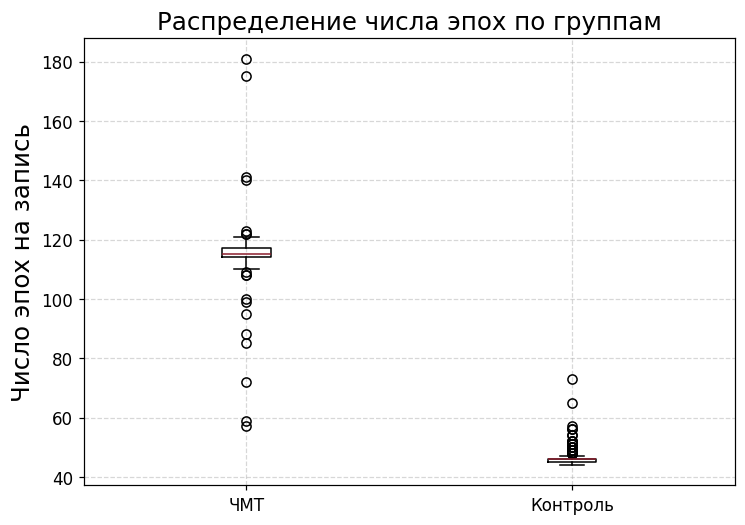

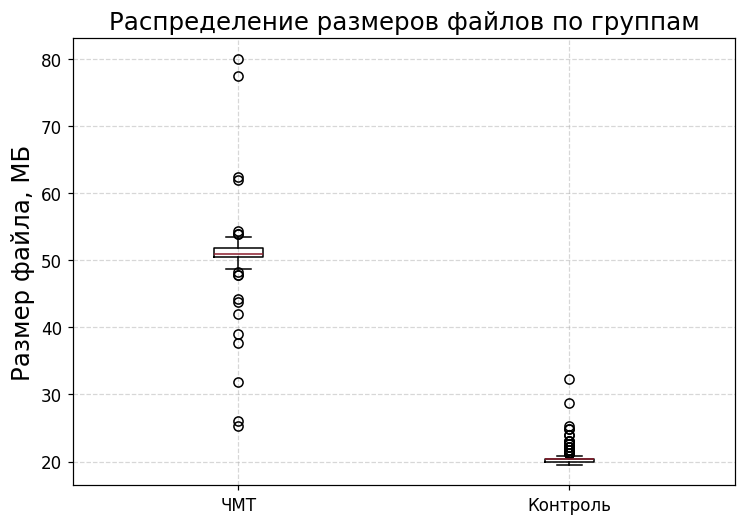

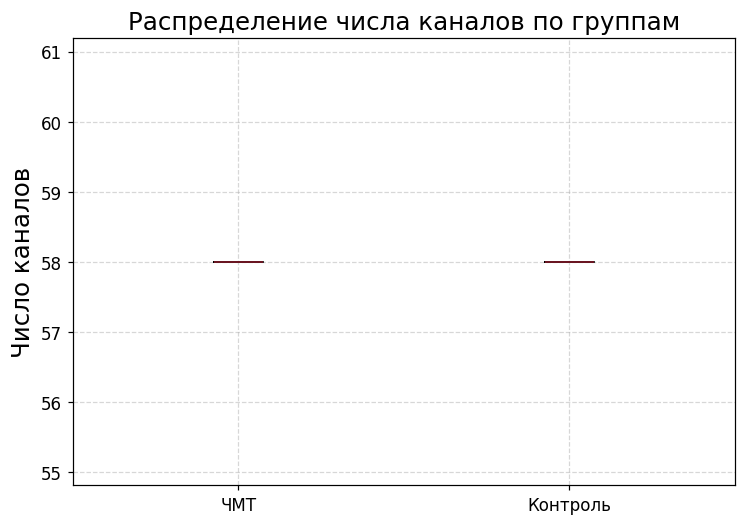

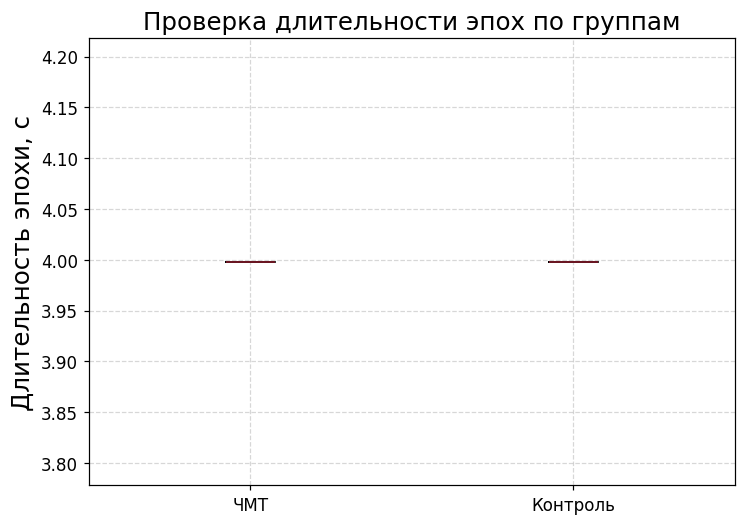

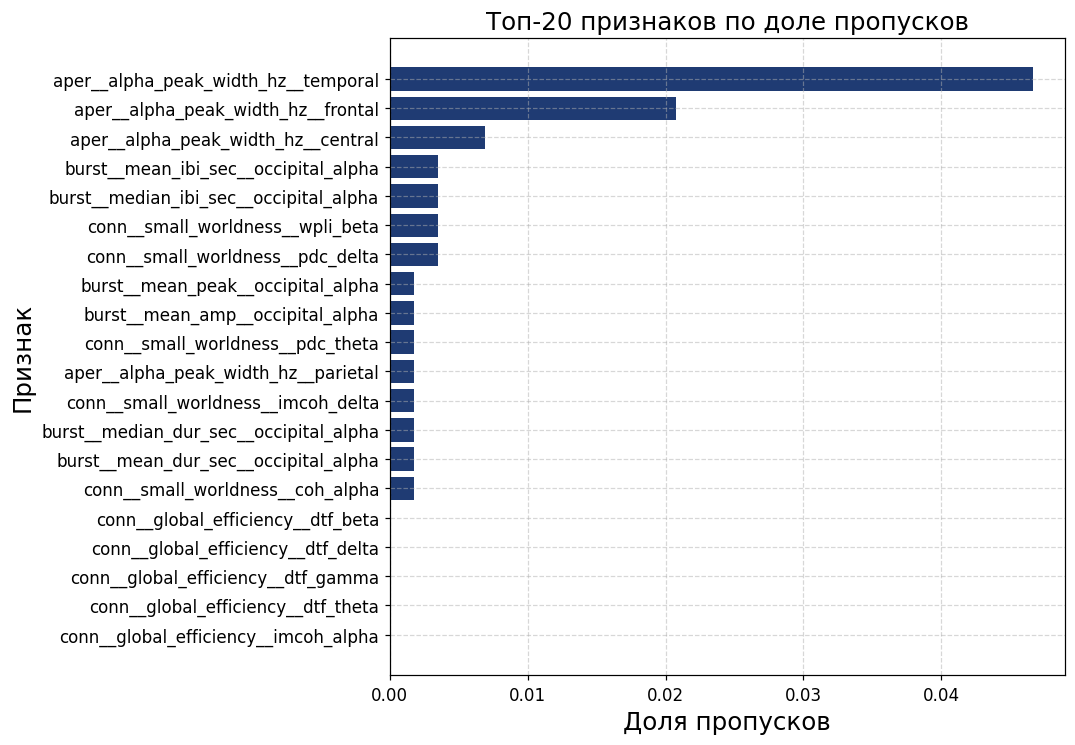

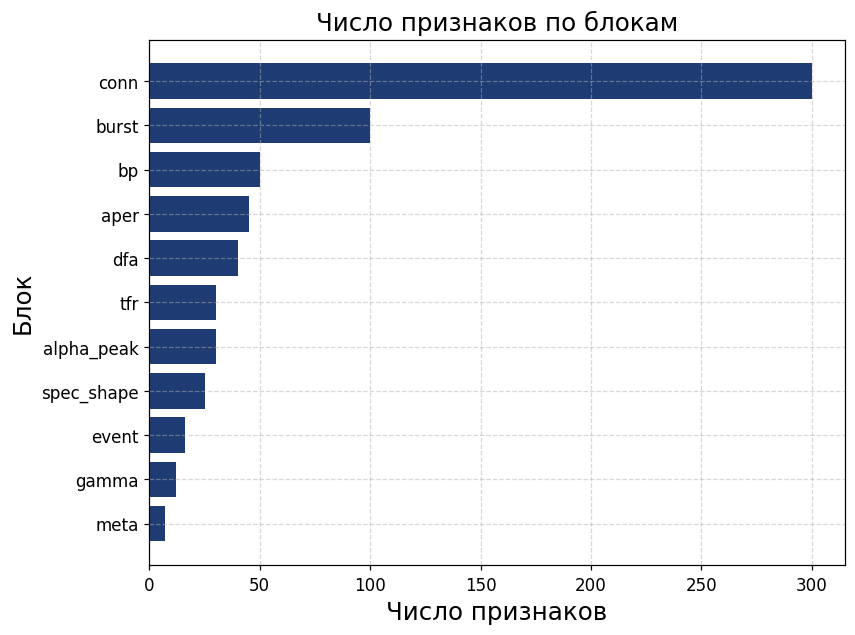


=== QC SUMMARY ===


,n_records_total,n_subjects_total,n_groups,duplicated_record_keys_inventory,duplicated_record_keys_core,median_epochs_control,median_epochs_tbi,median_channels,median_sfreq_hz,median_epoch_len_sec,core_n_features,core_mean_missing_fraction
0,579,164,2,0,0,46.0,115.0,58.0,500.0,3.998,655,0.000156



✅ Полный EDA завершён
Папка с результатами: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core


In [8]:
# @title 1.2. Проверка inventory и record-level матрицы признаков
# =========================================
# FULL EDA: inventory + all_features_record_level_core

# =========================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")

INV_PATH = BASE_DIR / "inventory_epochs_standardized.csv"
CORE_PATH = BASE_DIR / "all_features_record_level_core.csv"

# запасные пути для файлов, загруженных в чат
if not INV_PATH.exists():
    INV_PATH = Path("/mnt/data/inventory_epochs_standardized.csv")

if not CORE_PATH.exists():
    CORE_PATH = Path("/mnt/data/all_features_record_level_core.csv")

OUT_DIR = CORE_PATH.parent / "eda_record_level_core"
OUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================================
# 1. Загрузка
# =========================================
inv = pd.read_csv(INV_PATH)
core = pd.read_csv(CORE_PATH)

for df in [inv, core]:
    if "group" in df.columns:
        df["group"] = df["group"].astype(str).str.strip()
    if "record_id" in df.columns:
        df["record_id"] = df["record_id"].astype(str).str.strip()


# =========================================
# 2. Красивые подписи групп
# =========================================
group_map = {
    "TBI": "ЧМТ",
    "tbi": "ЧМТ",
    "Control": "Контроль",
    "control": "Контроль",
}
inv["_group_pretty"] = inv["group"].map(lambda x: group_map.get(x, x))
core["_group_pretty"] = core["group"].map(lambda x: group_map.get(x, x))


# =========================================
# 3. Восстановление subject_id из record_id
# =========================================
def infer_subject_id(record_id):
    s = str(record_id)

    # control: sub-001
    m = re.search(r"(sub-\d+)", s, flags=re.IGNORECASE)
    if m:
        return m.group(1).lower()

    # tbi: tbi_soft_3001_1_Rest -> subject = 3001
    m = re.search(r"tbi_soft_(\d+)", s, flags=re.IGNORECASE)
    if m:
        return f"tbi-{m.group(1)}"

    parts = s.split("_")
    if len(parts) >= 2:
        return "_".join(parts[:2]).lower()

    return s.lower()

inv["subject_id"] = inv["record_id"].map(infer_subject_id)
core["subject_id"] = core["record_id"].map(infer_subject_id)


# =========================================
# 4. Общая структура данных
# =========================================
print("=== SHAPES ===")
print("inventory:", inv.shape)
print("core:", core.shape)

print("\n=== KEYS ===")
print("inventory duplicated keys:", inv.duplicated(["group", "record_id"]).sum())
print("core duplicated keys:", core.duplicated(["group", "record_id"]).sum())

print("\n=== GROUP COUNTS ===")
print(inv["_group_pretty"].value_counts(dropna=False))
print(core["_group_pretty"].value_counts(dropna=False))

#  REMOVE n_records_subject FROM FINAL SUBJECT-LEVEL MATRIX


# Пути
EDA_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core")
SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"

# 1. Загрузка
df = pd.read_csv(SUBJ_PATH)

print("До удаления:")
print("shape:", df.shape)
print("Есть n_records_subject:", "n_records_subject" in df.columns)

# 2. При желании сохраняем служебную версию с covariate
if "n_records_subject" in df.columns:
    service_cols = ["group", "subject_id", "n_records_subject"]
    service_df = df[service_cols].copy()
    service_path = EDA_DIR / "subject_level_service_covariates.csv"
    service_df.to_csv(service_path, index=False, encoding="utf-8")
    print("Служебный файл сохранён:", service_path)

# 3. Удаляем из основной матрицы
df_model = df.drop(columns=["n_records_subject"], errors="ignore").copy()

print("\nПосле удаления:")
print("shape:", df_model.shape)
print("Есть n_records_subject:", "n_records_subject" in df_model.columns)

# 4. Перезаписываем основной файл
df_model.to_csv(SUBJ_PATH, index=False, encoding="utf-8")
print("\n✅ Обновлён основной файл:")
print(SUBJ_PATH)

# =========================================
# 5. Основная таблица характеристик выборки
# =========================================
sample_stats = (
    inv.groupby("_group_pretty")
    .agg(
        n_subjects=("subject_id", "nunique"),
        n_records=("record_id", "nunique"),
        n_epochs_sum=("n_epochs", "sum"),
        n_epochs_median=("n_epochs", "median"),
        n_epochs_q1=("n_epochs", lambda x: x.quantile(0.25)),
        n_epochs_q3=("n_epochs", lambda x: x.quantile(0.75)),
        file_size_mb_median=("size_mb", "median"),
        file_size_mb_q1=("size_mb", lambda x: x.quantile(0.25)),
        file_size_mb_q3=("size_mb", lambda x: x.quantile(0.75)),
        n_channels_median=("n_channels", "median"),
        sfreq_median=("sfreq_hz", "median"),
        epoch_len_median=("epoch_len_sec", "median"),
    )
    .reset_index()
)

sample_stats.to_csv(OUT_DIR / "sample_stats_by_group.csv", index=False, encoding="utf-8")

print("\n=== SAMPLE STATS ===")
display(sample_stats)


# =========================================
# 6. Маленькая таблица для текста ВКР
# =========================================
groups_order = ["ЧМТ", "Контроль"]

subj_stat = inv.groupby("_group_pretty")["subject_id"].nunique()
record_stat = inv.groupby("_group_pretty")["record_id"].nunique()
epoch_stat = inv.groupby("_group_pretty")["n_epochs"].sum()

rows = [
    {"Параметр": "Число субъектов"},
    {"Параметр": "Число записей"},
    {"Параметр": "Число эпох"},
]

for g in groups_order:
    rows[0][g] = int(subj_stat[g]) if g in subj_stat.index else "—"
    rows[1][g] = int(record_stat[g]) if g in record_stat.index else "—"
    rows[2][g] = int(epoch_stat[g]) if g in epoch_stat.index else "—"

sample_table = pd.DataFrame(rows)
sample_table.to_csv(OUT_DIR / "table_2_1_sample_characteristics.csv", index=False, encoding="utf-8")

print("\n=== TABLE 2.1 ===")
display(sample_table)


# =========================================
# 7. Проверка полноты inventory
# =========================================
inventory_missing = (
    inv.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .reset_index()
    .rename(columns={"index": "column"})
)

inventory_missing.to_csv(OUT_DIR / "inventory_missingness.csv", index=False, encoding="utf-8")

print("\n=== INVENTORY MISSINGNESS ===")
display(inventory_missing.head(20))


# =========================================
# 8. Контроль согласованности параметров
# =========================================
consistency_rows = []

for col in ["sfreq_hz", "n_channels", "epoch_len_sec", "tmin_sec", "tmax_sec"]:
    if col in inv.columns:
        vals = inv[col].dropna()
        consistency_rows.append({
            "parameter": col,
            "n_unique": vals.nunique(),
            "min": vals.min() if len(vals) else np.nan,
            "median": vals.median() if len(vals) else np.nan,
            "max": vals.max() if len(vals) else np.nan,
        })

consistency_df = pd.DataFrame(consistency_rows)
consistency_df.to_csv(OUT_DIR / "inventory_consistency_check.csv", index=False, encoding="utf-8")

print("\n=== CONSISTENCY CHECK ===")
display(consistency_df)


# =========================================
# 9. EDA по итоговой матрице признаков
# =========================================
key_cols = ["group", "record_id", "_group_pretty", "subject_id"]
feature_cols = [c for c in core.columns if c not in key_cols]
numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(core[c])]

core_num = core[numeric_cols].copy()

# пропуски по признакам
feature_missing = (
    core_num.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .reset_index()
    .rename(columns={"index": "feature"})
)

feature_missing.to_csv(OUT_DIR / "core_feature_missingness.csv", index=False, encoding="utf-8")

# околонулевая вариативность
feature_var = core_num.var(numeric_only=True)
low_var_df = (
    feature_var.sort_values()
    .rename("variance")
    .reset_index()
    .rename(columns={"index": "feature"})
)

low_var_df.to_csv(OUT_DIR / "core_feature_variance.csv", index=False, encoding="utf-8")

# базовая сводка по матрице
core_overview = pd.DataFrame([{
    "n_rows": core.shape[0],
    "n_columns_total": core.shape[1],
    "n_feature_columns": len(feature_cols),
    "n_numeric_features": len(numeric_cols),
    "mean_missing_fraction_over_features": core_num.isna().mean().mean(),
    "max_missing_fraction": core_num.isna().mean().max(),
    "n_features_with_any_missing": int((core_num.isna().mean() > 0).sum()),
    "n_features_all_missing": int((core_num.isna().mean() == 1).sum()),
    "n_features_zero_variance": int((feature_var.fillna(0) == 0).sum()),
}])

core_overview.to_csv(OUT_DIR / "core_overview.csv", index=False, encoding="utf-8")

print("\n=== CORE OVERVIEW ===")
display(core_overview)

print("\n=== TOP FEATURES BY MISSINGNESS ===")
display(feature_missing.head(20))

print("\n=== LOWEST VARIANCE FEATURES ===")
display(low_var_df.head(20))


# =========================================
# 10. Признаки по блокам / источникам
# =========================================
def extract_block_name(col):
    if "__" in col:
        return col.split("__")[0]
    return "other"

block_counts = (
    pd.Series(numeric_cols)
    .map(extract_block_name)
    .value_counts()
    .rename_axis("block")
    .reset_index(name="n_features")
)

block_missing = []
for block in block_counts["block"]:
    cols = [c for c in numeric_cols if extract_block_name(c) == block]
    block_missing.append({
        "block": block,
        "n_features": len(cols),
        "mean_missing_fraction": core_num[cols].isna().mean().mean(),
        "max_missing_fraction": core_num[cols].isna().mean().max(),
    })

block_missing_df = pd.DataFrame(block_missing).sort_values("n_features", ascending=False)
block_missing_df.to_csv(OUT_DIR / "core_blocks_summary.csv", index=False, encoding="utf-8")

print("\n=== BLOCK SUMMARY ===")
display(block_missing_df)


# =========================================
# 11. Рисунки: inventory
# =========================================
plot_group_order = ["ЧМТ", "Контроль"]
plot_data_inv = inv[inv["_group_pretty"].isin(plot_group_order)].copy()

# 11.1 число эпох
plt.figure(figsize=(7, 5))
data = [plot_data_inv.loc[plot_data_inv["_group_pretty"] == g, "n_epochs"].dropna() for g in plot_group_order]
plt.boxplot(data, tick_labels=plot_group_order)
plt.ylabel("Число эпох на запись")
plt.title("Распределение числа эпох по группам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_n_epochs_by_group.png", dpi=200, bbox_inches="tight")
plt.show()

# 11.2 размер файла
plt.figure(figsize=(7, 5))
data = [plot_data_inv.loc[plot_data_inv["_group_pretty"] == g, "size_mb"].dropna() for g in plot_group_order]
plt.boxplot(data, tick_labels=plot_group_order)
plt.ylabel("Размер файла, МБ")
plt.title("Распределение размеров файлов по группам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_size_mb_by_group.png", dpi=200, bbox_inches="tight")
plt.show()

# 11.3 число каналов
plt.figure(figsize=(7, 5))
data = [plot_data_inv.loc[plot_data_inv["_group_pretty"] == g, "n_channels"].dropna() for g in plot_group_order]
plt.boxplot(data, tick_labels=plot_group_order)
plt.ylabel("Число каналов")
plt.title("Распределение числа каналов по группам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_n_channels_by_group.png", dpi=200, bbox_inches="tight")
plt.show()

# 11.4 длительность эпох
plt.figure(figsize=(7, 5))
data = [plot_data_inv.loc[plot_data_inv["_group_pretty"] == g, "epoch_len_sec"].dropna() for g in plot_group_order]
plt.boxplot(data, tick_labels=plot_group_order)
plt.ylabel("Длительность эпохи, с")
plt.title("Проверка длительности эпох по группам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_epoch_len_by_group.png", dpi=200, bbox_inches="tight")
plt.show()


# =========================================
# 12. Рисунки: missingness и feature blocks
# =========================================
# 12.1 топ-20 признаков по пропускам
top_missing = feature_missing.head(20).copy()

plt.figure(figsize=(10, 7))
plt.barh(top_missing["feature"][::-1], top_missing["missing_fraction"][::-1])
plt.xlabel("Доля пропусков")
plt.ylabel("Признак")
plt.title("Топ-20 признаков по доле пропусков")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_top20_missing_features.png", dpi=200, bbox_inches="tight")
plt.show()

# 12.2 число признаков по блокам
tmp = block_missing_df.sort_values("n_features", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(tmp["block"], tmp["n_features"])
plt.xlabel("Число признаков")
plt.ylabel("Блок")
plt.title("Число признаков по блокам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_feature_blocks_counts.png", dpi=200, bbox_inches="tight")
plt.show()


# =========================================
# 13. Кандидаты на QC-таблицу для текста
# =========================================
qc_summary = pd.DataFrame([
    {
        "n_records_total": inv["record_id"].nunique(),
        "n_subjects_total": inv["subject_id"].nunique(),
        "n_groups": inv["_group_pretty"].nunique(),
        "duplicated_record_keys_inventory": int(inv.duplicated(["group", "record_id"]).sum()),
        "duplicated_record_keys_core": int(core.duplicated(["group", "record_id"]).sum()),
        "median_epochs_control": float(inv.loc[inv["_group_pretty"] == "Контроль", "n_epochs"].median()),
        "median_epochs_tbi": float(inv.loc[inv["_group_pretty"] == "ЧМТ", "n_epochs"].median()),
        "median_channels": float(inv["n_channels"].median()),
        "median_sfreq_hz": float(inv["sfreq_hz"].median()),
        "median_epoch_len_sec": float(inv["epoch_len_sec"].median()),
        "core_n_features": len(numeric_cols),
        "core_mean_missing_fraction": float(core_num.isna().mean().mean()),
    }
])

qc_summary.to_csv(OUT_DIR / "eda_qc_summary.csv", index=False, encoding="utf-8")

print("\n=== QC SUMMARY ===")
display(qc_summary)

print("\n✅ Полный EDA завершён")
print("Папка с результатами:", OUT_DIR)

=== SHAPES ===
inventory: (579, 15)
core: (579, 659)

=== KEYS ===
inventory duplicated keys: 0
core duplicated keys: 0

=== GROUP COUNTS ===
_group_pretty
Контроль    364
ЧМТ         215
Name: count, dtype: int64
_group_pretty
Контроль    364
ЧМТ         215
Name: count, dtype: int64

=== SAMPLE STATS ===


,_group_pretty,n_subjects,n_records,n_epochs_sum,n_epochs_median,n_epochs_q1,n_epochs_q3,file_size_mb_median,file_size_mb_q1,file_size_mb_q3,n_channels_median,sfreq_median,epoch_len_median
0,Контроль,72,364,16859,46.0,45.0,46.0,20.365,19.923,20.365,58.0,500.0,3.998
1,ЧМТ,92,215,24734,115.0,114.0,117.0,50.899,50.457,51.784,58.0,500.0,3.998



=== TABLE 2.1 ===


,Параметр,ЧМТ,Контроль
0,Число субъектов,92,72
1,Число записей,215,364
2,Число эпох,24734,16859



=== INVENTORY MISSINGNESS ===


...

,feature,missing_fraction
0,aper__alpha_peak_width_hz__temporal,0.046632
1,aper__alpha_peak_width_hz__frontal,0.020725
2,aper__alpha_peak_width_hz__central,0.006908
3,burst__mean_ibi_sec__occipital_alpha,0.003454
4,burst__median_ibi_sec__occipital_alpha,0.003454
5,conn__small_worldness__wpli_beta,0.003454
6,conn__small_worldness__pdc_delta,0.003454
7,burst__mean_peak__occipital_alpha,0.001727
8,burst__mean_amp__occipital_alpha,0.001727
9,conn__small_worldness__pdc_theta,0.001727



=== LOWEST VARIANCE FEATURES ===


,feature,variance
0,bp__band_fmax__central_beta,0.0
1,bp__band_fmax__central_delta,0.0
2,bp__band_fmax__central_gamma,0.0
3,bp__band_fmax__central_theta,0.0
4,bp__band_fmax__frontal_beta,0.0
5,bp__band_fmax__frontal_alpha,0.0
6,bp__band_fmax__frontal_delta,0.0
7,bp__band_fmax__frontal_gamma,0.0
8,conn__asymmetry__wpli_theta,0.0
9,bp__band_fmax__frontal_theta,0.0



=== BLOCK SUMMARY ===


,block,n_features,mean_missing_fraction,max_missing_fraction
0,conn,300,0.000040,0.003454
1,burst,100,0.000138,0.003454
2,bp,50,0.000000,0.000000
3,aper,45,0.001689,0.046632
4,dfa,40,0.000000,0.000000
5,tfr,30,0.000000,0.000000
6,alpha_peak,30,0.000000,0.000000
7,spec_shape,25,0.000000,0.000000
8,event,16,0.000000,0.000000
9,gamma,12,0.000000,0.000000


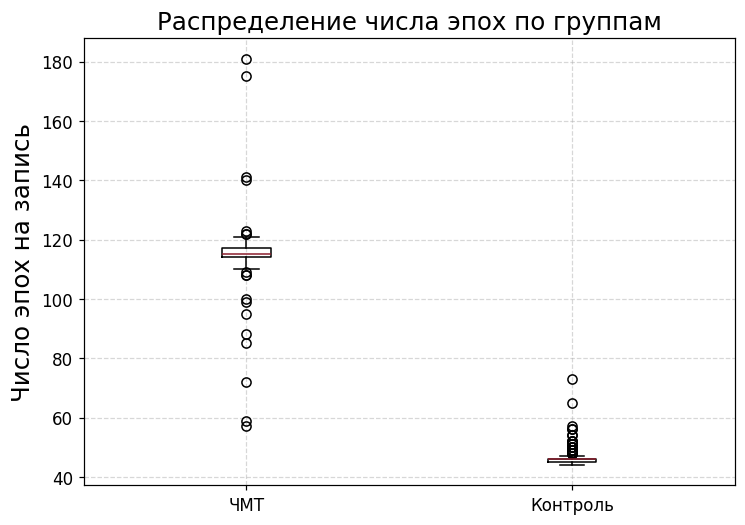

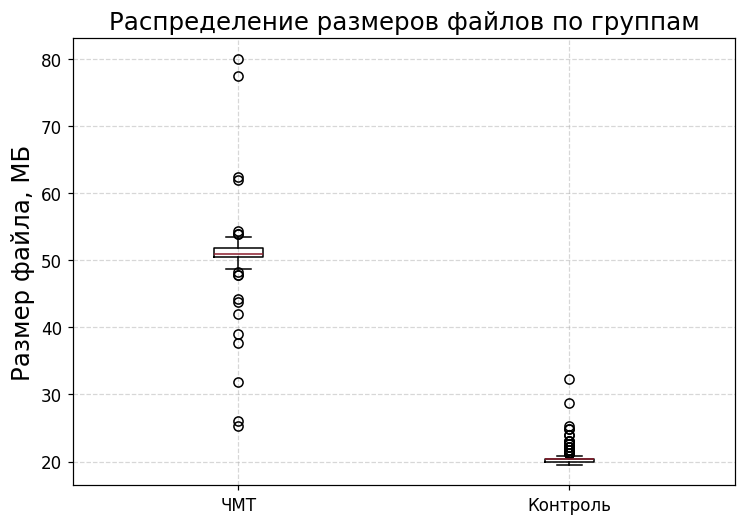

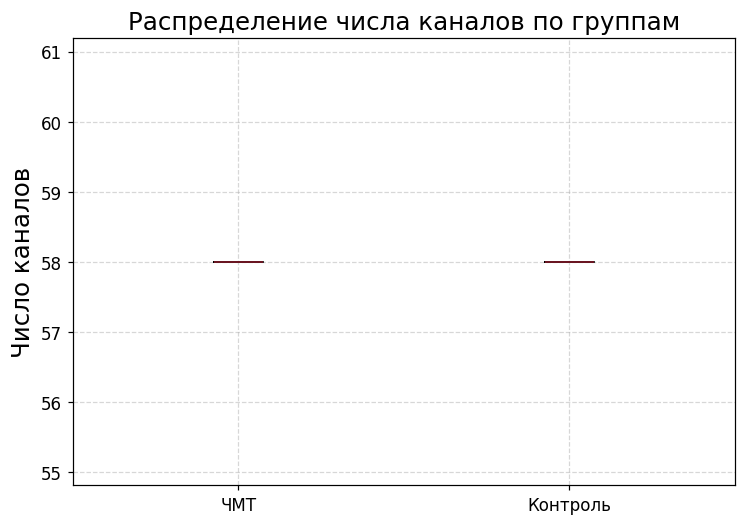

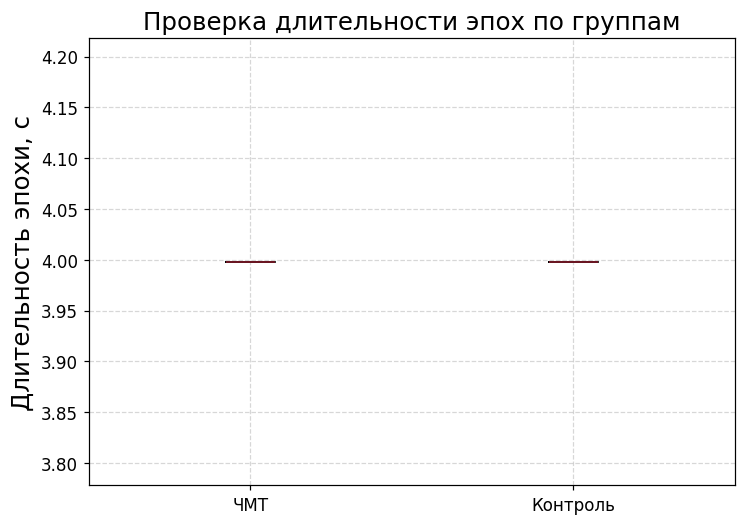

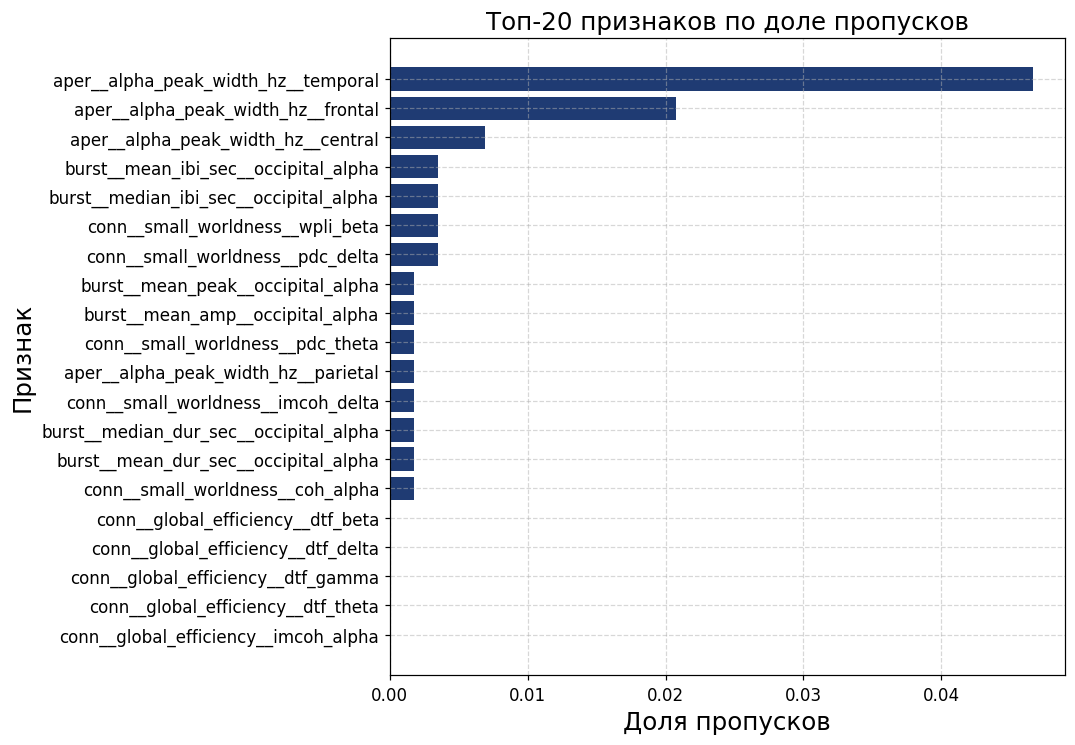

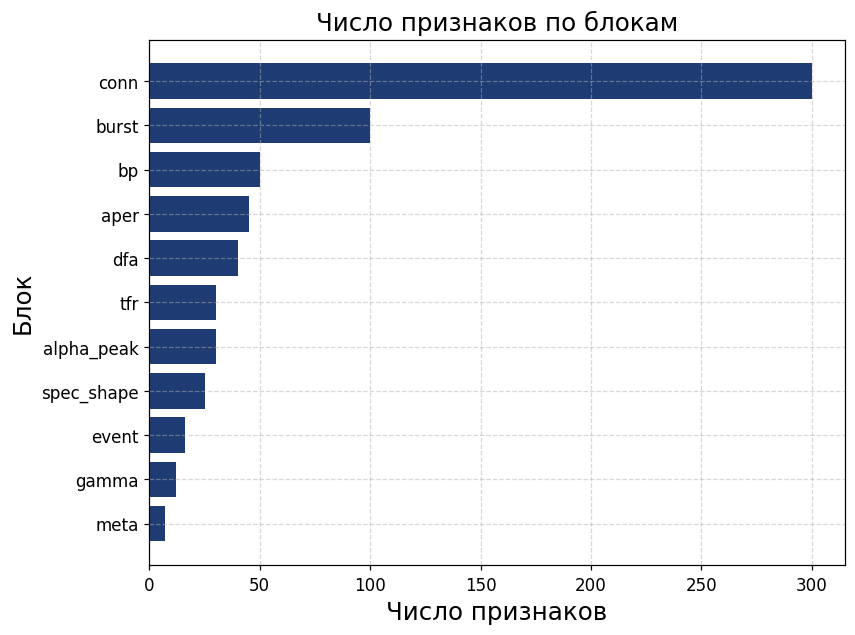


=== QC SUMMARY ===


,n_records_total,n_subjects_total,n_groups,duplicated_record_keys_inventory,duplicated_record_keys_core,median_epochs_control,median_epochs_tbi,median_channels,median_sfreq_hz,median_epoch_len_sec,core_n_features,core_mean_missing_fraction
0,579,164,2,0,0,46.0,115.0,58.0,500.0,3.998,655,0.000156



✅ Полный EDA завершён
Папка с результатами: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core


In [10]:
# @title 1.3. Расширенный EDA: inventory и all_features_record_level_core
# =========================================
# FULL EDA: inventory + all_features_record_level_core

# =========================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")

INV_PATH = BASE_DIR / "inventory_epochs_standardized.csv"
CORE_PATH = BASE_DIR / "all_features_record_level_core.csv"

# запасные пути для файлов, загруженных в чат



# =========================================
# 1. Загрузка
# =========================================
inv = pd.read_csv(INV_PATH)
core = pd.read_csv(CORE_PATH)

for df in [inv, core]:
    if "group" in df.columns:
        df["group"] = df["group"].astype(str).str.strip()
    if "record_id" in df.columns:
        df["record_id"] = df["record_id"].astype(str).str.strip()


# =========================================
# 2. Красивые подписи групп
# =========================================
group_map = {
    "TBI": "ЧМТ",
    "tbi": "ЧМТ",
    "Control": "Контроль",
    "control": "Контроль",
}
inv["_group_pretty"] = inv["group"].map(lambda x: group_map.get(x, x))
core["_group_pretty"] = core["group"].map(lambda x: group_map.get(x, x))


# =========================================
# 3. Восстановление subject_id из record_id
# =========================================
def infer_subject_id(record_id):
    s = str(record_id)

    # control: sub-001
    m = re.search(r"(sub-\d+)", s, flags=re.IGNORECASE)
    if m:
        return m.group(1).lower()

    # tbi: tbi_soft_3001_1_Rest -> subject = 3001
    m = re.search(r"tbi_soft_(\d+)", s, flags=re.IGNORECASE)
    if m:
        return f"tbi-{m.group(1)}"

    parts = s.split("_")
    if len(parts) >= 2:
        return "_".join(parts[:2]).lower()

    return s.lower()

inv["subject_id"] = inv["record_id"].map(infer_subject_id)
core["subject_id"] = core["record_id"].map(infer_subject_id)


# =========================================
# 4. Общая структура данных
# =========================================
print("=== SHAPES ===")
print("inventory:", inv.shape)
print("core:", core.shape)

print("\n=== KEYS ===")
print("inventory duplicated keys:", inv.duplicated(["group", "record_id"]).sum())
print("core duplicated keys:", core.duplicated(["group", "record_id"]).sum())

print("\n=== GROUP COUNTS ===")
print(inv["_group_pretty"].value_counts(dropna=False))
print(core["_group_pretty"].value_counts(dropna=False))


# =========================================
# 5. Основная таблица характеристик выборки
# =========================================
sample_stats = (
    inv.groupby("_group_pretty")
    .agg(
        n_subjects=("subject_id", "nunique"),
        n_records=("record_id", "nunique"),
        n_epochs_sum=("n_epochs", "sum"),
        n_epochs_median=("n_epochs", "median"),
        n_epochs_q1=("n_epochs", lambda x: x.quantile(0.25)),
        n_epochs_q3=("n_epochs", lambda x: x.quantile(0.75)),
        file_size_mb_median=("size_mb", "median"),
        file_size_mb_q1=("size_mb", lambda x: x.quantile(0.25)),
        file_size_mb_q3=("size_mb", lambda x: x.quantile(0.75)),
        n_channels_median=("n_channels", "median"),
        sfreq_median=("sfreq_hz", "median"),
        epoch_len_median=("epoch_len_sec", "median"),
    )
    .reset_index()
)

sample_stats.to_csv(OUT_DIR / "sample_stats_by_group.csv", index=False, encoding="utf-8")

print("\n=== SAMPLE STATS ===")
display(sample_stats)


# =========================================
# 6. Маленькая таблица для текста ВКР
# =========================================
groups_order = ["ЧМТ", "Контроль"]

subj_stat = inv.groupby("_group_pretty")["subject_id"].nunique()
record_stat = inv.groupby("_group_pretty")["record_id"].nunique()
epoch_stat = inv.groupby("_group_pretty")["n_epochs"].sum()

rows = [
    {"Параметр": "Число субъектов"},
    {"Параметр": "Число записей"},
    {"Параметр": "Число эпох"},
]

for g in groups_order:
    rows[0][g] = int(subj_stat[g]) if g in subj_stat.index else "—"
    rows[1][g] = int(record_stat[g]) if g in record_stat.index else "—"
    rows[2][g] = int(epoch_stat[g]) if g in epoch_stat.index else "—"

sample_table = pd.DataFrame(rows)
sample_table.to_csv(OUT_DIR / "table_2_1_sample_characteristics.csv", index=False, encoding="utf-8")

print("\n=== TABLE 2.1 ===")
display(sample_table)


# =========================================
# 7. Проверка полноты inventory
# =========================================
inventory_missing = (
    inv.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .reset_index()
    .rename(columns={"index": "column"})
)

inventory_missing.to_csv(OUT_DIR / "inventory_missingness.csv", index=False, encoding="utf-8")

print("\n=== INVENTORY MISSINGNESS ===")
display(inventory_missing.head(20))


# =========================================
# 8. Контроль согласованности параметров
# =========================================
consistency_rows = []

for col in ["sfreq_hz", "n_channels", "epoch_len_sec", "tmin_sec", "tmax_sec"]:
    if col in inv.columns:
        vals = inv[col].dropna()
        consistency_rows.append({
            "parameter": col,
            "n_unique": vals.nunique(),
            "min": vals.min() if len(vals) else np.nan,
            "median": vals.median() if len(vals) else np.nan,
            "max": vals.max() if len(vals) else np.nan,
        })

consistency_df = pd.DataFrame(consistency_rows)
consistency_df.to_csv(OUT_DIR / "inventory_consistency_check.csv", index=False, encoding="utf-8")

print("\n=== CONSISTENCY CHECK ===")
display(consistency_df)


# =========================================
# 9. EDA по итоговой матрице признаков
# =========================================
key_cols = ["group", "record_id", "_group_pretty", "subject_id"]
feature_cols = [c for c in core.columns if c not in key_cols]
numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(core[c])]

core_num = core[numeric_cols].copy()

# пропуски по признакам
feature_missing = (
    core_num.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .reset_index()
    .rename(columns={"index": "feature"})
)

feature_missing.to_csv(OUT_DIR / "core_feature_missingness.csv", index=False, encoding="utf-8")

# околонулевая вариативность
feature_var = core_num.var(numeric_only=True)
low_var_df = (
    feature_var.sort_values()
    .rename("variance")
    .reset_index()
    .rename(columns={"index": "feature"})
)

low_var_df.to_csv(OUT_DIR / "core_feature_variance.csv", index=False, encoding="utf-8")

# базовая сводка по матрице
core_overview = pd.DataFrame([{
    "n_rows": core.shape[0],
    "n_columns_total": core.shape[1],
    "n_feature_columns": len(feature_cols),
    "n_numeric_features": len(numeric_cols),
    "mean_missing_fraction_over_features": core_num.isna().mean().mean(),
    "max_missing_fraction": core_num.isna().mean().max(),
    "n_features_with_any_missing": int((core_num.isna().mean() > 0).sum()),
    "n_features_all_missing": int((core_num.isna().mean() == 1).sum()),
    "n_features_zero_variance": int((feature_var.fillna(0) == 0).sum()),
}])

core_overview.to_csv(OUT_DIR / "core_overview.csv", index=False, encoding="utf-8")

print("\n=== CORE OVERVIEW ===")
display(core_overview)

print("\n=== TOP FEATURES BY MISSINGNESS ===")
display(feature_missing.head(20))

print("\n=== LOWEST VARIANCE FEATURES ===")
display(low_var_df.head(20))


# =========================================
# 10. Признаки по блокам / источникам
# =========================================
def extract_block_name(col):
    if "__" in col:
        return col.split("__")[0]
    return "other"

block_counts = (
    pd.Series(numeric_cols)
    .map(extract_block_name)
    .value_counts()
    .rename_axis("block")
    .reset_index(name="n_features")
)

block_missing = []
for block in block_counts["block"]:
    cols = [c for c in numeric_cols if extract_block_name(c) == block]
    block_missing.append({
        "block": block,
        "n_features": len(cols),
        "mean_missing_fraction": core_num[cols].isna().mean().mean(),
        "max_missing_fraction": core_num[cols].isna().mean().max(),
    })

block_missing_df = pd.DataFrame(block_missing).sort_values("n_features", ascending=False)
block_missing_df.to_csv(OUT_DIR / "core_blocks_summary.csv", index=False, encoding="utf-8")

print("\n=== BLOCK SUMMARY ===")
display(block_missing_df)


# =========================================
# 11. Рисунки: inventory
# =========================================
plot_group_order = ["ЧМТ", "Контроль"]
plot_data_inv = inv[inv["_group_pretty"].isin(plot_group_order)].copy()

# 11.1 число эпох
plt.figure(figsize=(7, 5))
data = [plot_data_inv.loc[plot_data_inv["_group_pretty"] == g, "n_epochs"].dropna() for g in plot_group_order]
plt.boxplot(data, tick_labels=plot_group_order)
plt.ylabel("Число эпох на запись")
plt.title("Распределение числа эпох по группам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_n_epochs_by_group.png", dpi=200, bbox_inches="tight")
plt.show()

# 11.2 размер файла
plt.figure(figsize=(7, 5))
data = [plot_data_inv.loc[plot_data_inv["_group_pretty"] == g, "size_mb"].dropna() for g in plot_group_order]
plt.boxplot(data, tick_labels=plot_group_order)
plt.ylabel("Размер файла, МБ")
plt.title("Распределение размеров файлов по группам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_size_mb_by_group.png", dpi=200, bbox_inches="tight")
plt.show()

# 11.3 число каналов
plt.figure(figsize=(7, 5))
data = [plot_data_inv.loc[plot_data_inv["_group_pretty"] == g, "n_channels"].dropna() for g in plot_group_order]
plt.boxplot(data, tick_labels=plot_group_order)
plt.ylabel("Число каналов")
plt.title("Распределение числа каналов по группам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_n_channels_by_group.png", dpi=200, bbox_inches="tight")
plt.show()

# 11.4 длительность эпох
plt.figure(figsize=(7, 5))
data = [plot_data_inv.loc[plot_data_inv["_group_pretty"] == g, "epoch_len_sec"].dropna() for g in plot_group_order]
plt.boxplot(data, tick_labels=plot_group_order)
plt.ylabel("Длительность эпохи, с")
plt.title("Проверка длительности эпох по группам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_epoch_len_by_group.png", dpi=200, bbox_inches="tight")
plt.show()


# =========================================
# 12. Рисунки: missingness и feature blocks
# =========================================
# 12.1 топ-20 признаков по пропускам
top_missing = feature_missing.head(20).copy()

plt.figure(figsize=(10, 7))
plt.barh(top_missing["feature"][::-1], top_missing["missing_fraction"][::-1])
plt.xlabel("Доля пропусков")
plt.ylabel("Признак")
plt.title("Топ-20 признаков по доле пропусков")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_top20_missing_features.png", dpi=200, bbox_inches="tight")
plt.show()

# 12.2 число признаков по блокам
tmp = block_missing_df.sort_values("n_features", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(tmp["block"], tmp["n_features"])
plt.xlabel("Число признаков")
plt.ylabel("Блок")
plt.title("Число признаков по блокам")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_feature_blocks_counts.png", dpi=200, bbox_inches="tight")
plt.show()


# =========================================
# 13. Кандидаты на QC-таблицу для текста
# =========================================
qc_summary = pd.DataFrame([
    {
        "n_records_total": inv["record_id"].nunique(),
        "n_subjects_total": inv["subject_id"].nunique(),
        "n_groups": inv["_group_pretty"].nunique(),
        "duplicated_record_keys_inventory": int(inv.duplicated(["group", "record_id"]).sum()),
        "duplicated_record_keys_core": int(core.duplicated(["group", "record_id"]).sum()),
        "median_epochs_control": float(inv.loc[inv["_group_pretty"] == "Контроль", "n_epochs"].median()),
        "median_epochs_tbi": float(inv.loc[inv["_group_pretty"] == "ЧМТ", "n_epochs"].median()),
        "median_channels": float(inv["n_channels"].median()),
        "median_sfreq_hz": float(inv["sfreq_hz"].median()),
        "median_epoch_len_sec": float(inv["epoch_len_sec"].median()),
        "core_n_features": len(numeric_cols),
        "core_mean_missing_fraction": float(core_num.isna().mean().mean()),
    }
])

qc_summary.to_csv(OUT_DIR / "eda_qc_summary.csv", index=False, encoding="utf-8")

print("\n=== QC SUMMARY ===")
display(qc_summary)

print("\n✅ Полный EDA завершён")
print("Папка с результатами:", OUT_DIR)

## 2. Контроль качества и очистка признакового пространства

Здесь исключаются технические, низковариативные и избыточные признаки, а также формируются варианты очищенных наборов признаков. Это важно для интерпретируемости модели и снижения риска переобучения.

In [11]:
# @title 2.1. Аудит признаков: технические, низковариативные, пропущенные и коррелированные


from pathlib import Path
import re
import numpy as np
import pandas as pd


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
CORE_PATH = BASE_DIR / "all_features_record_level_core.csv"

OUT_DIR = CORE_PATH.parent / "eda_record_level_core"
OUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================================
# 1. Загрузка
# =========================================
df = pd.read_csv(CORE_PATH)

df["group"] = df["group"].astype(str).str.strip()
df["record_id"] = df["record_id"].astype(str).str.strip()

key_cols = ["group", "record_id"]
feature_cols = [c for c in df.columns if c not in key_cols]
numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]


# =========================================
# 2. Функции-классификаторы
# =========================================
def get_block(col):
    if "__" in col:
        return col.split("__")[0]
    return "other"


def is_technical_feature(col):
    c = str(col).lower()
    patterns = [
        r"^meta__",
        r"__n_epochs_used__",
        r"__n_roi_used__",
        r"__total_sec__",
        r"__record_len",
        r"__duration",
        r"__coverage",
    ]
    return any(re.search(p, c) for p in patterns)


def is_count_like_feature(col):
    c = str(col).lower()
    patterns = [
        r"__n_bursts__",
        r"__n_events$",
        r"__count__",
        r"^event__n_",
    ]
    return any(re.search(p, c) for p in patterns)


def dominant_fraction(s):
    s = pd.Series(s)
    if s.dropna().empty:
        return np.nan
    return s.value_counts(normalize=True, dropna=True).iloc[0]


# =========================================
# 3. Аудит признаков
# =========================================
rows = []
for col in numeric_cols:
    s = df[col]

    rows.append({
        "feature": col,
        "block": get_block(col),
        "missing_fraction": s.isna().mean(),
        "n_unique_non_na": s.nunique(dropna=True),
        "variance": s.var(skipna=True),
        "std": s.std(skipna=True),
        "dominant_fraction": dominant_fraction(s),
        "is_technical": is_technical_feature(col),
        "is_count_like": is_count_like_feature(col),
        "all_missing": bool(s.isna().all()),
        "zero_variance": bool((s.var(skipna=True) == 0) if s.notna().sum() > 0 else False),
    })

audit_df = pd.DataFrame(rows)

# near-zero variance: очень мало уникальных значений или доминирующее значение
audit_df["near_zero_variance"] = (
    (audit_df["n_unique_non_na"] <= 5) &
    (audit_df["dominant_fraction"] >= 0.95)
)

audit_df["high_missing"] = audit_df["missing_fraction"] >= 0.05

audit_df.to_csv(
    OUT_DIR / "cleaning_audit_features.csv",
    index=False,
    encoding="utf-8"
)

print("=== FEATURE CLEANING AUDIT ===")
display(audit_df.head(20))

print("\n=== COUNTS OF CANDIDATES ===")
summary_df = pd.DataFrame([{
    "n_numeric_features": len(audit_df),
    "n_technical": int(audit_df["is_technical"].sum()),
    "n_count_like": int(audit_df["is_count_like"].sum()),
    "n_zero_variance": int(audit_df["zero_variance"].sum()),
    "n_near_zero_variance": int(audit_df["near_zero_variance"].sum()),
    "n_high_missing_ge_5pct": int(audit_df["high_missing"].sum()),
}])
display(summary_df)

print("\n=== TOP HIGH-MISSING FEATURES ===")
display(
    audit_df.sort_values("missing_fraction", ascending=False)
    .head(30)
)

print("\n=== ZERO-VARIANCE FEATURES ===")
display(
    audit_df[audit_df["zero_variance"]]
    .sort_values(["block", "feature"])
    .head(50)
)

print("\n=== NEAR-ZERO-VARIANCE FEATURES ===")
display(
    audit_df[audit_df["near_zero_variance"]]
    .sort_values(["dominant_fraction", "n_unique_non_na"], ascending=[False, True])
    .head(50)
)

print("\n=== TECHNICAL FEATURES ===")
display(
    audit_df[audit_df["is_technical"]]
    .sort_values(["block", "feature"])
    .head(100)
)

print("\n=== COUNT-LIKE FEATURES ===")
display(
    audit_df[audit_df["is_count_like"]]
    .sort_values(["block", "feature"])
    .head(100)
)

print("\n✅ Аудит кандидатов на очистку готов")
print("Файл:", OUT_DIR / "cleaning_audit_features.csv")

=== FEATURE CLEANING AUDIT ===


,feature,block,missing_fraction,n_unique_non_na,variance,std,dominant_fraction,is_technical,is_count_like,all_missing,zero_variance,near_zero_variance,high_missing
0,meta__size_mb,meta,0.0,41,2.242714e+02,1.497570e+01,0.298791,True,False,False,False,False,False
1,meta__n_epochs,meta,0.0,41,1.145258e+03,3.384167e+01,0.298791,True,False,False,False,False,False
2,meta__sfreq_hz,meta,0.0,1,0.000000e+00,0.000000e+00,1.000000,True,False,False,True,True,False
3,meta__n_channels,meta,0.0,1,0.000000e+00,0.000000e+00,1.000000,True,False,False,True,True,False
4,meta__tmin_sec,meta,0.0,2,9.353915e-01,9.671564e-01,0.628670,True,False,False,False,False,False
5,meta__tmax_sec,meta,0.0,2,9.353915e-01,9.671564e-01,0.628670,True,False,False,False,False,False
6,meta__epoch_len_sec,meta,0.0,1,1.201933e-27,3.466891e-14,1.000000,True,False,False,False,True,False
7,bp__band_fmin__central_alpha,bp,0.0,1,0.000000e+00,0.000000e+00,1.000000,False,False,False,True,True,False
8,bp__band_fmin__central_beta,bp,0.0,1,0.000000e+00,0.000000e+00,1.000000,False,False,False,True,True,False
9,bp__band_fmin__central_delta,bp,0.0,1,0.000000e+00,0.000000e+00,1.000000,False,False,False,True,True,False



=== COUNTS OF CANDIDATES ===


,n_numeric_features,n_technical,n_count_like,n_zero_variance,n_near_zero_variance,n_high_missing_ge_5pct
0,655,58,12,151,193,0



=== TOP HIGH-MISSING FEATURES ===


...


=== TECHNICAL FEATURES ===


,feature,block,missing_fraction,n_unique_non_na,variance,std,dominant_fraction,is_technical,is_count_like,all_missing,zero_variance,near_zero_variance,high_missing
299,burst__total_sec__central_alpha,burst,0.0,14,6.003592e+02,2.450223e+01,0.371330,True,False,False,False,False,False
300,burst__total_sec__central_beta,burst,0.0,14,6.003592e+02,2.450223e+01,0.371330,True,False,False,False,False,False
301,burst__total_sec__frontal_alpha,burst,0.0,14,6.003592e+02,2.450223e+01,0.371330,True,False,False,False,False,False
302,burst__total_sec__frontal_beta,burst,0.0,14,6.003592e+02,2.450223e+01,0.371330,True,False,False,False,False,False
303,burst__total_sec__occipital_alpha,burst,0.0,14,6.003592e+02,2.450223e+01,0.371330,True,False,False,False,False,False
304,burst__total_sec__occipital_beta,burst,0.0,14,6.003592e+02,2.450223e+01,0.371330,True,False,False,False,False,False
305,burst__total_sec__parietal_alpha,burst,0.0,14,6.003592e+02,2.450223e+01,0.371330,True,False,False,False,False,False
306,burst__total_sec__parietal_beta,burst,0.0,14,6.003592e+02,2.450223e+01,0.371330,True,False,False,False,False,False
307,burst__total_sec__temporal_alpha,burst,0.0,14,6.003592e+02,2.450223e+01,0.371330,True,False,False,False,False,False
308,burst__total_sec__temporal_beta,burst,0.0,14,6.003592e+02,2.450223e+01,0.371330,True,False,False,False,False,False



=== COUNT-LIKE FEATURES ===


,feature,block,missing_fraction,n_unique_non_na,variance,std,dominant_fraction,is_technical,is_count_like,all_missing,zero_variance,near_zero_variance,high_missing
209,burst__n_bursts__central_alpha,burst,0.0,85,297.686759,17.253601,0.032815,False,True,False,False,False,False
210,burst__n_bursts__central_beta,burst,0.0,124,1042.106681,32.281677,0.025907,False,True,False,False,False,False
211,burst__n_bursts__frontal_alpha,burst,0.0,91,324.142442,18.003956,0.034542,False,True,False,False,False,False
212,burst__n_bursts__frontal_beta,burst,0.0,130,1087.419462,32.976044,0.034542,False,True,False,False,False,False
213,burst__n_bursts__occipital_alpha,burst,0.0,91,354.547125,18.829422,0.034542,False,True,False,False,False,False
214,burst__n_bursts__occipital_beta,burst,0.0,141,1419.041385,37.670166,0.025907,False,True,False,False,False,False
215,burst__n_bursts__parietal_alpha,burst,0.0,89,325.292636,18.035871,0.036269,False,True,False,False,False,False
216,burst__n_bursts__parietal_beta,burst,0.0,128,1076.368993,32.808063,0.024180,False,True,False,False,False,False
217,burst__n_bursts__temporal_alpha,burst,0.0,81,290.685719,17.049508,0.036269,False,True,False,False,False,False
218,burst__n_bursts__temporal_beta,burst,0.0,142,1391.171833,37.298416,0.025907,False,True,False,False,False,False



✅ Аудит кандидатов на очистку готов
Файл: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/cleaning_audit_features.csv


In [15]:
# @title 2.2. Формирование вариантов очищенного признакового пространства

from pathlib import Path
import pandas as pd


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
CORE_PATH = BASE_DIR / "all_features_record_level_core.csv"

if not CORE_PATH.exists():
    CORE_PATH = Path("/mnt/data/all_features_record_level_core.csv")

OUT_DIR = CORE_PATH.parent / "eda_record_level_core"
AUDIT_PATH = OUT_DIR / "cleaning_audit_features.csv"


# =========================================
# 1. Загрузка
# =========================================
audit_df = pd.read_csv(AUDIT_PATH)


# =========================================
# 2. Формируем наборы
# =========================================
# QC-clean: удаляем только совсем плохое
qc_clean = audit_df[
    (~audit_df["all_missing"]) &
    (~audit_df["zero_variance"])
].copy()

# neuro-clean-soft:
# убираем явные technical и константы,
# но count-like пока оставляем
neuro_clean_soft = audit_df[
    (~audit_df["all_missing"]) &
    (~audit_df["zero_variance"]) &
    (~audit_df["is_technical"])
].copy()

# neuro-clean-strict:
# убираем technical, count-like, near-zero, high-missing
neuro_clean_strict = audit_df[
    (~audit_df["all_missing"]) &
    (~audit_df["zero_variance"]) &
    (~audit_df["is_technical"]) &
    (~audit_df["is_count_like"]) &
    (~audit_df["near_zero_variance"]) &
    (~audit_df["high_missing"])
].copy()


# =========================================
# 3. Сохраняем списки
# =========================================
qc_clean[["feature"]].to_csv(OUT_DIR / "features_qc_clean.csv", index=False, encoding="utf-8")
neuro_clean_soft[["feature"]].to_csv(OUT_DIR / "features_neuro_clean_soft.csv", index=False, encoding="utf-8")
neuro_clean_strict[["feature"]].to_csv(OUT_DIR / "features_neuro_clean_strict.csv", index=False, encoding="utf-8")


# =========================================
# 4. Краткая сводка
# =========================================
summary_df = pd.DataFrame([
    {"set_name": "qc_clean", "n_features": len(qc_clean)},
    {"set_name": "neuro_clean_soft", "n_features": len(neuro_clean_soft)},
    {"set_name": "neuro_clean_strict", "n_features": len(neuro_clean_strict)},
])

print("=== CLEAN FEATURE SETS SUMMARY ===")
display(summary_df)

print("\n=== BLOCKS IN neuro_clean_strict ===")
display(
    neuro_clean_strict.groupby("block")
    .size()
    .reset_index(name="n_features")
    .sort_values("n_features", ascending=False)
)

print("\n✅ Списки очищенных признаков сохранены")
print("QC:", OUT_DIR / "features_qc_clean.csv")
print("SOFT:", OUT_DIR / "features_neuro_clean_soft.csv")
print("STRICT:", OUT_DIR / "features_neuro_clean_strict.csv")

=== CLEAN FEATURE SETS SUMMARY ===


,set_name,n_features
0,qc_clean,504
1,neuro_clean_soft,478
2,neuro_clean_strict,425



=== BLOCKS IN neuro_clean_strict ===


,block,n_features
3,conn,220
2,burst,80
1,aper,30
8,tfr,30
0,alpha_peak,15
7,spec_shape,15
5,event,13
6,gamma,12
4,dfa,10



✅ Списки очищенных признаков сохранены
QC: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/features_qc_clean.csv
SOFT: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/features_neuro_clean_soft.csv
STRICT: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/features_neuro_clean_strict.csv


In [17]:
# @title 2.3. Формирование финального набора признаков neuro_clean_final


from pathlib import Path
import re
import pandas as pd


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
CORE_PATH = BASE_DIR / "all_features_record_level_core.csv"

if not CORE_PATH.exists():
    CORE_PATH = Path("/mnt/data/all_features_record_level_core.csv")

OUT_DIR = CORE_PATH.parent / "eda_record_level_core"
AUDIT_PATH = OUT_DIR / "cleaning_audit_features.csv"


# =========================================
# 1. Загрузка аудита
# =========================================
audit_df = pd.read_csv(AUDIT_PATH)


# =========================================
# 2. Дополнительные правила исключения
# =========================================
def is_final_exclude_feature(col):
    c = str(col).lower()

    extra_patterns = [
        r"^burst__n_bursts__",
        r"^event__n_events$",
        r"^event__duration_sec$",
    ]

    return any(re.search(p, c) for p in extra_patterns)


audit_df["is_final_extra_exclude"] = audit_df["feature"].map(is_final_exclude_feature)


# =========================================
# 3. Финальный набор
# =========================================
neuro_clean_final = audit_df[
    (~audit_df["all_missing"]) &
    (~audit_df["zero_variance"]) &
    (~audit_df["near_zero_variance"]) &
    (~audit_df["is_technical"]) &
    (~audit_df["is_final_extra_exclude"])
].copy()


# =========================================
# 4. Сохранение
# =========================================
neuro_clean_final[["feature"]].to_csv(
    OUT_DIR / "features_neuro_clean_final.csv",
    index=False,
    encoding="utf-8"
)

excluded_final = audit_df[audit_df["is_final_extra_exclude"]].copy()
excluded_final.to_csv(
    OUT_DIR / "features_excluded_extra_final.csv",
    index=False,
    encoding="utf-8"
)


# =========================================
# 5. Сводка
# =========================================
summary_df = pd.DataFrame([{
    "n_features_final": len(neuro_clean_final),
    "n_extra_excluded": int(audit_df["is_final_extra_exclude"].sum()),
}])

print("=== FINAL CLEAN SUMMARY ===")
display(summary_df)

print("\n=== BLOCKS IN neuro_clean_final ===")
display(
    neuro_clean_final.groupby("block")
    .size()
    .reset_index(name="n_features")
    .sort_values("n_features", ascending=False)
)

print("\n=== EXTRA EXCLUDED FEATURES ===")
display(
    excluded_final[["feature", "block"]]
    .sort_values(["block", "feature"])
    .reset_index(drop=True)
)

print("\n✅ Финальный набор признаков сохранён")
print("Файл:", OUT_DIR / "features_neuro_clean_final.csv")

=== FINAL CLEAN SUMMARY ===


,n_features_final,n_extra_excluded
0,426,12



=== BLOCKS IN neuro_clean_final ===


,block,n_features
3,conn,220
2,burst,80
1,aper,30
8,tfr,30
0,alpha_peak,15
7,spec_shape,15
5,event,14
6,gamma,12
4,dfa,10



=== EXTRA EXCLUDED FEATURES ===


,feature,block
0,burst__n_bursts__central_alpha,burst
1,burst__n_bursts__central_beta,burst
2,burst__n_bursts__frontal_alpha,burst
3,burst__n_bursts__frontal_beta,burst
4,burst__n_bursts__occipital_alpha,burst
5,burst__n_bursts__occipital_beta,burst
6,burst__n_bursts__parietal_alpha,burst
7,burst__n_bursts__parietal_beta,burst
8,burst__n_bursts__temporal_alpha,burst
9,burst__n_bursts__temporal_beta,burst



✅ Финальный набор признаков сохранён
Файл: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/features_neuro_clean_final.csv


## 3. Разведочный анализ и межгрупповые различия

Блок описывает, какие признаки сильнее всего различают ЧМТ и контроль до обучения моделей. Основной акцент сделан на размере эффекта, FDR-коррекции и русскоязычных подписях для рисунков ВКР.

Число финальных признаков: 426
Размер матрицы: (579, 426)

=== TOP FINAL FEATURES BY HEDGES g ===


,feature,block,n_tbi,n_control,mean_tbi,mean_control,median_tbi,median_control,std_tbi,std_control,missing_fraction,hedges_g_tbi_minus_control,abs_hedges_g
0,event__propagation_ms,event,215,364,69.204651,49.442308,69.000000,48.000000,13.393923,9.840013,0.0,1.748248,1.748248
1,event__z_peak,event,215,364,3.042434,4.248099,2.988925,4.188138,0.699353,0.757456,0.0,-1.635020,1.635020
2,event__spike_to_slow_ratio,event,215,364,1.268527,0.784022,0.992510,0.774855,0.720896,0.096121,0.0,1.085900,1.085900
3,conn__clustering__plv_theta,conn,215,364,0.343287,0.411566,0.332206,0.402607,0.070479,0.067781,0.0,-0.991217,0.991217
4,aper__aperiodic_intercept_log10__parietal,aper,215,364,-8.392273,-8.888837,-8.460267,-8.886085,0.611680,0.460846,0.0,0.950219,0.950219
5,aper__aperiodic_intercept_log10__frontal,aper,215,364,-8.469062,-9.011425,-8.495184,-8.927917,0.598991,0.596058,0.0,0.907076,0.907076
6,aper__aperiodic_intercept_log10__temporal,aper,215,364,-8.411473,-8.983517,-8.420334,-8.929194,0.649743,0.620473,0.0,0.904690,0.904690
7,aper__aperiodic_intercept_log10__central,aper,215,364,-8.598201,-9.084320,-8.644024,-9.022038,0.575543,0.533355,0.0,0.883701,0.883701
8,spec_shape__spectral_entropy_norm__central,spec_shape,215,364,0.825989,0.882789,0.832482,0.891719,0.065012,0.067048,0.0,-0.855594,0.855594
9,spec_shape__spectral_entropy_raw__central,spec_shape,215,364,4.275443,4.569447,4.309054,4.615669,0.336509,0.347050,0.0,-0.855594,0.855594



=== FINAL BLOCK SUMMARY (HEDGES g) ===


,block,n_features,mean_abs_g,median_abs_g,max_abs_g,mean_missing
7,spec_shape,15,0.642937,0.712508,0.855594,0.000000
5,event,14,0.561238,0.291394,1.748248,0.000000
1,aper,30,0.436424,0.452932,0.950219,0.002533
4,dfa,10,0.368484,0.374219,0.694638,0.000000
0,alpha_peak,15,0.365897,0.372372,0.628220,0.000000
2,burst,80,0.324322,0.268760,0.807846,0.000173
6,gamma,12,0.307726,0.229609,0.722635,0.000000
3,conn,220,0.229120,0.157082,0.991217,0.000055
8,tfr,30,0.127247,0.102145,0.450574,0.000000


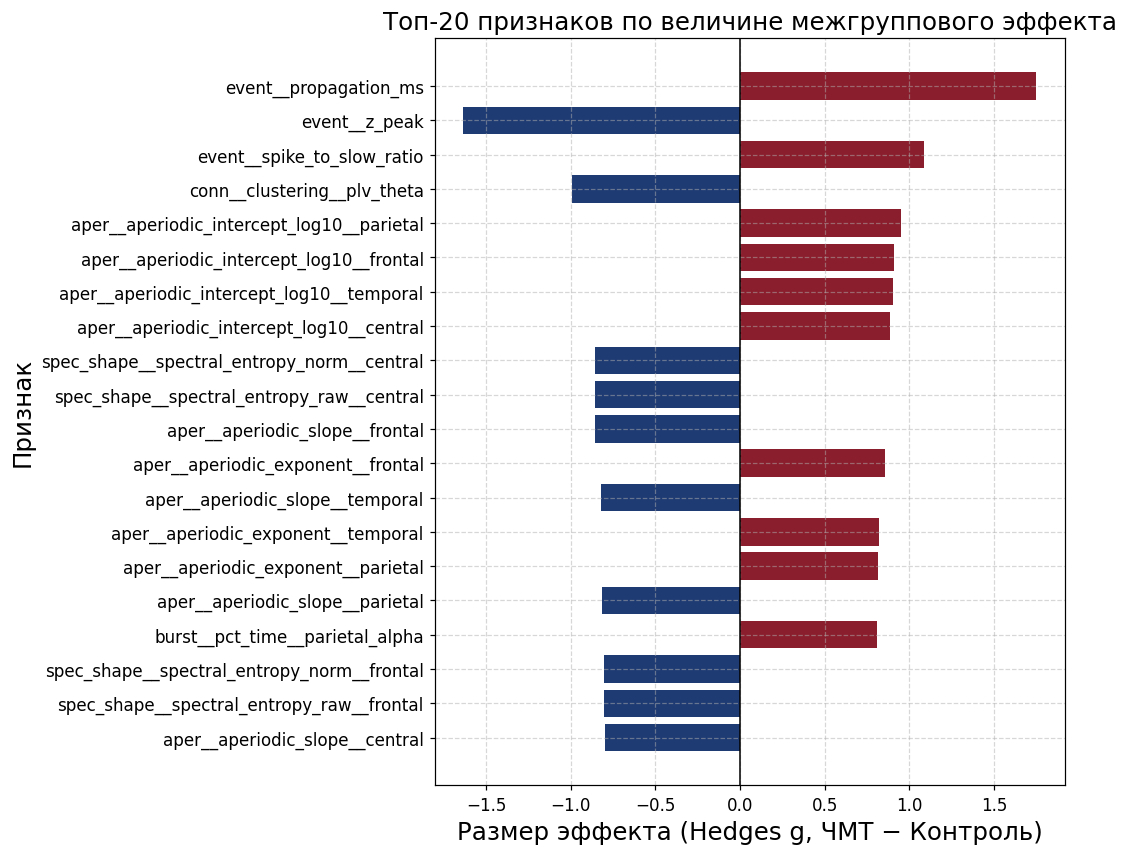


=== FINAL TOP FEATURES PER BLOCK (HEDGES g) ===


,feature,block,n_tbi,n_control,mean_tbi,mean_control,median_tbi,median_control,std_tbi,std_control,missing_fraction,hedges_g_tbi_minus_control,abs_hedges_g
0,event__propagation_ms,event,215,364,69.204651,49.442308,69.000000,48.000000,13.393923,9.840013,0.0,1.748248,1.748248
1,event__z_peak,event,215,364,3.042434,4.248099,2.988925,4.188138,0.699353,0.757456,0.0,-1.635020,1.635020
2,event__spike_to_slow_ratio,event,215,364,1.268527,0.784022,0.992510,0.774855,0.720896,0.096121,0.0,1.085900,1.085900
3,conn__clustering__plv_theta,conn,215,364,0.343287,0.411566,0.332206,0.402607,0.070479,0.067781,0.0,-0.991217,0.991217
4,aper__aperiodic_intercept_log10__parietal,aper,215,364,-8.392273,-8.888837,-8.460267,-8.886085,0.611680,0.460846,0.0,0.950219,0.950219
5,aper__aperiodic_intercept_log10__frontal,aper,215,364,-8.469062,-9.011425,-8.495184,-8.927917,0.598991,0.596058,0.0,0.907076,0.907076
6,aper__aperiodic_intercept_log10__temporal,aper,215,364,-8.411473,-8.983517,-8.420334,-8.929194,0.649743,0.620473,0.0,0.904690,0.904690
7,spec_shape__spectral_entropy_norm__central,spec_shape,215,364,0.825989,0.882789,0.832482,0.891719,0.065012,0.067048,0.0,-0.855594,0.855594
8,spec_shape__spectral_entropy_raw__central,spec_shape,215,364,4.275443,4.569447,4.309054,4.615669,0.336509,0.347050,0.0,-0.855594,0.855594
9,burst__pct_time__parietal_alpha,burst,215,364,12.976120,10.209347,12.953704,9.971213,4.058134,2.981228,0.0,0.807846,0.807846



=== FINAL PCA EXPLAINED VARIANCE ===
PC1: 0.1387
PC2: 0.0860

=== TOP LOADINGS PC1 ===


,feature,PC1_loading,PC2_loading,abs_PC1_loading,abs_PC2_loading
134,burst__mean_peak__frontal_alpha,-0.121105,-0.014676,0.121105,0.014676
130,burst__mean_amp__temporal_alpha,-0.119578,-0.022720,0.119578,0.022720
122,burst__mean_amp__central_alpha,-0.119334,-0.022438,0.119334,0.022438
140,burst__mean_peak__temporal_alpha,-0.118687,-0.043365,0.118687,0.043365
126,burst__mean_amp__occipital_alpha,-0.118471,-0.004856,0.118471,0.004856
136,burst__mean_peak__occipital_alpha,-0.117882,-0.035253,0.117882,0.035253
132,burst__mean_peak__central_alpha,-0.117857,-0.045000,0.117857,0.045000
420,event__slow_peak_uv,-0.116119,-0.050640,0.116119,0.050640
127,burst__mean_amp__occipital_beta,-0.115776,-0.050585,0.115776,0.050585
135,burst__mean_peak__frontal_beta,-0.115184,-0.060587,0.115184,0.060587



=== TOP LOADINGS PC2 ===


,feature,PC1_loading,PC2_loading,abs_PC1_loading,abs_PC2_loading
18,spec_shape__sef95_hz__parietal,0.049205,-0.129340,0.049205,0.129340
53,aper__alpha_peak_amp_log10__parietal,-0.029740,0.127789,0.029740,0.127789
52,aper__alpha_peak_amp_log10__occipital,-0.030786,0.125246,0.030786,0.125246
50,aper__alpha_peak_amp_log10__central,-0.030553,0.123893,0.030553,0.123893
17,spec_shape__sef95_hz__occipital,0.047360,-0.120268,0.047360,0.120268
51,aper__alpha_peak_amp_log10__frontal,-0.034518,0.119492,0.034518,0.119492
54,aper__alpha_peak_amp_log10__temporal,-0.034372,0.117373,0.034372,0.117373
63,gamma__gamma_rel__parietal,0.039500,-0.115989,0.039500,0.115989
23,spec_shape__spectral_entropy_norm__parietal,0.051586,-0.114802,0.051586,0.114802
28,spec_shape__spectral_entropy_raw__parietal,0.051586,-0.114802,0.051586,0.114802


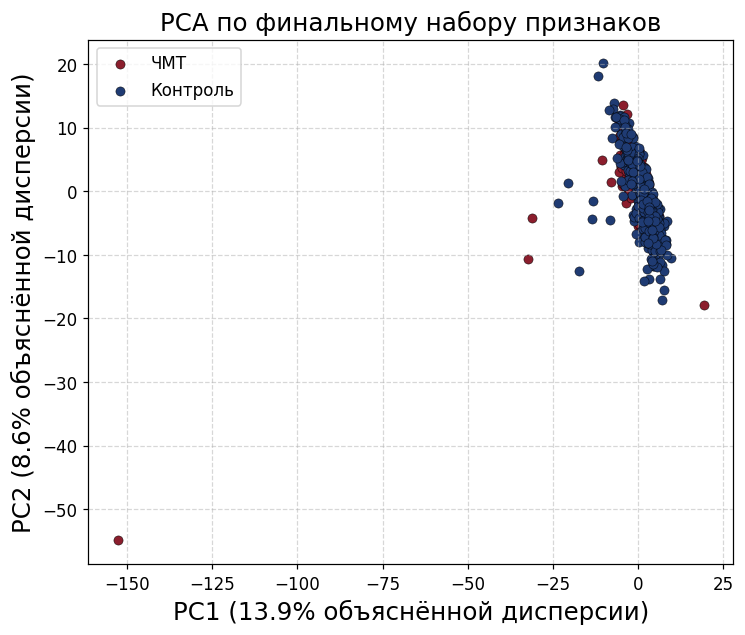


=== FINAL BLOCK CORRELATION MATRIX ===


,alpha_peak,aper,burst,conn,dfa,event,gamma,spec_shape,tfr
alpha_peak,1.000000,-0.156257,-0.122478,-0.076739,-0.106662,0.112584,0.223834,0.266431,0.206497
aper,-0.156257,1.000000,0.453272,0.114572,0.079207,0.051668,-0.669888,-0.572191,-0.148854
burst,-0.122478,0.453272,1.000000,0.221667,0.490948,0.184303,-0.290098,-0.343773,0.145934
conn,-0.076739,0.114572,0.221667,1.000000,0.111812,-0.079622,-0.037347,-0.023607,-0.012134
dfa,-0.106662,0.079207,0.490948,0.111812,1.000000,0.272940,-0.150522,-0.190107,0.130875
event,0.112584,0.051668,0.184303,-0.079622,0.272940,1.000000,-0.112854,-0.299528,0.247161
gamma,0.223834,-0.669888,-0.290098,-0.037347,-0.150522,-0.112854,1.000000,0.658388,0.159552
spec_shape,0.266431,-0.572191,-0.343773,-0.023607,-0.190107,-0.299528,0.658388,1.000000,0.072012
tfr,0.206497,-0.148854,0.145934,-0.012134,0.130875,0.247161,0.159552,0.072012,1.000000


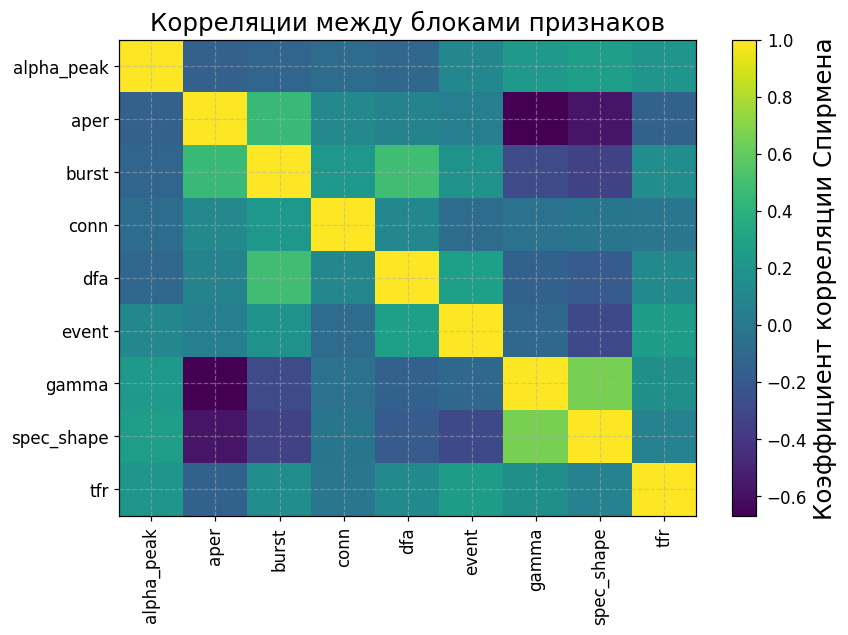


=== FINAL EDA SUMMARY ===


,n_final_features,top_feature,top_feature_abs_hedges_g,top_block,top_block_mean_abs_g,pc1_explained_ratio,pc2_explained_ratio
0,426,event__propagation_ms,1.748248,spec_shape,0.642937,0.138746,0.086032



✅ Финальный EDA пересчитан с Hedges g
Результаты сохранены в: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core


In [19]:
# @title 3.1. Описательный анализ признаков: Hedges g и визуализации

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
CORE_PATH = BASE_DIR / "all_features_record_level_core.csv"

if not CORE_PATH.exists():
    CORE_PATH = Path("/mnt/data/all_features_record_level_core.csv")

OUT_DIR = CORE_PATH.parent / "eda_record_level_core"
FEATURE_LIST_PATH = OUT_DIR / "features_neuro_clean_final.csv"

# =========================================
# 1. Загрузка
# =========================================
df = pd.read_csv(CORE_PATH)
feat_df = pd.read_csv(FEATURE_LIST_PATH)

df["group"] = df["group"].astype(str).str.strip()
df["record_id"] = df["record_id"].astype(str).str.strip()

group_map = {
    "TBI": "ЧМТ",
    "tbi": "ЧМТ",
    "Control": "Контроль",
    "control": "Контроль",
}
df["_group_pretty"] = df["group"].map(lambda x: group_map.get(x, x))

final_features = feat_df["feature"].tolist()

# =========================================
# 2. Цвета
# =========================================
COLOR_TBI = "#8B1E2D"      # тёмно-красный
COLOR_CONTROL = "#1F3B73"  # тёмно-синий
COLOR_SINGLE = "#1F3B73"   # если нет разделения по группам

# =========================================
# 3. Вспомогательные функции
# =========================================
def get_block(col):
    if "__" in col:
        return col.split("__")[0]
    return "other"


def zscore_col(s):
    s = pd.Series(s).astype(float)
    mu = s.mean()
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mu) / sd


def hedges_g(x1, x2):
    """
    Hedges g для независимых выборок:
    g = J * d
    где J = 1 - 3 / (4*df - 1)
    """
    x1 = pd.Series(x1).dropna().astype(float)
    x2 = pd.Series(x2).dropna().astype(float)

    n1, n2 = len(x1), len(x2)
    if n1 < 2 or n2 < 2:
        return np.nan

    v1 = x1.var(ddof=1)
    v2 = x2.var(ddof=1)

    if pd.isna(v1) or pd.isna(v2):
        return np.nan

    dfree = n1 + n2 - 2
    if dfree <= 0:
        return np.nan

    pooled = ((n1 - 1) * v1 + (n2 - 1) * v2) / dfree
    if pd.isna(pooled) or pooled <= 0:
        return np.nan

    d = (x1.mean() - x2.mean()) / np.sqrt(pooled)
    J = 1 - (3 / (4 * dfree - 1)) if (4 * dfree - 1) != 0 else 1.0
    return J * d


# =========================================
# 4. Матрица финальных признаков
# =========================================
X = df[final_features].copy()

print("Число финальных признаков:", len(final_features))
print("Размер матрицы:", X.shape)

# =========================================
# 5. Межгрупповые размеры эффекта: Hedges g
# =========================================
rows = []
for col in final_features:
    x_tbi = df.loc[df["_group_pretty"] == "ЧМТ", col]
    x_ctl = df.loc[df["_group_pretty"] == "Контроль", col]

    rows.append({
        "feature": col,
        "block": get_block(col),
        "n_tbi": x_tbi.notna().sum(),
        "n_control": x_ctl.notna().sum(),
        "mean_tbi": x_tbi.mean(),
        "mean_control": x_ctl.mean(),
        "median_tbi": x_tbi.median(),
        "median_control": x_ctl.median(),
        "std_tbi": x_tbi.std(ddof=1),
        "std_control": x_ctl.std(ddof=1),
        "missing_fraction": df[col].isna().mean(),
        "hedges_g_tbi_minus_control": hedges_g(x_tbi, x_ctl),
    })

effect_df = pd.DataFrame(rows)
effect_df["abs_hedges_g"] = effect_df["hedges_g_tbi_minus_control"].abs()
effect_df = effect_df.sort_values("abs_hedges_g", ascending=False).reset_index(drop=True)

effect_df.to_csv(
    OUT_DIR / "final_eda_effect_sizes_hedges_g.csv",
    index=False,
    encoding="utf-8"
)

print("\n=== TOP FINAL FEATURES BY HEDGES g ===")
display(effect_df.head(25))

# =========================================
# 6. Сводка по блокам
# =========================================
block_summary = (
    effect_df.groupby("block")
    .agg(
        n_features=("feature", "count"),
        mean_abs_g=("abs_hedges_g", "mean"),
        median_abs_g=("abs_hedges_g", "median"),
        max_abs_g=("abs_hedges_g", "max"),
        mean_missing=("missing_fraction", "mean"),
    )
    .reset_index()
    .sort_values("mean_abs_g", ascending=False)
)

block_summary.to_csv(
    OUT_DIR / "final_eda_block_summary_hedges_g.csv",
    index=False,
    encoding="utf-8"
)

print("\n=== FINAL BLOCK SUMMARY (HEDGES g) ===")
display(block_summary)

# =========================================
# 7. Топ-20 признаков по Hedges g
# =========================================
top20 = effect_df.head(20).copy()

plt.figure(figsize=(10, 8))
bars = plt.barh(
    top20["feature"][::-1],
    top20["hedges_g_tbi_minus_control"][::-1],
    color=[COLOR_TBI if v > 0 else COLOR_CONTROL for v in top20["hedges_g_tbi_minus_control"][::-1]]
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Размер эффекта (Hedges g, ЧМТ − Контроль)")
plt.ylabel("Признак")
plt.title("Топ-20 признаков по величине межгруппового эффекта")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_final_top20_features_hedges_g.png", dpi=200, bbox_inches="tight")
plt.show()

# =========================================
# 8. Топ-12 признаков по блокам
# =========================================
top_per_block = (
    effect_df.sort_values("abs_hedges_g", ascending=False)
    .groupby("block", as_index=False)
    .head(3)
    .reset_index(drop=True)
)

top_per_block.to_csv(
    OUT_DIR / "final_eda_top_per_block_hedges_g.csv",
    index=False,
    encoding="utf-8"
)

print("\n=== FINAL TOP FEATURES PER BLOCK (HEDGES g) ===")
display(top_per_block)

# =========================================
# 9. PCA
# =========================================
X_pca = X.copy()

for c in X_pca.columns:
    X_pca[c] = X_pca[c].fillna(X_pca[c].median())

X_pca = X_pca.apply(zscore_col, axis=0)
Xmat = X_pca.to_numpy(dtype=float)

U, S, Vt = np.linalg.svd(Xmat, full_matrices=False)

pc1 = U[:, 0] * S[0]
pc2 = U[:, 1] * S[1]

explained_var = (S ** 2) / (Xmat.shape[0] - 1)
explained_ratio = explained_var / explained_var.sum()

pca_df = pd.DataFrame({
    "group": df["group"],
    "record_id": df["record_id"],
    "_group_pretty": df["_group_pretty"],
    "PC1": pc1,
    "PC2": pc2,
})

pca_df.to_csv(
    OUT_DIR / "final_eda_pca_scores.csv",
    index=False,
    encoding="utf-8"
)

loadings = pd.DataFrame({
    "feature": final_features,
    "PC1_loading": Vt[0, :],
    "PC2_loading": Vt[1, :],
})
loadings["abs_PC1_loading"] = loadings["PC1_loading"].abs()
loadings["abs_PC2_loading"] = loadings["PC2_loading"].abs()

loadings.to_csv(
    OUT_DIR / "final_eda_pca_loadings.csv",
    index=False,
    encoding="utf-8"
)

print("\n=== FINAL PCA EXPLAINED VARIANCE ===")
print(f"PC1: {explained_ratio[0]:.4f}")
print(f"PC2: {explained_ratio[1]:.4f}")

print("\n=== TOP LOADINGS PC1 ===")
display(loadings.sort_values("abs_PC1_loading", ascending=False).head(15))

print("\n=== TOP LOADINGS PC2 ===")
display(loadings.sort_values("abs_PC2_loading", ascending=False).head(15))

# =========================================
# 10. PCA scatter — исправленные цвета
# =========================================
plt.figure(figsize=(7, 6))

for grp, color in [("ЧМТ", COLOR_TBI), ("Контроль", COLOR_CONTROL)]:
    m = pca_df["_group_pretty"] == grp
    plt.scatter(
        pca_df.loc[m, "PC1"],
        pca_df.loc[m, "PC2"],
        alpha=1,
        label=grp,
        color=color,
        edgecolor="black",
        linewidth=0.3,
    )

plt.xlabel(f"PC1 ({explained_ratio[0]*100:.1f}% объяснённой дисперсии)")
plt.ylabel(f"PC2 ({explained_ratio[1]*100:.1f}% объяснённой дисперсии)")
plt.title("PCA по финальному набору признаков")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_final_pca_pc1_pc2.png", dpi=200, bbox_inches="tight")
plt.show()

# =========================================
# 11. Корреляции между блоками
# =========================================
block_names = sorted(pd.Series(final_features).map(get_block).unique())

block_df = pd.DataFrame(index=df.index)
for block in block_names:
    cols = [c for c in final_features if get_block(c) == block]
    block_df[block] = X_pca[cols].mean(axis=1)

block_corr = block_df.corr(method="spearman")
block_corr.to_csv(
    OUT_DIR / "final_eda_block_correlation.csv",
    encoding="utf-8"
)

print("\n=== FINAL BLOCK CORRELATION MATRIX ===")
display(block_corr)

plt.figure(figsize=(8, 6))
im = plt.imshow(block_corr, aspect="auto")
plt.xticks(range(len(block_corr.columns)), block_corr.columns, rotation=90)
plt.yticks(range(len(block_corr.index)), block_corr.index)
plt.colorbar(im, label="Коэффициент корреляции Спирмена")
plt.title("Корреляции между блоками признаков")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot_final_block_corr_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

# =========================================
# 12. Итоговая сводка
# =========================================
summary_df = pd.DataFrame([{
    "n_final_features": len(final_features),
    "top_feature": effect_df.iloc[0]["feature"],
    "top_feature_abs_hedges_g": effect_df.iloc[0]["abs_hedges_g"],
    "top_block": block_summary.iloc[0]["block"],
    "top_block_mean_abs_g": block_summary.iloc[0]["mean_abs_g"],
    "pc1_explained_ratio": explained_ratio[0],
    "pc2_explained_ratio": explained_ratio[1],
}])

summary_df.to_csv(
    OUT_DIR / "final_eda_summary_hedges_g.csv",
    index=False,
    encoding="utf-8"
)

print("\n=== FINAL EDA SUMMARY ===")
display(summary_df)

print("\n✅ Финальный EDA пересчитан с Hedges g")
print("Результаты сохранены в:", OUT_DIR)

In [ ]:
# @title 3.2. Топ-20 признаков: русские названия и перенос подписей

import matplotlib.pyplot as plt
import pandas as pd
import textwrap

# =========================================
# 1. Русские названия признаков
# =========================================
feature_name_ru = {

    # EVENT FEATURES
    "event__propagation_ms":
        "Время пространственного распространения события, мс",

    "event__z_peak":
        "Нормированная амплитуда пика события",

    "event__spike_to_slow_ratio":
        "Отношение амплитуды спайковой и медленной компонентов события",

    # CONNECTIVITY
    "conn__clustering__plv_theta":
        "Коэффициент кластеризации функциональной сети (PLV, тета-диапазон)",

    # APERIODIC COMPONENT
    "aper__aperiodic_intercept_log10__parietal":
        "log параметра intercept апериодической компоненты спектра, теменная область",

    "aper__aperiodic_intercept_log10__frontal":
        "log параметра intercept апериодической компоненты спектра, лобная область",

    "aper__aperiodic_intercept_log10__temporal":
        "log параметра intercept апериодической компоненты спектра, височная область",

    "aper__aperiodic_intercept_log10__central":
        "log параметра intercept апериодической компоненты спектра, центральная область",

    "aper__aperiodic_slope__frontal":
        "Наклон апериодической компоненты спектра, лобная область",

    "aper__aperiodic_exponent__frontal":
        "Экспонента апериодической компоненты спектра, лобная область",

    "aper__aperiodic_exponent__temporal":
        "Экспонента апериодической компоненты спектра, височная область",

    "aper__aperiodic_slope__temporal":
        "Наклон апериодической компоненты спектра, височная область",

    "aper__aperiodic_slope__parietal":
        "Наклон апериодической компоненты спектра, теменная область",

    "aper__aperiodic_exponent__parietal":
        "Экспонента апериодической компоненты спектра, теменная область",

    # SPECTRAL SHAPE
    "spec_shape__spectral_entropy_norm__central":
        "Нормированная спектральная энтропия, центральная область",

    "spec_shape__spectral_entropy_raw__central":
        "Спектральная энтропия, центральная область",

    "spec_shape__spectral_entropy_norm__frontal":
        "Нормированная спектральная энтропия, лобная область",

    # BAND POWER
    "idx__rel_delta__central":
        "Относительная мощность дельта-диапазона, центральная область",

    "bp__bandpower_rel__central_delta":
        "Относительная спектральная мощность дельта-диапазона, центральная область",

    # BURST
    "burst__pct_time__parietal_alpha":
        "Доля времени с альфа-ритмическими бёрстами, теменная область",
}

# =========================================
# 2. Цвета
# =========================================
COLOR_TBI = "#8B1E2D"
COLOR_CONTROL = "#1F3B73"

# =========================================
# 3. Функция переноса длинных подписей
# =========================================
def wrap_label(text, width=42):
    return "\n".join(textwrap.wrap(str(text), width=width, break_long_words=False))

# =========================================
# 4. Берём top-20 и переводим названия
# =========================================
top20 = effect_df.head(20).copy()
top20["feature_ru"] = top20["feature"].map(lambda x: feature_name_ru.get(x, x))
top20["feature_ru_wrapped"] = top20["feature_ru"].map(lambda x: wrap_label(x, width=42))

plot_df = top20.iloc[::-1].copy()

# =========================================
# 5. Строим график
# =========================================
plt.figure(figsize=(13, 10))
plt.barh(
    plot_df["feature_ru_wrapped"],
    plot_df["hedges_g_tbi_minus_control"],
    color=[
        COLOR_TBI if v > 0 else COLOR_CONTROL
        for v in plot_df["hedges_g_tbi_minus_control"]
    ]
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Размер эффекта (Hedges g, ЧМТ − контроль)")
plt.ylabel("Признак")
plt.title("Топ-20 признаков по величине межгруппового эффекта")

plt.tight_layout()
plt.savefig(
    OUT_DIR / "plot_final_top20_features_hedges_g_ru.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

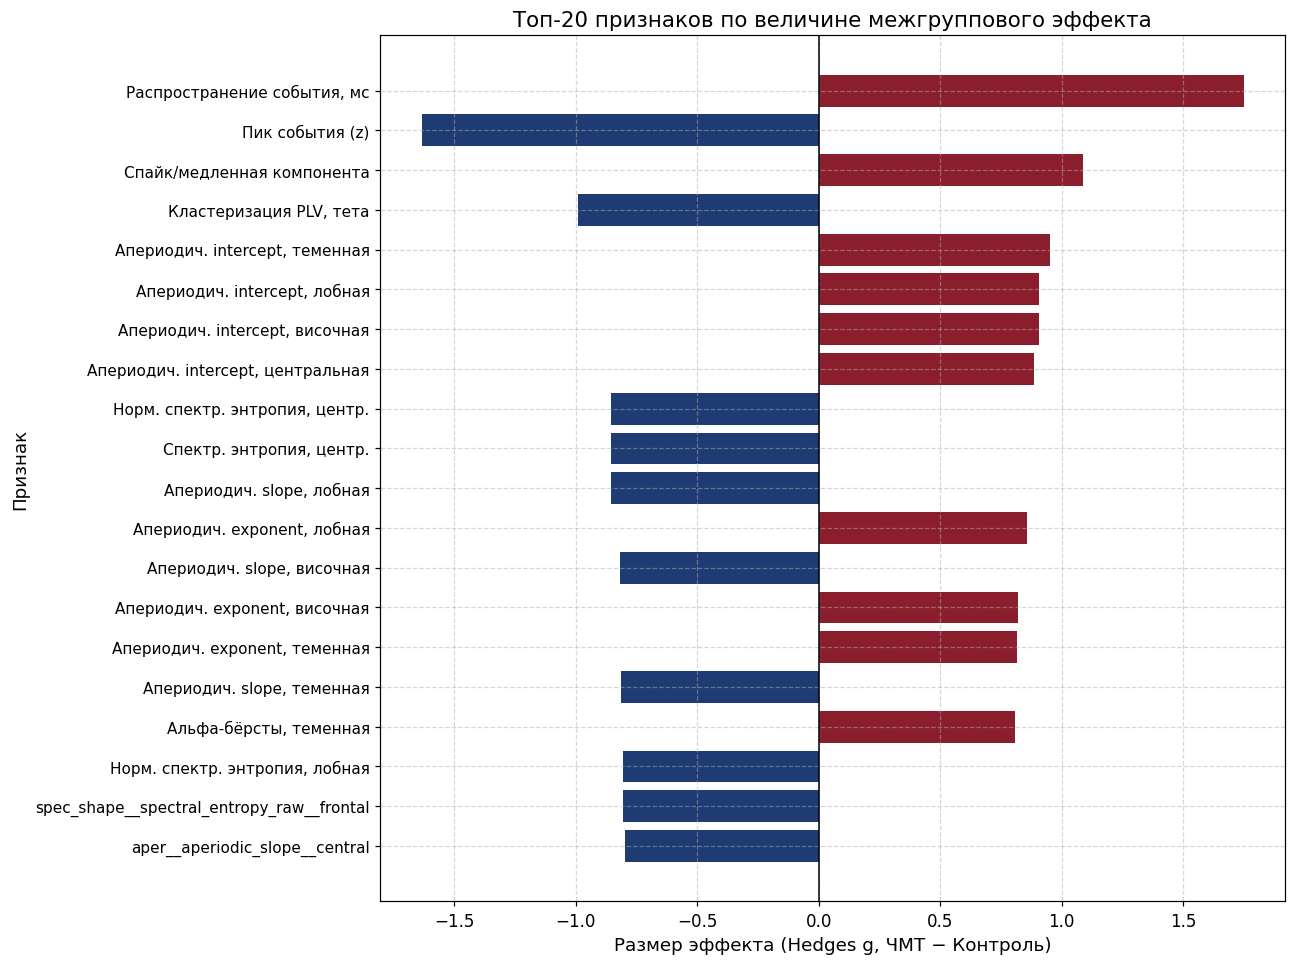

Расшифровка подписей:


,Короткое название на графике,Полная расшифровка,Hedges g (ЧМТ − Контроль)
0,"Распространение события, мс",Время пространственного распространения событи...,1.748248
1,Пик события (z),Нормированная амплитуда пика события (z-значение),-1.635020
2,Спайк/медленная компонента,Отношение амплитуды спайковой и медленной комп...,1.085900
3,"Кластеризация PLV, тета",Коэффициент кластеризации функциональной сети ...,-0.991217
4,"Апериодич. intercept, теменная",Логарифм свободного члена апериодической компо...,0.950219
5,"Апериодич. intercept, лобная",Логарифм свободного члена апериодической компо...,0.907076
6,"Апериодич. intercept, височная",Логарифм свободного члена апериодической компо...,0.904690
7,"Апериодич. intercept, центральная",Логарифм свободного члена апериодической компо...,0.883701
8,"Норм. спектр. энтропия, центр.","Нормированная спектральная энтропия, центральн...",-0.855594
9,"Спектр. энтропия, центр.","Спектральная энтропия, центральная область",-0.855594


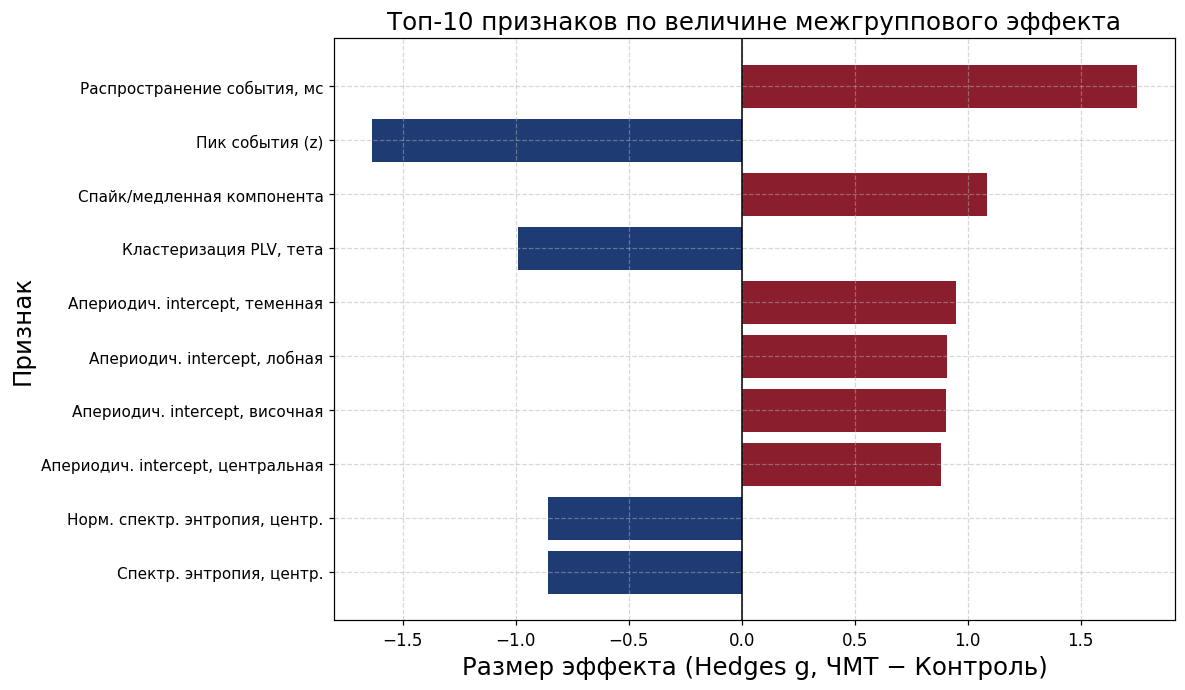

In [22]:
# @title 3.3. Топ-20 признаков: короткие подписи и таблица расшифровок

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# =========================================
# 1. Короткие русские подписи для графика
# =========================================
feature_name_short_ru = {
    "event__propagation_ms": "Распространение события, мс",
    "event__z_peak": "Пик события (z)",
    "event__spike_to_slow_ratio": "Спайк/медленная компонента",

    "conn__clustering__plv_theta": "Кластеризация PLV, тета",

    "aper__aperiodic_intercept_log10__parietal": "Апериодич. intercept, теменная",
    "aper__aperiodic_intercept_log10__frontal": "Апериодич. intercept, лобная",
    "aper__aperiodic_intercept_log10__temporal": "Апериодич. intercept, височная",
    "aper__aperiodic_intercept_log10__central": "Апериодич. intercept, центральная",

    "aper__aperiodic_slope__frontal": "Апериодич. slope, лобная",
    "aper__aperiodic_exponent__frontal": "Апериодич. exponent, лобная",
    "aper__aperiodic_exponent__temporal": "Апериодич. exponent, височная",
    "aper__aperiodic_slope__temporal": "Апериодич. slope, височная",
    "aper__aperiodic_slope__parietal": "Апериодич. slope, теменная",
    "aper__aperiodic_exponent__parietal": "Апериодич. exponent, теменная",

    "spec_shape__spectral_entropy_norm__central": "Норм. спектр. энтропия, центр.",
    "spec_shape__spectral_entropy_raw__central": "Спектр. энтропия, центр.",
    "spec_shape__spectral_entropy_norm__frontal": "Норм. спектр. энтропия, лобная",

    "idx__rel_delta__central": "Отн. дельта-мощность, центр.",
    "bp__bandpower_rel__central_delta": "Отн. bandpower delta, центр.",

    "burst__pct_time__parietal_alpha": "Альфа-бёрсты, теменная",
}

# =========================================
# 2. Полные русские подписи для таблицы
# =========================================
feature_name_full_ru = {
    "event__propagation_ms":
        "Время пространственного распространения события, мс",

    "event__z_peak":
        "Нормированная амплитуда пика события (z-значение)",

    "event__spike_to_slow_ratio":
        "Отношение амплитуды спайковой и медленной компонентов события",

    "conn__clustering__plv_theta":
        "Коэффициент кластеризации функциональной сети (PLV, тета-диапазон)",

    "aper__aperiodic_intercept_log10__parietal":
        "Логарифм свободного члена апериодической компоненты спектра, теменная область",

    "aper__aperiodic_intercept_log10__frontal":
        "Логарифм свободного члена апериодической компоненты спектра, лобная область",

    "aper__aperiodic_intercept_log10__temporal":
        "Логарифм свободного члена апериодической компоненты спектра, височная область",

    "aper__aperiodic_intercept_log10__central":
        "Логарифм свободного члена апериодической компоненты спектра, центральная область",

    "aper__aperiodic_slope__frontal":
        "Наклон апериодической компоненты спектра, лобная область",

    "aper__aperiodic_exponent__frontal":
        "Экспонента апериодической компоненты спектра, лобная область",

    "aper__aperiodic_exponent__temporal":
        "Экспонента апериодической компоненты спектра, височная область",

    "aper__aperiodic_slope__temporal":
        "Наклон апериодической компоненты спектра, височная область",

    "aper__aperiodic_slope__parietal":
        "Наклон апериодической компоненты спектра, теменная область",

    "aper__aperiodic_exponent__parietal":
        "Экспонента апериодической компоненты спектра, теменная область",

    "spec_shape__spectral_entropy_norm__central":
        "Нормированная спектральная энтропия, центральная область",

    "spec_shape__spectral_entropy_raw__central":
        "Спектральная энтропия, центральная область",

    "spec_shape__spectral_entropy_norm__frontal":
        "Нормированная спектральная энтропия, лобная область",

    "idx__rel_delta__central":
        "Относительная мощность дельта-диапазона, центральная область",

    "bp__bandpower_rel__central_delta":
        "Относительная спектральная мощность дельта-диапазона, центральная область",

    "burst__pct_time__parietal_alpha":
        "Доля времени с альфа-ритмическими бёрстами, теменная область",
}

# =========================================
# 3. Цвета
# =========================================
COLOR_TBI = "#8B1E2D"
COLOR_CONTROL = "#1F3B73"

# =========================================
# 4. Подготовка top-20
# =========================================
top20 = effect_df.head(20).copy()

top20["label_short"] = top20["feature"].map(lambda x: feature_name_short_ru.get(x, x))
top20["label_full"] = top20["feature"].map(lambda x: feature_name_full_ru.get(x, x))

plot_df = top20.iloc[::-1].copy()

# =========================================
# 5. График
# =========================================
plt.figure(figsize=(12, 9))
plt.barh(
    plot_df["label_short"],
    plot_df["hedges_g_tbi_minus_control"],
    color=[
        COLOR_TBI if v > 0 else COLOR_CONTROL
        for v in plot_df["hedges_g_tbi_minus_control"]
    ]
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Размер эффекта (Hedges g, ЧМТ − Контроль)", fontsize=12)
plt.ylabel("Признак", fontsize=12)
plt.title("Топ-20 признаков по величине межгруппового эффекта", fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(
    OUT_DIR / "plot_final_top20_features_hedges_g_short_ru.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()

# =========================================
# 6. Таблица расшифровок
# =========================================
legend_df = top20[["label_short", "label_full", "hedges_g_tbi_minus_control"]].copy()
legend_df.columns = [
    "Короткое название на графике",
    "Полная расшифровка",
    "Hedges g (ЧМТ − Контроль)"
]

print("Расшифровка подписей:")
display(legend_df.reset_index(drop=True))
# @title Top-10 признаков для слайда

top10 = effect_df.head(10).copy()
top10["label_short"] = top10["feature"].map(lambda x: feature_name_short_ru.get(x, x))
plot_df = top10.iloc[::-1].copy()

plt.figure(figsize=(11, 6.5))
plt.barh(
    plot_df["label_short"],
    plot_df["hedges_g_tbi_minus_control"],
    color=[
        COLOR_TBI if v > 0 else COLOR_CONTROL
        for v in plot_df["hedges_g_tbi_minus_control"]
    ]
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Размер эффекта (Hedges g, ЧМТ − Контроль)")
plt.ylabel("Признак")
plt.title("Топ-10 признаков по величине межгруппового эффекта")
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [23]:
# @title 3.4. Компактная таблица топ-10 признаков для основной главы


from pathlib import Path
import pandas as pd


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"
EFFECT_PATH = EDA_DIR / "final_eda_effect_sizes.csv"

if not EFFECT_PATH.exists():
    EFFECT_PATH = Path("/mnt/data/final_eda_effect_sizes.csv")

OUT_PATH = EDA_DIR / "table_top10_key_features_compact.csv"


# =========================================
# 1. Загрузка
# =========================================
df_eff = pd.read_csv(EFFECT_PATH)


# =========================================
# 2. Направление различий
# =========================================
def direction_label(mean_tbi, mean_control):
    if mean_tbi > mean_control:
        return "↑ ЧМТ"
    if mean_tbi < mean_control:
        return "↓ ЧМТ"
    return "="


# =========================================
# 3. Таблица
# =========================================
top10 = df_eff.head(10).copy()

top10["Направление"] = top10.apply(
    lambda r: direction_label(r["mean_tbi"], r["mean_control"]),
    axis=1
)

top10["Среднее (ЧМТ)"] = top10["mean_tbi"].round(3)
top10["Среднее (контроль)"] = top10["mean_control"].round(3)
top10["|d|"] = top10["abs_cohens_d"].round(3)

table_top10 = top10[
    ["feature", "block", "Среднее (ЧМТ)", "Среднее (контроль)", "|d|", "Направление"]
].copy()

table_top10 = table_top10.rename(
    columns={
        "feature": "Признак",
        "block": "Блок",
    }
)

table_top10.to_csv(OUT_PATH, index=False, encoding="utf-8")

print("✅ Компактная таблица top-10 сохранена")
print("Путь:", OUT_PATH)
display(table_top10)

✅ Компактная таблица top-10 сохранена
Путь: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/table_top10_key_features_compact.csv


,Признак,Блок,Среднее (ЧМТ),Среднее (контроль),|d|,Направление
0,event__propagation_ms,event,69.205,49.442,1.751,↑ ЧМТ
1,event__z_peak,event,3.042,4.248,1.637,↓ ЧМТ
2,event__spike_to_slow_ratio,event,1.269,0.784,1.087,↑ ЧМТ
3,conn__clustering__plv_theta,conn,0.343,0.412,0.993,↓ ЧМТ
4,aper__aperiodic_intercept_log10__parietal,aper,-8.392,-8.889,0.951,↑ ЧМТ
5,aper__aperiodic_intercept_log10__frontal,aper,-8.469,-9.011,0.908,↑ ЧМТ
6,aper__aperiodic_intercept_log10__temporal,aper,-8.411,-8.984,0.906,↑ ЧМТ
7,aper__aperiodic_intercept_log10__central,aper,-8.598,-9.084,0.885,↑ ЧМТ
8,spec_shape__spectral_entropy_norm__central,spec_shape,0.826,0.883,0.857,↓ ЧМТ
9,spec_shape__spectral_entropy_raw__central,spec_shape,4.275,4.569,0.857,↓ ЧМТ


## 4. Переход к subject-level анализу

Для машинного обучения и статистического сравнения итоговой единицей анализа является субъект, а не отдельная эпоха или запись. Это снижает риск завышения качества модели из-за зависимых наблюдений.

In [24]:
# @title 4.1. Агрегация признаков: record-level → subject-level


from pathlib import Path
import re
import pandas as pd


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
CORE_PATH = BASE_DIR / "all_features_record_level_core.csv"
EDA_DIR = BASE_DIR / "eda_record_level_core"
FEATURE_LIST_PATH = EDA_DIR / "features_neuro_clean_final.csv"

if not CORE_PATH.exists():
    CORE_PATH = Path("/mnt/data/all_features_record_level_core.csv")

if not FEATURE_LIST_PATH.exists():
    FEATURE_LIST_PATH = Path("/mnt/data/features_neuro_clean_final.csv")

OUT_SUBJ = EDA_DIR / "subject_level_core_clean.csv"
OUT_SUBJ_MAP = EDA_DIR / "subject_level_core_clean_summary.csv"


# =========================================
# 1. Загрузка
# =========================================
df = pd.read_csv(CORE_PATH)
feat_df = pd.read_csv(FEATURE_LIST_PATH)

df["group"] = df["group"].astype(str).str.strip()
df["record_id"] = df["record_id"].astype(str).str.strip()

final_features = feat_df["feature"].tolist()


# =========================================
# 2. Восстановление subject_id
# =========================================
def infer_subject_id(record_id):
    s = str(record_id)

    m = re.search(r"(sub-\d+)", s, flags=re.IGNORECASE)
    if m:
        return m.group(1).lower()

    m = re.search(r"tbi_soft_(\d+)", s, flags=re.IGNORECASE)
    if m:
        return f"tbi-{m.group(1)}"

    parts = s.split("_")
    if len(parts) >= 2:
        return "_".join(parts[:2]).lower()

    return s.lower()


df["subject_id"] = df["record_id"].map(infer_subject_id)


# =========================================
# 3. Оставляем нужные колонки
# =========================================
keep_cols = ["group", "record_id", "subject_id"] + final_features
work = df[keep_cols].copy()


# =========================================
# 4. Проверка согласованности group внутри subject
# =========================================
group_check = (
    work.groupby("subject_id")["group"]
    .nunique()
    .reset_index(name="n_groups")
)

bad_subjects = group_check[group_check["n_groups"] > 1]

if len(bad_subjects) > 0:
    print("⚠️ Найдены subject_id с несколькими группами:")
    display(bad_subjects.head(20))
else:
    print("✅ У каждого subject_id только одна группа")


# =========================================
# 5. Subject-level aggregation
# =========================================
agg_dict = {c: "median" for c in final_features}

subject_level = (
    work.groupby(["group", "subject_id"], as_index=False)
    .agg(agg_dict)
)

n_records_df = (
    work.groupby(["group", "subject_id"], as_index=False)["record_id"]
    .nunique()
    .rename(columns={"record_id": "n_records_subject"})
)

subject_level = subject_level.merge(
    n_records_df,
    on=["group", "subject_id"],
    how="left"
)

subject_level = subject_level.sort_values(["group", "subject_id"]).reset_index(drop=True)


# =========================================
# 6. Сохранение
# =========================================
subject_level.to_csv(OUT_SUBJ, index=False, encoding="utf-8")

summary_df = pd.DataFrame([{
    "n_subjects_total": subject_level["subject_id"].nunique(),
    "n_subjects_tbi": subject_level.loc[subject_level["group"] == "TBI", "subject_id"].nunique(),
    "n_subjects_control": subject_level.loc[subject_level["group"] == "Control", "subject_id"].nunique(),
    "n_features": len(final_features),
    "median_records_per_subject_tbi": subject_level.loc[subject_level["group"] == "TBI", "n_records_subject"].median(),
    "median_records_per_subject_control": subject_level.loc[subject_level["group"] == "Control", "n_records_subject"].median(),
}])

summary_df.to_csv(OUT_SUBJ_MAP, index=False, encoding="utf-8")


# =========================================
# 7. Вывод
# =========================================
print("✅ Subject-level clean matrix готова")
print("Путь:", OUT_SUBJ)
display(summary_df)
display(subject_level.head(3))

✅ У каждого subject_id только одна группа
✅ Subject-level clean matrix готова
Путь: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/subject_level_core_clean.csv


,n_subjects_total,n_subjects_tbi,n_subjects_control,n_features,median_records_per_subject_tbi,median_records_per_subject_control
0,164,92,72,426,3.0,4.0


,group,subject_id,alpha_peak__paf_hz__central,alpha_peak__paf_hz__frontal,alpha_peak__paf_hz__occipital,alpha_peak__paf_hz__parietal,alpha_peak__paf_hz__temporal,alpha_peak__alpha_peak_amp_db__central,alpha_peak__alpha_peak_amp_db__frontal,alpha_peak__alpha_peak_amp_db__occipital,...,event__slope_fall_uvs,event__sharpness_uv,event__z_peak,event__slow_peak_uv,event__spike_to_slow_ratio,event__n_involved_ch,event__lr_index,event__spread_rois,event__propagation_ms,n_records_subject
0,Control,sub-001,14.0,6.0,6.0,14.0,14.0,35.122723,35.618618,33.054700,...,-2010.730028,11.292291,4.285149,21.862072,0.761251,11.5,0.0,3.5,39.5,4
1,Control,sub-002,14.0,6.0,6.0,6.0,6.0,36.886632,37.548729,33.835282,...,-4801.985025,19.076922,3.404637,41.363046,0.886094,14.0,0.0,4.0,64.0,4
2,Control,sub-003,6.0,6.0,6.0,6.0,6.0,40.756834,40.176352,39.108695,...,-1088.601351,5.985477,4.856647,9.531061,0.650597,14.5,0.0,4.0,33.0,4


In [25]:
# @title 4.2. Статистика на уровне субъектов: Манна–Уитни, FDR и размер эффекта

from pathlib import Path
import math
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"
SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"

if not SUBJ_PATH.exists():
    SUBJ_PATH = Path("/mnt/data/subject_level_core_clean.csv")

OUT_STATS = EDA_DIR / "subject_level_statistics_all_features.csv"
OUT_SIG = EDA_DIR / "subject_level_statistics_significant_fdr.csv"
OUT_BLOCKS = EDA_DIR / "subject_level_statistics_blocks_summary.csv"


# =========================================
# 1. Загрузка
# =========================================
df = pd.read_csv(SUBJ_PATH)

df["group"] = df["group"].astype(str).str.strip()

key_cols = ["group", "subject_id", "n_records_subject"]
feature_cols = [c for c in df.columns if c not in key_cols]


# =========================================
# 2. Функции
# =========================================
def get_block(col):
    if "__" in col:
        return col.split("__")[0]
    return "other"


def cohens_d(x1, x2):
    x1 = pd.Series(x1).dropna().astype(float)
    x2 = pd.Series(x2).dropna().astype(float)

    if len(x1) < 2 or len(x2) < 2:
        return np.nan

    v1 = x1.var(ddof=1)
    v2 = x2.var(ddof=1)
    pooled = ((len(x1) - 1) * v1 + (len(x2) - 1) * v2) / (len(x1) + len(x2) - 2)

    if pd.isna(pooled) or pooled <= 0:
        return np.nan

    return (x1.mean() - x2.mean()) / np.sqrt(pooled)


def fdr_bh(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]

    q = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        q[i] = prev

    out = np.empty(n, dtype=float)
    out[order] = np.clip(q, 0, 1)
    return out


def direction_label(mean_tbi, mean_control):
    if mean_tbi > mean_control:
        return "↑ ЧМТ"
    if mean_tbi < mean_control:
        return "↓ ЧМТ"
    return "="


# =========================================
# 3. Статистика по всем признакам
# =========================================
rows = []

for col in feature_cols:
    x_tbi = df.loc[df["group"] == "TBI", col].dropna()
    x_ctl = df.loc[df["group"] == "Control", col].dropna()

    if len(x_tbi) < 2 or len(x_ctl) < 2:
        pval = np.nan
        stat = np.nan
    else:
        stat, pval = mannwhitneyu(x_tbi, x_ctl, alternative="two-sided")

    mean_tbi = x_tbi.mean()
    mean_ctl = x_ctl.mean()

    rows.append({
        "feature": col,
        "block": get_block(col),
        "n_tbi": len(x_tbi),
        "n_control": len(x_ctl),
        "mean_tbi": mean_tbi,
        "mean_control": mean_ctl,
        "median_tbi": x_tbi.median(),
        "median_control": x_ctl.median(),
        "mw_u": stat,
        "p_value": pval,
        "cohens_d_tbi_minus_control": cohens_d(x_tbi, x_ctl),
        "abs_cohens_d": abs(cohens_d(x_tbi, x_ctl)) if pd.notna(cohens_d(x_tbi, x_ctl)) else np.nan,
        "direction": direction_label(mean_tbi, mean_ctl),
    })

stats_df = pd.DataFrame(rows)

valid_mask = stats_df["p_value"].notna()
stats_df.loc[valid_mask, "q_value_fdr"] = fdr_bh(stats_df.loc[valid_mask, "p_value"].values)
stats_df.loc[~valid_mask, "q_value_fdr"] = np.nan

stats_df["significant_fdr_05"] = stats_df["q_value_fdr"] < 0.05
stats_df = stats_df.sort_values(["q_value_fdr", "abs_cohens_d"], ascending=[True, False]).reset_index(drop=True)

stats_df.to_csv(OUT_STATS, index=False, encoding="utf-8")


# =========================================
# 4. Значимые признаки
# =========================================
sig_df = stats_df[stats_df["significant_fdr_05"]].copy()
sig_df.to_csv(OUT_SIG, index=False, encoding="utf-8")


# =========================================
# 5. Сводка по блокам
# =========================================
block_summary = (
    stats_df.groupby("block")
    .agg(
        n_features=("feature", "count"),
        n_significant_fdr_05=("significant_fdr_05", "sum"),
        min_q_value=("q_value_fdr", "min"),
        median_abs_d=("abs_cohens_d", "median"),
        max_abs_d=("abs_cohens_d", "max"),
    )
    .reset_index()
    .sort_values(["n_significant_fdr_05", "median_abs_d"], ascending=[False, False])
)

block_summary.to_csv(OUT_BLOCKS, index=False, encoding="utf-8")


# =========================================
# 6. Вывод
# =========================================
print("✅ Subject-level statistics готовы")
print("Все признаки:", OUT_STATS)
print("Только значимые:", OUT_SIG)
print("Сводка по блокам:", OUT_BLOCKS)

print("\n=== SUBJECT-LEVEL STATS SUMMARY ===")
summary_df = pd.DataFrame([{
    "n_features_tested": len(stats_df),
    "n_significant_fdr_05": int(sig_df.shape[0]),
    "top_feature": stats_df.iloc[0]["feature"] if len(stats_df) else None,
    "top_q_value": stats_df.iloc[0]["q_value_fdr"] if len(stats_df) else None,
    "top_abs_d": stats_df.iloc[0]["abs_cohens_d"] if len(stats_df) else None,
}])
display(summary_df)

print("\n=== TOP SUBJECT-LEVEL FEATURES ===")
display(stats_df.head(20))

print("\n=== BLOCK SUMMARY ===")
display(block_summary)

✅ Subject-level statistics готовы
Все признаки: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/subject_level_statistics_all_features.csv
Только значимые: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/subject_level_statistics_significant_fdr.csv
Сводка по блокам: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/subject_level_statistics_blocks_summary.csv

=== SUBJECT-LEVEL STATS SUMMARY ===


,n_features_tested,n_significant_fdr_05,top_feature,top_q_value,top_abs_d
0,426,203,event__z_peak,8.108984e-22,2.341103



=== TOP SUBJECT-LEVEL FEATURES ===


,feature,block,n_tbi,n_control,mean_tbi,mean_control,median_tbi,median_control,mw_u,p_value,cohens_d_tbi_minus_control,abs_cohens_d,direction,q_value_fdr,significant_fdr_05
0,event__z_peak,event,92,72,3.052323,4.219268,3.004158,4.216311,232.0,1.903517e-24,-2.341103,2.341103,↓ ЧМТ,8.108984e-22,True
1,event__propagation_ms,event,92,72,69.331522,49.250000,69.000000,48.500000,6235.0,3.517085e-22,2.213750,2.213750,↑ ЧМТ,7.491390e-20,True
2,event__spike_to_slow_ratio,event,92,72,1.195560,0.779795,0.990313,0.772589,6096.0,2.884725e-20,1.087972,1.087972,↑ ЧМТ,4.096310e-18,True
3,burst__median_ibi_sec__occipital_alpha,burst,92,72,1.025761,1.609688,0.897500,1.506250,650.5,1.169871e-18,-0.817719,0.817719,↓ ЧМТ,1.245912e-16,True
4,conn__clustering__plv_theta,conn,92,72,0.339340,0.407667,0.329184,0.402701,867.0,5.501388e-16,-1.357537,1.357537,↓ ЧМТ,4.687183e-14,True
5,burst__median_ibi_sec__frontal_alpha,burst,92,72,1.057310,1.582153,0.935000,1.442500,939.5,3.848815e-15,-0.791118,0.791118,↓ ЧМТ,2.468534e-13,True
6,burst__median_ibi_sec__parietal_alpha,burst,92,72,1.052717,1.561250,0.942500,1.446250,941.5,4.056277e-15,-0.721919,0.721919,↓ ЧМТ,2.468534e-13,True
7,burst__median_ibi_sec__central_alpha,burst,92,72,1.002092,1.497500,0.995000,1.417500,1008.0,2.294714e-14,-1.203243,1.203243,↓ ЧМТ,1.221935e-12,True
8,event__n_involved_ch,event,92,72,16.179348,12.843750,15.625000,12.750000,5569.5,6.457639e-14,1.135995,1.135995,↑ ЧМТ,3.056616e-12,True
9,event__line_length_uv,event,92,72,75.664632,42.921706,63.890077,39.686158,5519.0,2.646425e-13,0.552351,0.552351,↑ ЧМТ,1.127377e-11,True



=== BLOCK SUMMARY ===


,block,n_features,n_significant_fdr_05,min_q_value,median_abs_d,max_abs_d
3,conn,220,74,4.687183e-14,0.226639,1.357537
2,burst,80,51,1.245912e-16,0.387081,1.203243
1,aper,30,16,5.366463e-10,0.507534,1.147381
7,spec_shape,15,15,1.155455e-08,0.844934,1.049910
5,event,14,13,8.108984e-22,0.732108,2.341103
8,tfr,30,11,1.746430e-05,0.176914,0.439317
0,alpha_peak,15,10,1.607458e-05,0.423430,0.737668
4,dfa,10,7,1.980628e-08,0.569895,1.102092
6,gamma,12,6,5.933793e-08,0.256589,0.825830


## 5. Базовая спектральная модель bp + idx

Базовая модель используется как контрольная точка: она построена на спектральной мощности и интегральных спектральных индексах. С ней далее сравниваются событийные и расширенные модели.

In [26]:
# @title 5.1. Базовая спектральная модель: подготовка матрицы bp + idx


from pathlib import Path
import pandas as pd


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"

if not SUBJ_PATH.exists():
    SUBJ_PATH = Path("/mnt/data/subject_level_core_clean.csv")

OUT_X = EDA_DIR / "baseline_bp_idx_X.csv"
OUT_Y = EDA_DIR / "baseline_bp_idx_y.csv"
OUT_INFO = EDA_DIR / "baseline_bp_idx_info.csv"


# =========================================
# 1. Загрузка
# =========================================
df = pd.read_csv(SUBJ_PATH)
df["group"] = df["group"].astype(str).str.strip()
df["subject_id"] = df["subject_id"].astype(str).str.strip()

key_cols = ["group", "subject_id", "n_records_subject"]
feature_cols = [c for c in df.columns if c not in key_cols]


# =========================================
# 2. Выбор baseline-блоков
# =========================================
baseline_blocks = ["bp", "idx"]

baseline_features = [
    c for c in feature_cols
    if c.split("__")[0] in baseline_blocks
]

X = df[baseline_features].copy()
y = df["group"].map({"Control": 0, "TBI": 1}).astype(int)

info_df = pd.DataFrame([{
    "n_subjects_total": len(df),
    "n_subjects_tbi": int((df["group"] == "TBI").sum()),
    "n_subjects_control": int((df["group"] == "Control").sum()),
    "n_features_baseline": len(baseline_features),
    "blocks_used": ", ".join(baseline_blocks),
}])

X.to_csv(OUT_X, index=False, encoding="utf-8")
y.to_frame("y").to_csv(OUT_Y, index=False, encoding="utf-8")
info_df.to_csv(OUT_INFO, index=False, encoding="utf-8")

print("✅ Baseline-матрица bp + idx подготовлена")
display(info_df)
print("\nПервые признаки:")
display(pd.DataFrame({"feature": baseline_features}).head(20))

✅ Baseline-матрица bp + idx подготовлена


,n_subjects_total,n_subjects_tbi,n_subjects_control,n_features_baseline,blocks_used
0,164,92,72,0,"bp, idx"



Первые признаки:


,feature


✅ Permutation test для baseline bp + idx завершён


,real_auc_mean,perm_auc_mean_mean,perm_auc_mean_std,perm_auc_min,perm_auc_max,empirical_p_value,n_permutations
0,0.87233,0.498448,0.056165,0.368219,0.639114,0.004975,200


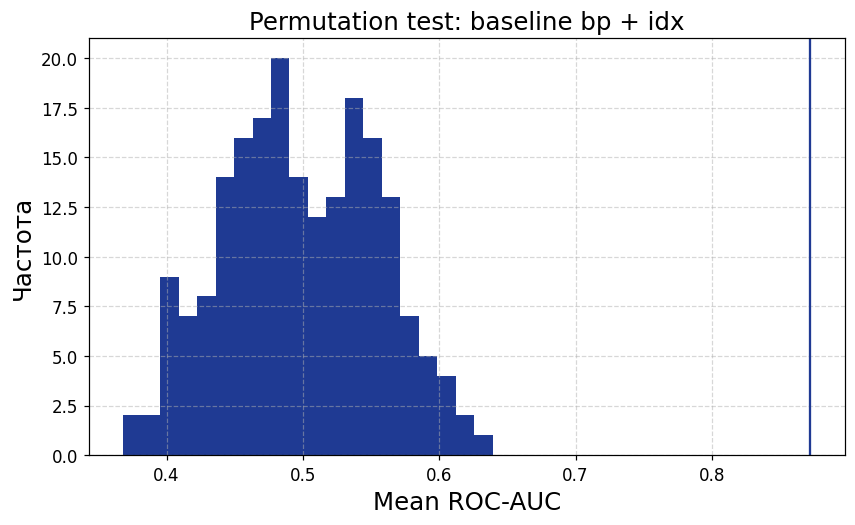

In [ ]:
# @title 5.2. Базовая спектральная модель: перестановочный тест


from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"
if not SUBJ_PATH.exists():
    SUBJ_PATH = Path("/mnt/data/subject_level_core_clean.csv")

OUT_PERM = EDA_DIR / "baseline_bp_idx_permutation_scores.csv"


# =========================================
# 1. Данные
# =========================================
df = pd.read_csv(SUBJ_PATH)
df["group"] = df["group"].astype(str).str.strip()

key_cols = ["group", "subject_id", "n_records_subject"]
feature_cols = [c for c in df.columns if c not in key_cols]
baseline_features = [c for c in feature_cols if c.split("__")[0] in ["bp", "idx"]]

X = df[baseline_features].copy()
y = df["group"].map({"Control": 0, "TBI": 1}).astype(int).values


# =========================================
# 2. Модель
# =========================================
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="liblinear",
        max_iter=5000,
        class_weight="balanced",
        random_state=42,
    )),
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42,
)

real_scores = cross_val_score(
    pipe,
    X,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
)
real_auc_mean = real_scores.mean()


# =========================================
# 3. Перестановки
# =========================================
n_perm = 200
rng = np.random.RandomState(42)

perm_scores = []
for _ in range(n_perm):
    y_perm = rng.permutation(y)
    score = cross_val_score(
        pipe,
        X,
        y_perm,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
    ).mean()
    perm_scores.append(score)

perm_scores = np.array(perm_scores)

p_empirical = (np.sum(perm_scores >= real_auc_mean) + 1) / (n_perm + 1)

perm_df = pd.DataFrame({
    "perm_idx": np.arange(n_perm),
    "perm_auc_mean": perm_scores,
})
perm_df.to_csv(OUT_PERM, index=False, encoding="utf-8")

summary_df = pd.DataFrame([{
    "real_auc_mean": real_auc_mean,
    "perm_auc_mean_mean": perm_scores.mean(),
    "perm_auc_mean_std": perm_scores.std(),
    "perm_auc_min": perm_scores.min(),
    "perm_auc_max": perm_scores.max(),
    "empirical_p_value": p_empirical,
    "n_permutations": n_perm,
}])

print("✅ Permutation test для baseline bp + idx завершён")
display(summary_df)

plt.figure(figsize=(8, 5))
plt.hist(perm_scores, bins=20)
plt.axvline(real_auc_mean)
plt.xlabel("Mean ROC-AUC")
plt.ylabel("Частота")
plt.title("Permutation test: baseline bp + idx")
plt.tight_layout()
plt.show()

In [27]:
# @title 5.3. Базовая спектральная модель: устойчивость при разных схемах кросс-валидации


from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, StratifiedShuffleSplit, LeaveOneOut, cross_validate
from sklearn.metrics import make_scorer, balanced_accuracy_score, f1_score


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"
if not SUBJ_PATH.exists():
    SUBJ_PATH = Path("/mnt/data/subject_level_core_clean.csv")

OUT_CV = EDA_DIR / "baseline_bp_idx_cv_protocols.csv"


# =========================================
# 1. Данные
# =========================================
df = pd.read_csv(SUBJ_PATH)
df["group"] = df["group"].astype(str).str.strip()

key_cols = ["group", "subject_id", "n_records_subject"]
feature_cols = [c for c in df.columns if c not in key_cols]
baseline_features = [c for c in feature_cols if c.split("__")[0] in ["bp", "idx"]]

X = df[baseline_features].copy()
y = df["group"].map({"Control": 0, "TBI": 1}).astype(int)


# =========================================
# 2. Pipeline
# =========================================
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="liblinear",
        max_iter=5000,
        class_weight="balanced",
        random_state=42,
    )),
])

scoring = {
    "roc_auc": "roc_auc",
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "f1": make_scorer(f1_score),
    "accuracy": "accuracy",
}


# =========================================
# 3. Протоколы
# =========================================
cv_dict = {
    "stratified_kfold_5": StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    "repeated_stratified_kfold_5x10": RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42),
    "stratified_shuffle_20x20pct": StratifiedShuffleSplit(n_splits=20, test_size=0.2, random_state=42),
}

rows = []

for cv_name, cv in cv_dict.items():
    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    rows.append({
        "cv_protocol": cv_name,
        "roc_auc_mean": np.mean(scores["test_roc_auc"]),
        "roc_auc_std": np.std(scores["test_roc_auc"]),
        "balanced_accuracy_mean": np.mean(scores["test_balanced_accuracy"]),
        "balanced_accuracy_std": np.std(scores["test_balanced_accuracy"]),
        "f1_mean": np.mean(scores["test_f1"]),
        "f1_std": np.std(scores["test_f1"]),
        "accuracy_mean": np.mean(scores["test_accuracy"]),
        "accuracy_std": np.std(scores["test_accuracy"]),
        "n_splits_total": len(scores["test_roc_auc"]),
    })

loo = LeaveOneOut()
scores_loo = cross_validate(
    pipe,
    X,
    y,
    cv=loo,
    scoring={"accuracy": "accuracy"},
    n_jobs=-1,
    return_train_score=False,
)

rows.append({
    "cv_protocol": "leave_one_out_accuracy_only",
    "roc_auc_mean": np.nan,
    "roc_auc_std": np.nan,
    "balanced_accuracy_mean": np.nan,
    "balanced_accuracy_std": np.nan,
    "f1_mean": np.nan,
    "f1_std": np.nan,
    "accuracy_mean": np.mean(scores_loo["test_accuracy"]),
    "accuracy_std": np.std(scores_loo["test_accuracy"]),
    "n_splits_total": len(scores_loo["test_accuracy"]),
})

res_df = pd.DataFrame(rows)
res_df.to_csv(OUT_CV, index=False, encoding="utf-8")

print("✅ CV-устойчивость baseline bp + idx завершена")
display(res_df)

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 588, in _fit
 

In [28]:
# @title 5.4. Базовая спектральная модель: шумовой стресс-тест


from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, balanced_accuracy_score, f1_score


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"
if not SUBJ_PATH.exists():
    SUBJ_PATH = Path("/mnt/data/subject_level_core_clean.csv")

OUT_NOISE = EDA_DIR / "baseline_bp_idx_noise_test.csv"


# =========================================
# 1. Данные
# =========================================
df = pd.read_csv(SUBJ_PATH)
df["group"] = df["group"].astype(str).str.strip()

key_cols = ["group", "subject_id", "n_records_subject"]
feature_cols = [c for c in df.columns if c not in key_cols]
baseline_features = [c for c in feature_cols if c.split("__")[0] in ["bp", "idx"]]

X = df[baseline_features].copy()
y = df["group"].map({"Control": 0, "TBI": 1}).astype(int)


# =========================================
# 2. Функция шума
# =========================================
def add_noise_factory(noise_std, seed=42):
    rng = np.random.RandomState(seed)
    def add_noise(X_array):
        noise = rng.normal(0.0, noise_std, size=X_array.shape)
        return X_array + noise
    return add_noise


# =========================================
# 3. CV
# =========================================
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42,
)

scoring = {
    "roc_auc": "roc_auc",
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "f1": make_scorer(f1_score),
    "accuracy": "accuracy",
}


# =========================================
# 4. По уровням шума
# =========================================
noise_levels = [0.0, 0.1, 0.25, 0.5, 1.0]
rows = []

for noise_std in noise_levels:
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("noise", FunctionTransformer(add_noise_factory(noise_std), validate=False)),
        ("clf", LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            max_iter=5000,
            class_weight="balanced",
            random_state=42,
        )),
    ])

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    rows.append({
        "noise_std": noise_std,
        "roc_auc_mean": np.mean(scores["test_roc_auc"]),
        "roc_auc_std": np.std(scores["test_roc_auc"]),
        "balanced_accuracy_mean": np.mean(scores["test_balanced_accuracy"]),
        "balanced_accuracy_std": np.std(scores["test_balanced_accuracy"]),
        "f1_mean": np.mean(scores["test_f1"]),
        "f1_std": np.std(scores["test_f1"]),
        "accuracy_mean": np.mean(scores["test_accuracy"]),
        "accuracy_std": np.std(scores["test_accuracy"]),
    })

res_df = pd.DataFrame(rows)
res_df.to_csv(OUT_NOISE, index=False, encoding="utf-8")

print("✅ Шумовой тест baseline bp + idx завершён")
display(res_df)

plt.figure(figsize=(8, 5))
plt.plot(res_df["noise_std"], res_df["roc_auc_mean"], marker="o")
plt.xlabel("Уровень шума")
plt.ylabel("Mean ROC-AUC")
plt.title("Noise test: baseline bp + idx")
plt.tight_layout()
plt.show()

ValueError: 
All the 50 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 588, in _fit

In [29]:
# @title 5.5. Базовая спектральная модель: сводная таблица для ВКР


from pathlib import Path
import pandas as pd


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

CV_PATH = EDA_DIR / "baseline_bp_idx_honest_cv_results.csv"
PERM_PATH = EDA_DIR / "baseline_bp_idx_permutation_scores.csv"
CVPROTO_PATH = EDA_DIR / "baseline_bp_idx_cv_protocols.csv"
NOISE_PATH = EDA_DIR / "baseline_bp_idx_noise_test.csv"

OUT_TABLE = EDA_DIR / "baseline_bp_idx_summary_for_thesis.csv"


# =========================================
# 1. Загрузка
# =========================================
cv_df = pd.read_csv(CV_PATH)
cvproto_df = pd.read_csv(CVPROTO_PATH)
noise_df = pd.read_csv(NOISE_PATH)

# permutation summary читаем из уже сохранённого csv с перестановками косвенно не выйдет,
# поэтому просто используем cv_df здесь, а permutation summary лучше взять из вывода той ячейки


# =========================================
# 2. Таблица
# =========================================
table_df = pd.DataFrame([{
    "Модель": "Спектральный baseline (bp + idx)",
    "Число признаков": int(cv_df.loc[0, "n_features"]),
    "ROC-AUC": f"{cv_df.loc[0, 'roc_auc_mean']:.3f} ± {cv_df.loc[0, 'roc_auc_std']:.3f}",
    "Balanced accuracy": f"{cv_df.loc[0, 'balanced_accuracy_mean']:.3f} ± {cv_df.loc[0, 'balanced_accuracy_std']:.3f}",
    "F1": f"{cv_df.loc[0, 'f1_mean']:.3f} ± {cv_df.loc[0, 'f1_std']:.3f}",
    "Accuracy": f"{cv_df.loc[0, 'accuracy_mean']:.3f} ± {cv_df.loc[0, 'accuracy_std']:.3f}",
}])

table_df.to_csv(OUT_TABLE, index=False, encoding="utf-8")

print("✅ Сводная baseline-таблица для ВКР готова")
display(table_df)

print("\n=== CV PROTOCOLS ===")
display(cvproto_df)

print("\n=== NOISE TEST ===")
display(noise_df)

✅ Сводная baseline-таблица для ВКР готова


,Модель,Число признаков,ROC-AUC,Balanced accuracy,F1,Accuracy
0,Спектральный baseline (bp + idx),120,0.883 ± 0.038,0.792 ± 0.042,0.810 ± 0.023,0.793 ± 0.035



=== CV PROTOCOLS ===


,cv_protocol,roc_auc_mean,roc_auc_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,accuracy_mean,accuracy_std,n_splits_total
0,stratified_kfold_5,0.883422,0.037979,0.792364,0.041844,0.809873,0.023129,0.792803,0.034625,5
1,repeated_stratified_kfold_5x10,0.872330,0.052261,0.785523,0.057992,0.802236,0.050739,0.784792,0.055102,50
2,stratified_shuffle_20x20pct,0.883647,0.062189,0.805921,0.062124,0.820613,0.054326,0.803030,0.059459,20
3,leave_one_out_accuracy_only,NaN,NaN,NaN,NaN,NaN,NaN,0.798780,0.400912,164



=== NOISE TEST ===


,noise_std,roc_auc_mean,roc_auc_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,accuracy_mean,accuracy_std
0,0.00,0.872330,0.052261,0.785523,0.057992,0.802236,0.050739,0.784792,0.055102
1,0.10,0.870019,0.051461,0.777865,0.065218,0.795258,0.058098,0.777386,0.062866
2,0.25,0.831922,0.057240,0.721448,0.073690,0.748483,0.069276,0.723674,0.072117
3,0.50,0.771071,0.067693,0.664799,0.067669,0.701005,0.068481,0.668883,0.066286
4,1.00,0.686106,0.081090,0.615236,0.071137,0.656622,0.063252,0.619508,0.067590


## 6. Оценка качества и защита от утечки признаков

В этом блоке отбор признаков выполняется только внутри обучающих фолдов. Такая схема нужна, чтобы оценка качества не зависела от информации из тестовой части.

In [30]:
# @title 6.1. Вложенная кросс-валидация: отбор признаков только на обучающих фолдах


from pathlib import Path
import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, f1_score, accuracy_score


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"

if not SUBJ_PATH.exists():
    SUBJ_PATH = Path("/mnt/data/subject_level_core_clean.csv")

OUT_RESULTS = EDA_DIR / "nested_cv_results.csv"
OUT_OOF = EDA_DIR / "nested_cv_oof_predictions.csv"


# =========================================
# 1. Загрузка
# =========================================
df = pd.read_csv(SUBJ_PATH)
df["group"] = df["group"].astype(str).str.strip()
df["subject_id"] = df["subject_id"].astype(str).str.strip()

y = df["group"].map({"Control": 0, "TBI": 1}).astype(int).values
subjects = df["subject_id"].values

key_cols = ["group", "subject_id", "n_records_subject"]
all_features = [c for c in df.columns if c not in key_cols]
X_all = df[all_features].copy()


# =========================================
# 2. Вспомогательные функции
# =========================================
def fdr_bh(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]

    q = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        q[i] = prev

    out = np.empty(n, dtype=float)
    out[order] = np.clip(q, 0, 1)
    return out


def select_features_train_only(X_train, y_train, mode="all", top_k=50, q_threshold=0.05):
    """
    mode:
      - all: без внешнего отбора
      - fdr: Mann-Whitney + FDR внутри train
      - topk: top_k по p-value внутри train
    """
    cols = X_train.columns.tolist()

    if mode == "all":
        return cols

    pvals = []
    valid_cols = []

    grp1 = y_train == 1
    grp0 = y_train == 0

    for col in cols:
        x1 = pd.to_numeric(X_train.loc[grp1, col], errors="coerce").dropna()
        x0 = pd.to_numeric(X_train.loc[grp0, col], errors="coerce").dropna()

        # пропускаем совсем плохие колонки
        if len(x1) < 2 or len(x0) < 2:
            continue

        # если дисперсия нулевая в train, признак неинформативен
        if pd.concat([x1, x0]).nunique() <= 1:
            continue

        try:
            _, p = mannwhitneyu(x1, x0, alternative="two-sided")
        except Exception:
            continue

        valid_cols.append(col)
        pvals.append(p)

    if len(valid_cols) == 0:
        return cols

    pvals = np.array(pvals)

    if mode == "fdr":
        qvals = fdr_bh(pvals)
        selected = [c for c, q in zip(valid_cols, qvals) if q < q_threshold]

        # страховка: если FDR ничего не оставил, берём top 20 по p-value
        if len(selected) == 0:
            order = np.argsort(pvals)
            selected = [valid_cols[i] for i in order[: min(20, len(order))]]
        return selected

    if mode == "topk":
        order = np.argsort(pvals)
        k = min(top_k, len(order))
        return [valid_cols[i] for i in order[:k]]

    return cols


def build_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            max_iter=5000,
            class_weight="balanced",
            random_state=42,
        )),
    ])


# =========================================
# 3. Nested-like honest CV
#    Важный смысл: feature selection делается
#    только на train-fold, test-fold не участвует
# =========================================
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

configs = [
    {"name": "all_546_honest", "mode": "all", "top_k": None},
    {"name": "train_fdr_honest", "mode": "fdr", "top_k": None},
    {"name": "train_top50_honest", "mode": "topk", "top_k": 50},
    {"name": "train_top100_honest", "mode": "topk", "top_k": 100},
]

rows = []
oof_rows = []

for cfg in configs:
    fold_metrics = []
    selected_counts = []

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X_all, y), start=1):
        X_train = X_all.iloc[train_idx].copy()
        X_test = X_all.iloc[test_idx].copy()
        y_train = y[train_idx]
        y_test = y[test_idx]

        selected_features = select_features_train_only(
            X_train,
            y_train,
            mode=cfg["mode"],
            top_k=cfg["top_k"] if cfg["top_k"] is not None else 50,
        )

        selected_counts.append(len(selected_features))

        X_train_sel = X_train[selected_features].copy()
        X_test_sel = X_test[selected_features].copy()

        pipe = build_pipeline()
        pipe.fit(X_train_sel, y_train)

        y_prob = pipe.predict_proba(X_test_sel)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        roc_auc = roc_auc_score(y_test, y_prob)
        bal_acc = balanced_accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        acc = accuracy_score(y_test, y_pred)

        fold_metrics.append({
            "roc_auc": roc_auc,
            "balanced_accuracy": bal_acc,
            "f1": f1,
            "accuracy": acc,
        })

        for i, idx in enumerate(test_idx):
            oof_rows.append({
                "config": cfg["name"],
                "fold": fold_idx,
                "subject_id": subjects[idx],
                "y_true": int(y_test[i]),
                "y_prob": float(y_prob[i]),
                "y_pred": int(y_pred[i]),
            })

    fold_df = pd.DataFrame(fold_metrics)

    rows.append({
        "config": cfg["name"],
        "feature_selection_mode": cfg["mode"],
        "mean_n_selected_features": np.mean(selected_counts),
        "min_n_selected_features": np.min(selected_counts),
        "max_n_selected_features": np.max(selected_counts),
        "roc_auc_mean": fold_df["roc_auc"].mean(),
        "roc_auc_std": fold_df["roc_auc"].std(ddof=0),
        "balanced_accuracy_mean": fold_df["balanced_accuracy"].mean(),
        "balanced_accuracy_std": fold_df["balanced_accuracy"].std(ddof=0),
        "f1_mean": fold_df["f1"].mean(),
        "f1_std": fold_df["f1"].std(ddof=0),
        "accuracy_mean": fold_df["accuracy"].mean(),
        "accuracy_std": fold_df["accuracy"].std(ddof=0),
    })


# =========================================
# 4. Сохранение
# =========================================
results_df = pd.DataFrame(rows).sort_values(
    ["roc_auc_mean", "balanced_accuracy_mean"],
    ascending=False
).reset_index(drop=True)

oof_df = pd.DataFrame(oof_rows)

results_df.to_csv(OUT_RESULTS, index=False, encoding="utf-8")
oof_df.to_csv(OUT_OOF, index=False, encoding="utf-8")


# =========================================
# 5. Вывод
# =========================================
print("✅ Honest CV с train-only feature selection завершён")
print("Результаты:", OUT_RESULTS)
print("OOF predictions:", OUT_OOF)
display(results_df)

✅ Honest CV с train-only feature selection завершён
Результаты: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/nested_cv_results.csv
OOF predictions: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/nested_cv_oof_predictions.csv


,config,feature_selection_mode,mean_n_selected_features,min_n_selected_features,max_n_selected_features,roc_auc_mean,roc_auc_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,accuracy_mean,accuracy_std
0,train_fdr_honest,fdr,184.4,178,199,0.993999,0.006858,0.954261,0.029306,0.953537,0.030814,0.951136,0.031061
1,train_top100_honest,topk,100.0,100,100,0.991796,0.008643,0.960109,0.027586,0.959587,0.030763,0.957386,0.030831
2,all_546_honest,all,426.0,426,426,0.990273,0.011373,0.972515,0.017578,0.971401,0.018622,0.969508,0.019169
3,train_top50_honest,topk,50.0,50,50,0.975388,0.028738,0.960585,0.033708,0.959596,0.035426,0.957576,0.036364


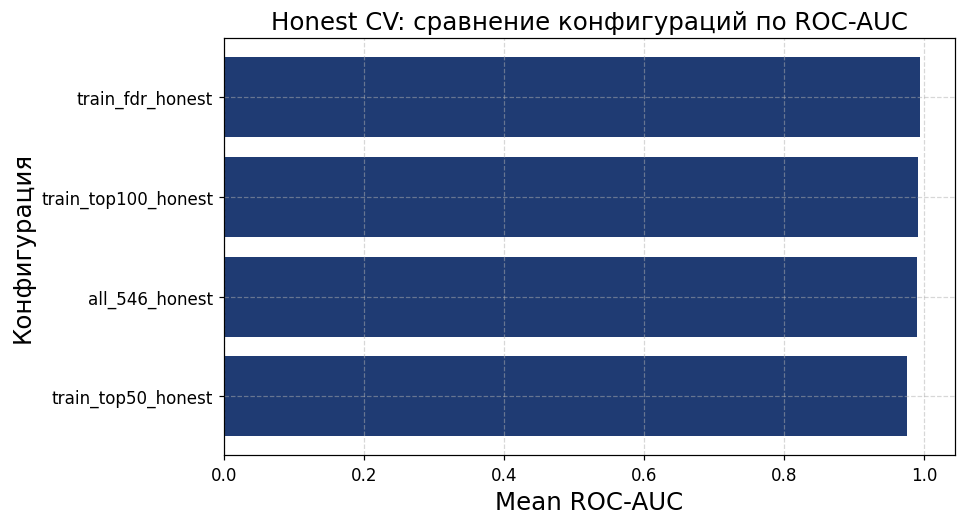

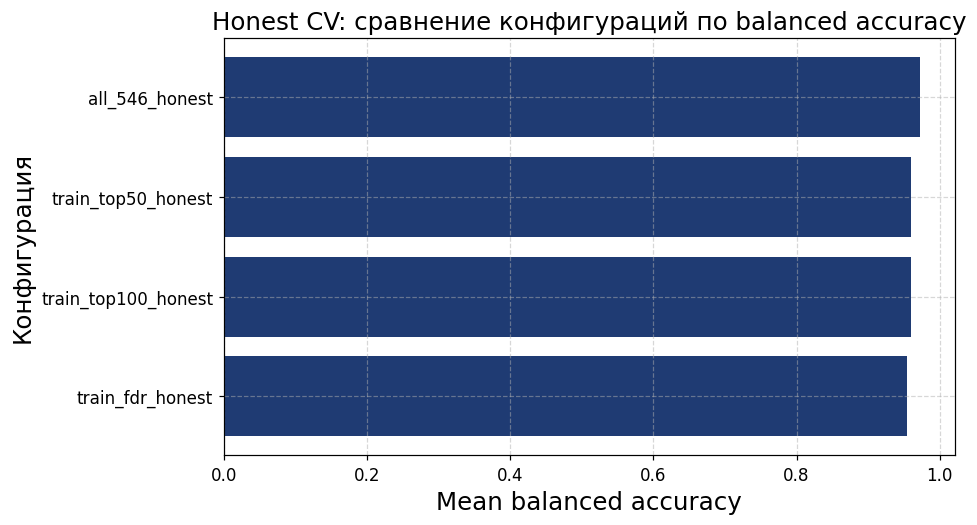

In [31]:
# @title 6.2. Вложенная кросс-валидация: сравнение конфигураций


from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"
RESULTS_PATH = EDA_DIR / "nested_cv_results.csv"

if not RESULTS_PATH.exists():
    RESULTS_PATH = Path("/mnt/data/nested_cv_results.csv")


# =========================================
# 1. Загрузка
# =========================================
res = pd.read_csv(RESULTS_PATH)


# =========================================
# 2. ROC-AUC
# =========================================
tmp = res.sort_values("roc_auc_mean", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(tmp["config"], tmp["roc_auc_mean"])
plt.xlabel("Mean ROC-AUC")
plt.ylabel("Конфигурация")
plt.title("Honest CV: сравнение конфигураций по ROC-AUC")
plt.tight_layout()
plt.show()


# =========================================
# 3. Balanced accuracy
# =========================================
tmp = res.sort_values("balanced_accuracy_mean", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(tmp["config"], tmp["balanced_accuracy_mean"])
plt.xlabel("Mean balanced accuracy")
plt.ylabel("Конфигурация")
plt.title("Honest CV: сравнение конфигураций по balanced accuracy")
plt.tight_layout()
plt.show()

✅ Число train-only FDR признаков по fold


,fold,n_selected_features_fdr
0,1,185
1,2,181
2,3,179
3,4,178
4,5,199


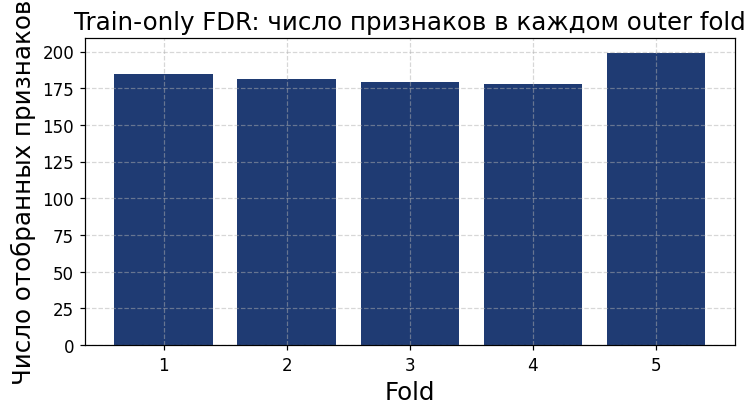

In [32]:
# @title 6.3. Вложенная кросс-валидация: ROC-AUC и число отобранных признаков


from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from sklearn.model_selection import StratifiedKFold


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"

if not SUBJ_PATH.exists():
    SUBJ_PATH = Path("/mnt/data/subject_level_core_clean.csv")


# =========================================
# 1. Загрузка
# =========================================
df = pd.read_csv(SUBJ_PATH)
df["group"] = df["group"].astype(str).str.strip()

y = df["group"].map({"Control": 0, "TBI": 1}).astype(int).values
key_cols = ["group", "subject_id", "n_records_subject"]
X_all = df[[c for c in df.columns if c not in key_cols]].copy()


# =========================================
# 2. Вспомогательные функции
# =========================================
def fdr_bh(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]

    q = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        q[i] = prev

    out = np.empty(n, dtype=float)
    out[order] = np.clip(q, 0, 1)
    return out


def select_features_train_only(X_train, y_train, q_threshold=0.05):
    cols = X_train.columns.tolist()
    grp1 = y_train == 1
    grp0 = y_train == 0

    pvals = []
    valid_cols = []

    for col in cols:
        x1 = pd.to_numeric(X_train.loc[grp1, col], errors="coerce").dropna()
        x0 = pd.to_numeric(X_train.loc[grp0, col], errors="coerce").dropna()

        if len(x1) < 2 or len(x0) < 2:
            continue
        if pd.concat([x1, x0]).nunique() <= 1:
            continue

        try:
            _, p = mannwhitneyu(x1, x0, alternative="two-sided")
        except Exception:
            continue

        valid_cols.append(col)
        pvals.append(p)

    if len(valid_cols) == 0:
        return []

    qvals = fdr_bh(np.array(pvals))
    selected = [c for c, q in zip(valid_cols, qvals) if q < q_threshold]

    if len(selected) == 0:
        order = np.argsort(pvals)
        selected = [valid_cols[i] for i in order[: min(20, len(order))]]

    return selected


# =========================================
# 3. Число признаков по train-fold
# =========================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_rows = []
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_all, y), start=1):
    X_train = X_all.iloc[train_idx].copy()
    y_train = y[train_idx]

    selected = select_features_train_only(X_train, y_train, q_threshold=0.05)

    fold_rows.append({
        "fold": fold_idx,
        "n_selected_features_fdr": len(selected),
    })

fold_df = pd.DataFrame(fold_rows)

print("✅ Число train-only FDR признаков по fold")
display(fold_df)

plt.figure(figsize=(7, 4))
plt.bar(fold_df["fold"].astype(str), fold_df["n_selected_features_fdr"])
plt.xlabel("Fold")
plt.ylabel("Число отобранных признаков")
plt.title("Train-only FDR: число признаков в каждом outer fold")
plt.tight_layout()
plt.show()

## 7. Проверка событийных признаков

Событийные характеристики описывают пространственно-временную организацию кратковременных пароксизмальных событий. В этом блоке проверяются их распределения, устойчивость и возможная связь с числом записей на субъекта.

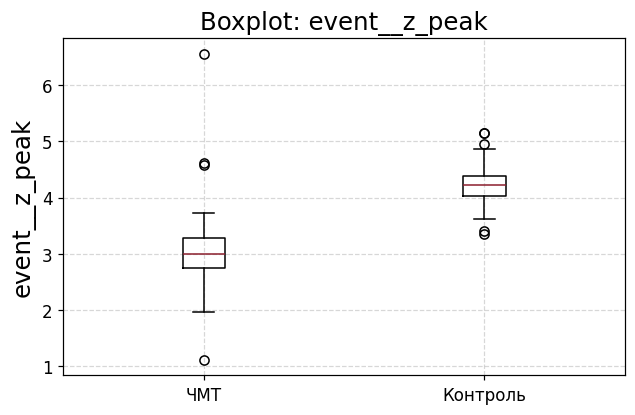

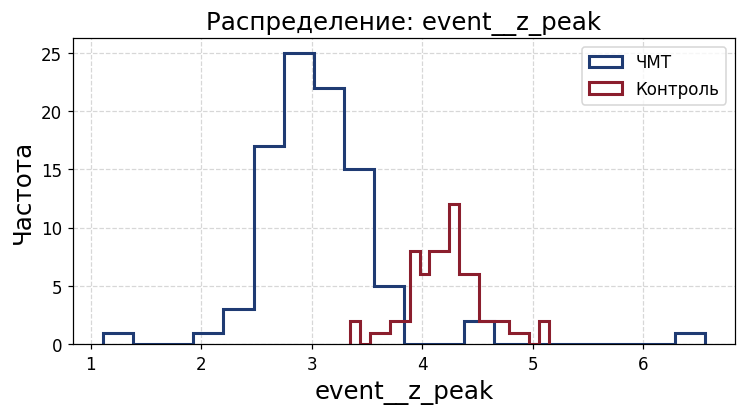

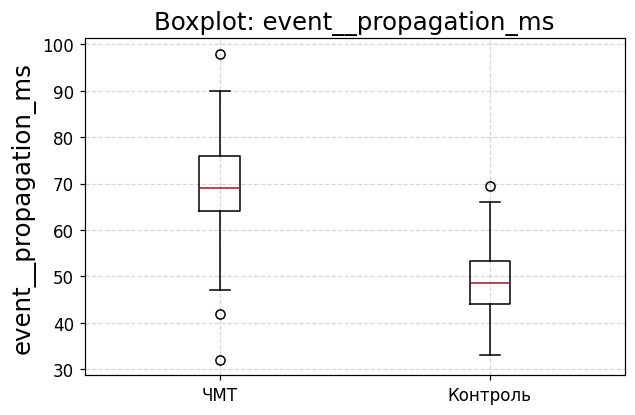

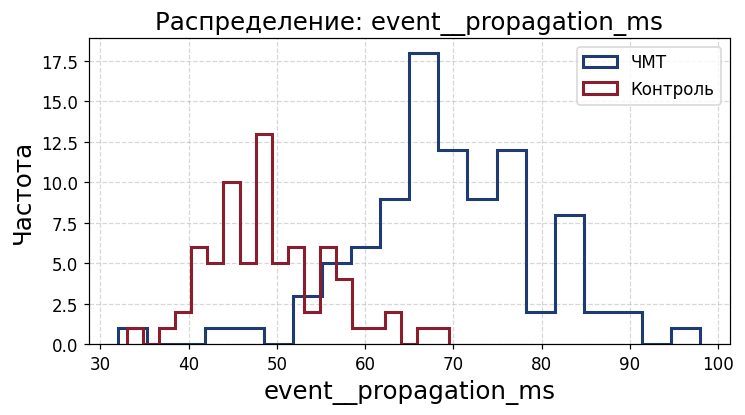

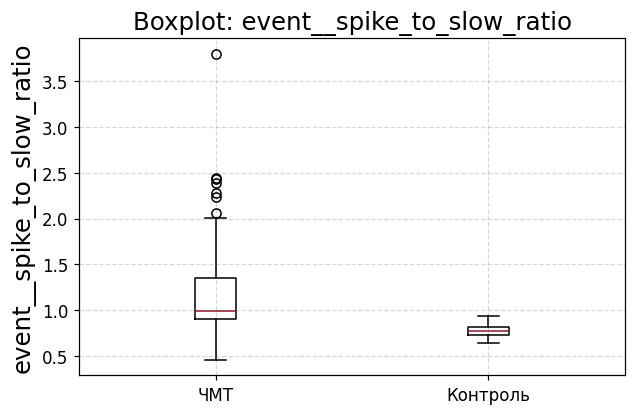

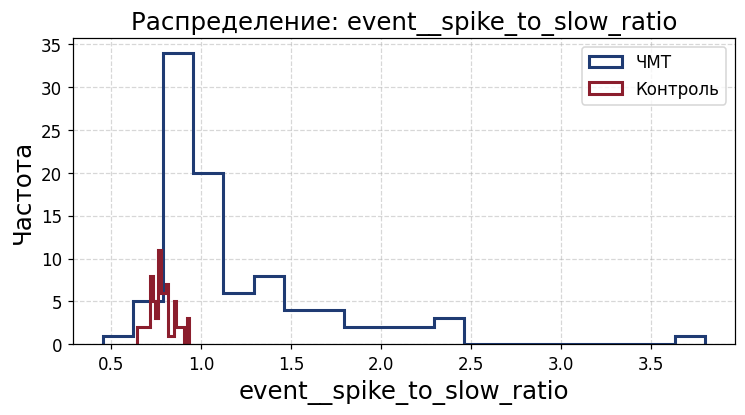

✅ Проверка одиночных event-признаков


,feature,mean_tbi,mean_control,median_tbi,median_control,auc_raw,auc_best_direction
0,event__z_peak,3.052323,4.219268,3.004158,4.216311,0.035024,0.964976
1,event__propagation_ms,69.331522,49.250000,69.000000,48.500000,0.941274,0.941274
2,event__spike_to_slow_ratio,1.195560,0.779795,0.990313,0.772589,0.920290,0.920290


In [33]:
# @title 7.1. Событийные признаки: распределения и ROC-AUC отдельных признаков


from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"
SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"

if not SUBJ_PATH.exists():
    SUBJ_PATH = Path("/mnt/data/subject_level_core_clean.csv")


# =========================================
# 1. Загрузка
# =========================================
df = pd.read_csv(SUBJ_PATH)
df["group"] = df["group"].astype(str).str.strip()
df["y"] = df["group"].map({"Control": 0, "TBI": 1}).astype(int)

event_features = [
    "event__z_peak",
    "event__propagation_ms",
    "event__spike_to_slow_ratio",
]

# знак ROC-AUC для одного признака:
# если AUC < 0.5, переворачиваем направление
rows = []

for feat in event_features:
    s = pd.to_numeric(df[feat], errors="coerce")
    y = df["y"]

    auc_raw = roc_auc_score(y, s)
    auc_best = max(auc_raw, 1 - auc_raw)

    rows.append({
        "feature": feat,
        "mean_tbi": s[df["group"] == "TBI"].mean(),
        "mean_control": s[df["group"] == "Control"].mean(),
        "median_tbi": s[df["group"] == "TBI"].median(),
        "median_control": s[df["group"] == "Control"].median(),
        "auc_raw": auc_raw,
        "auc_best_direction": auc_best,
    })

    # boxplot
    plt.figure(figsize=(6, 4))
    data = [
        s[df["group"] == "TBI"].dropna(),
        s[df["group"] == "Control"].dropna(),
    ]
    plt.boxplot(data, tick_labels=["ЧМТ", "Контроль"])
    plt.ylabel(feat)
    plt.title(f"Boxplot: {feat}")
    plt.tight_layout()
    plt.show()

    # простая гистограмма
    plt.figure(figsize=(7, 4))
    plt.hist(s[df["group"] == "TBI"].dropna(), bins=20, alpha=1, histtype="step", linewidth=2, label="ЧМТ")
    plt.hist(s[df["group"] == "Control"].dropna(), bins=20, alpha=1, histtype="step", linewidth=2, label="Контроль")
    plt.xlabel(feat)
    plt.ylabel("Частота")
    plt.title(f"Распределение: {feat}")
    plt.legend()
    plt.tight_layout()
    plt.show()

summary_df = pd.DataFrame(rows)
print("✅ Проверка одиночных event-признаков")
display(summary_df)

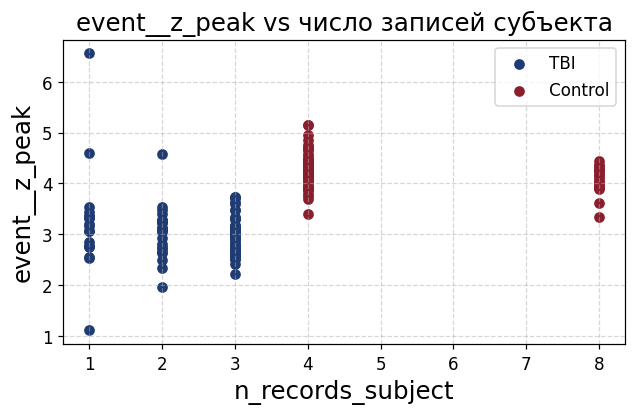

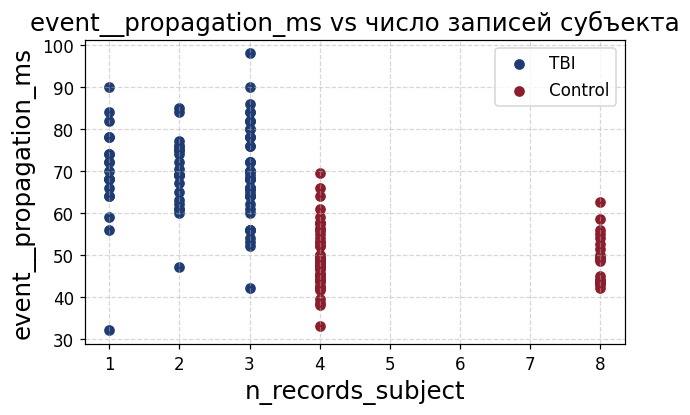

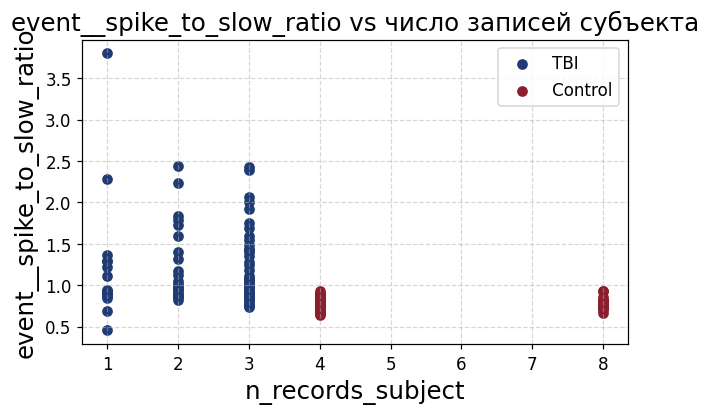

✅ Связь event-признаков с числом записей субъекта


,feature,rho_with_n_records_all,rho_with_n_records_tbi,rho_with_n_records_control
0,event__z_peak,0.653700,-0.138982,-0.258529
1,event__propagation_ms,-0.680971,-0.050097,0.050797
2,event__spike_to_slow_ratio,-0.627690,0.032136,0.078089


In [34]:
# @title 7.2. Событийные признаки: связь с числом записей на субъекта


from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"
SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"

if not SUBJ_PATH.exists():
    SUBJ_PATH = Path("/mnt/data/subject_level_core_clean.csv")


# =========================================
# 1. Загрузка
# =========================================
df = pd.read_csv(SUBJ_PATH)
df["group"] = df["group"].astype(str).str.strip()

event_features = [
    "event__z_peak",
    "event__propagation_ms",
    "event__spike_to_slow_ratio",
]

rows = []

for feat in event_features:
    s = pd.to_numeric(df[feat], errors="coerce")
    nrec = pd.to_numeric(df["n_records_subject"], errors="coerce")

    rho_all = s.corr(nrec, method="spearman")
    rho_tbi = s[df["group"] == "TBI"].corr(nrec[df["group"] == "TBI"], method="spearman")
    rho_ctl = s[df["group"] == "Control"].corr(nrec[df["group"] == "Control"], method="spearman")

    rows.append({
        "feature": feat,
        "rho_with_n_records_all": rho_all,
        "rho_with_n_records_tbi": rho_tbi,
        "rho_with_n_records_control": rho_ctl,
    })

    plt.figure(figsize=(6, 4))
    for grp in ["TBI", "Control"]:
        m = df["group"] == grp
        plt.scatter(
            nrec[m],
            s[m],
            alpha=1,
            label=grp,
        )
    plt.xlabel("n_records_subject")
    plt.ylabel(feat)
    plt.title(f"{feat} vs число записей субъекта")
    plt.legend()
    plt.tight_layout()
    plt.show()

corr_df = pd.DataFrame(rows)
print("✅ Связь event-признаков с числом записей субъекта")
display(corr_df)

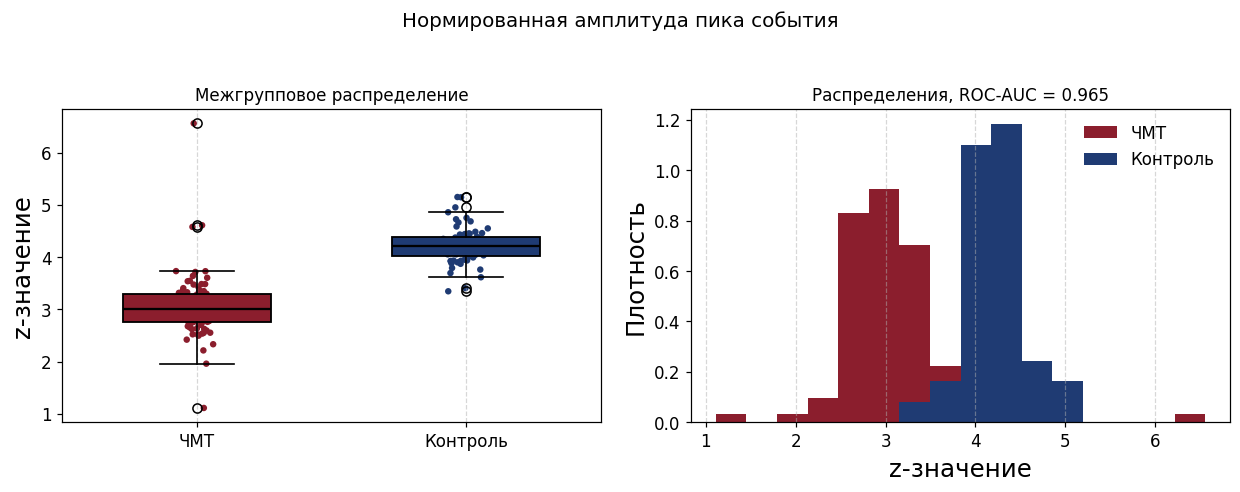

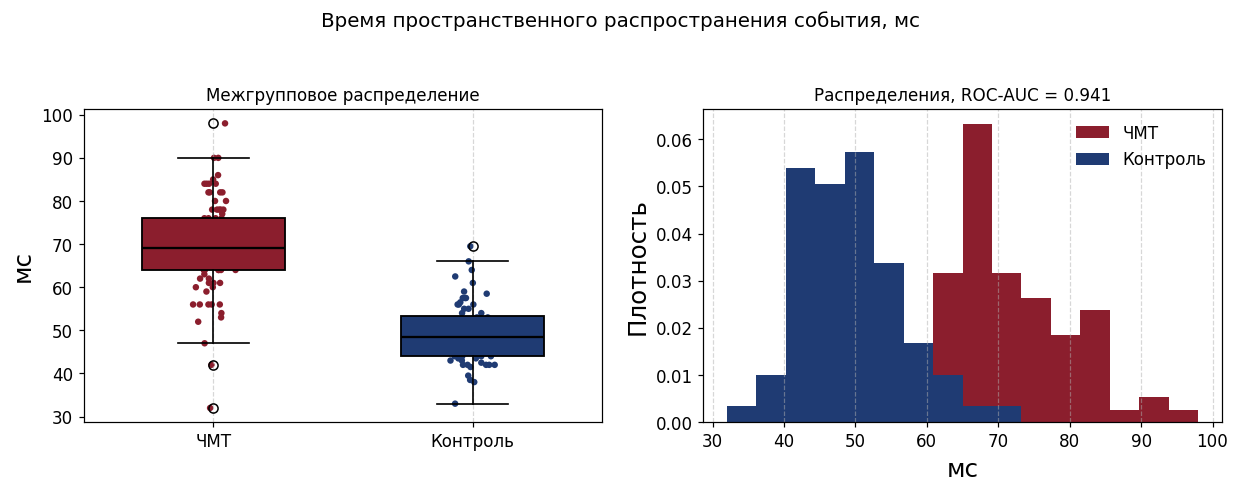

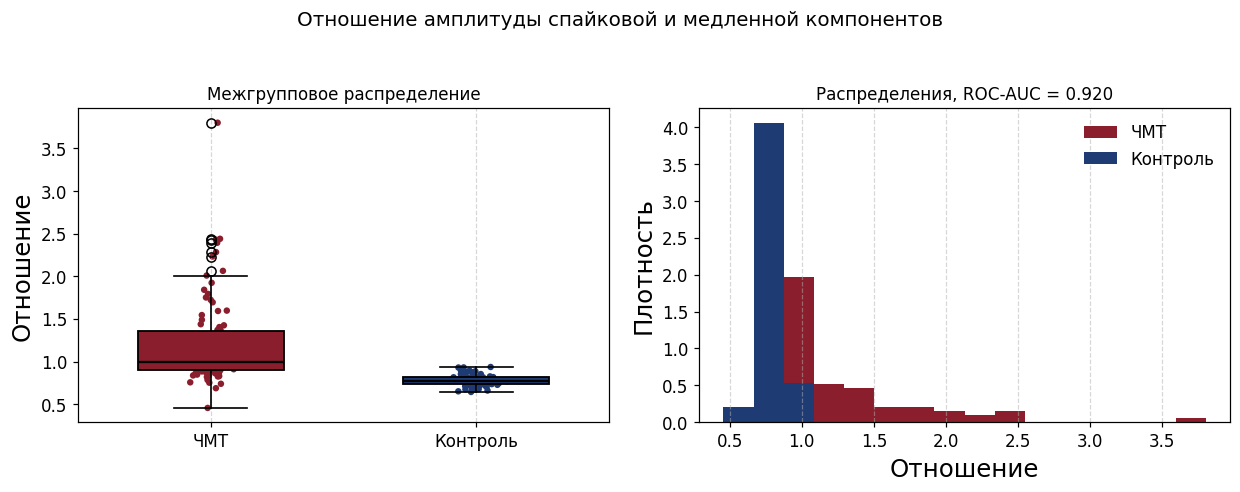

✅ Проверка одиночных event-признаков


,Признак,Полное название,Среднее_ЧМТ,Среднее_контроль,Медиана_ЧМТ,Медиана_контроль,ROC_AUC_исходное,ROC_AUC_лучшее_направление
0,Пик события (z),Нормированная амплитуда пика события,3.052323,4.219268,3.004158,4.216311,0.035024,0.964976
1,"Распространение, мс",Время пространственного распространения событи...,69.331522,49.250000,69.000000,48.500000,0.941274,0.941274
2,Спайк/медленная\nкомпонента,Отношение амплитуды спайковой и медленной комп...,1.195560,0.779795,0.990313,0.772589,0.920290,0.920290


In [35]:
# @title 7.3. Событийные признаки: презентационные распределения

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"
SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"

if not SUBJ_PATH.exists():
    SUBJ_PATH = Path("/mnt/data/subject_level_core_clean.csv")


# =========================================
# 1. Загрузка
# =========================================
df = pd.read_csv(SUBJ_PATH)
df["group"] = df["group"].astype(str).str.strip()
df["y"] = df["group"].map({"Control": 0, "TBI": 1}).astype(int)

event_features = [
    "event__z_peak",
    "event__propagation_ms",
    "event__spike_to_slow_ratio",
]

feature_name_ru = {
    "event__z_peak": "Нормированная амплитуда пика события",
    "event__propagation_ms": "Время пространственного распространения события, мс",
    "event__spike_to_slow_ratio": "Отношение амплитуды спайковой и медленной компонентов",
}

feature_short_ru = {
    "event__z_peak": "Пик события (z)",
    "event__propagation_ms": "Распространение, мс",
    "event__spike_to_slow_ratio": "Спайк/медленная\nкомпонента",
}

y_axis_label = {
    "event__z_peak": "z-значение",
    "event__propagation_ms": "мс",
    "event__spike_to_slow_ratio": "Отношение",
}


# =========================================
# 2. Цвета
# =========================================
COLOR_TBI = "#8B1E2D"
COLOR_CONTROL = "#1F3B73"


# =========================================
# 3. Вспомогательная функция
# =========================================
def safe_auc(y_true, scores):
    m = pd.notna(scores)
    y_true = pd.Series(y_true)[m]
    scores = pd.Series(scores)[m]
    auc_raw = roc_auc_score(y_true, scores)
    auc_best = max(auc_raw, 1 - auc_raw)
    return auc_raw, auc_best


# =========================================
# 4. Анализ и графики
# =========================================
rows = []

for feat in event_features:
    s = pd.to_numeric(df[feat], errors="coerce")
    y = df["y"]

    tbi = s[df["group"] == "TBI"].dropna()
    ctl = s[df["group"] == "Control"].dropna()

    auc_raw, auc_best = safe_auc(y, s)

    rows.append({
        "Признак": feature_short_ru.get(feat, feat),
        "Полное название": feature_name_ru.get(feat, feat),
        "Среднее_ЧМТ": tbi.mean(),
        "Среднее_контроль": ctl.mean(),
        "Медиана_ЧМТ": tbi.median(),
        "Медиана_контроль": ctl.median(),
        "ROC_AUC_исходное": auc_raw,
        "ROC_AUC_лучшее_направление": auc_best,
    })

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

    # ===== boxplot + точки =====
    ax = axes[0]

    box = ax.boxplot(
        [tbi, ctl],
        tick_labels=["ЧМТ", "Контроль"],
        patch_artist=True,
        widths=0.55,
        medianprops=dict(color="black", linewidth=1.5),
        boxprops=dict(linewidth=1.2),
        whiskerprops=dict(linewidth=1.1),
        capprops=dict(linewidth=1.1),
    )

    box["boxes"][0].set_facecolor(COLOR_TBI)
    box["boxes"][0].set_alpha(1)
    box["boxes"][1].set_facecolor(COLOR_CONTROL)
    box["boxes"][1].set_alpha(1)

    rng = np.random.default_rng(42)
    x1 = rng.normal(1, 0.04, size=len(tbi))
    x2 = rng.normal(2, 0.04, size=len(ctl))

    ax.scatter(x1, tbi, s=18, alpha=1, color=COLOR_TBI, edgecolors="none")
    ax.scatter(x2, ctl, s=18, alpha=1, color=COLOR_CONTROL, edgecolors="none")

    ax.set_ylabel(y_axis_label.get(feat, "Значение"))
    ax.set_title("Межгрупповое распределение", fontsize=11)
    ax.grid(axis="y")

    # ===== наложенные гистограммы =====
    ax = axes[1]

    all_vals = pd.concat([tbi, ctl], axis=0)
    bins = np.histogram_bin_edges(all_vals, bins=16)

    ax.hist(
        tbi,
        bins=bins,
        alpha=1,
        label="ЧМТ",
        color=COLOR_TBI,
        density=True,
    )
    ax.hist(
        ctl,
        bins=bins,
        alpha=1,
        label="Контроль",
        color=COLOR_CONTROL,
        density=True,
    )

    ax.set_xlabel(y_axis_label.get(feat, feature_short_ru.get(feat, feat)))
    ax.set_ylabel("Плотность")
    ax.set_title(f"Распределения, ROC-AUC = {auc_best:.3f}", fontsize=11)
    ax.legend(frameon=False)
    ax.grid(axis="y")

    fig.suptitle(
        feature_name_ru.get(feat, feat),
        fontsize=13,
        y=1.02
    )

    plt.tight_layout()
    plt.show()


# =========================================
# 5. Сводная таблица
# =========================================
summary_df = pd.DataFrame(rows)
summary_df = summary_df.sort_values("ROC_AUC_лучшее_направление", ascending=False).reset_index(drop=True)

print("✅ Проверка одиночных event-признаков")
display(summary_df)

In [36]:
# @title 7.4. Событийные признаки: residual-анализ после учёта числа записей


from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score
from scipy.stats import mannwhitneyu


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"
SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"

if not SUBJ_PATH.exists():
    SUBJ_PATH = Path("/mnt/data/subject_level_core_clean.csv")


# =========================================
# 1. Загрузка
# =========================================
df = pd.read_csv(SUBJ_PATH)
df["group"] = df["group"].astype(str).str.strip()
df["y"] = df["group"].map({"Control": 0, "TBI": 1}).astype(int)

event_features = [
    "event__z_peak",
    "event__propagation_ms",
    "event__spike_to_slow_ratio",
]

rows = []

for feat in event_features:
    tmp = df[["group", "y", "n_records_subject", feat]].copy()
    tmp[feat] = pd.to_numeric(tmp[feat], errors="coerce")
    tmp["n_records_subject"] = pd.to_numeric(tmp["n_records_subject"], errors="coerce")
    tmp = tmp.dropna().reset_index(drop=True)

    X_cov = tmp[["n_records_subject"]].values
    y_feat = tmp[feat].values

    reg = LinearRegression()
    reg.fit(X_cov, y_feat)
    pred = reg.predict(X_cov)
    resid = y_feat - pred

    tbi = resid[tmp["group"] == "TBI"]
    ctl = resid[tmp["group"] == "Control"]

    _, p = mannwhitneyu(tbi, ctl, alternative="two-sided")

    auc_raw = roc_auc_score(tmp["y"], resid)
    auc_best = max(auc_raw, 1 - auc_raw)

    rows.append({
        "feature": feat,
        "beta_n_records": float(reg.coef_[0]),
        "intercept": float(reg.intercept_),
        "resid_mean_tbi": tbi.mean(),
        "resid_mean_control": ctl.mean(),
        "resid_auc_best_direction": auc_best,
        "mannwhitney_p_on_residuals": p,
    })

resid_df = pd.DataFrame(rows)
print("✅ Residual-проверка после учёта n_records_subject")
display(resid_df)

✅ Residual-проверка после учёта n_records_subject


,feature,beta_n_records,intercept,resid_mean_tbi,resid_mean_control,resid_auc_best_direction,mannwhitney_p_on_residuals
0,event__z_peak,0.190132,2.893382,-0.285389,0.364664,0.828804,5.386608e-13
1,event__propagation_ms,-3.770914,73.828410,4.315574,-5.514345,0.763738,7.158215e-09
2,event__spike_to_slow_ratio,-0.079043,1.292089,0.088191,-0.112688,0.592240,4.308358e-02


✅ Корреляции ключевых event-признаков с остальными event-признаками


,feature,other_event_feature,spearman_rho,abs_rho
0,event__propagation_ms,event__spike_to_slow_ratio,0.819978,0.819978
1,event__propagation_ms,event__z_peak,-0.808862,0.808862
2,event__propagation_ms,event__n_involved_ch,0.672642,0.672642
3,event__propagation_ms,event__line_length_uv,0.592341,0.592341
4,event__propagation_ms,event__slow_peak_uv,0.551644,0.551644
5,event__propagation_ms,event__peak_to_peak_uv,0.530593,0.530593
6,event__propagation_ms,event__spread_rois,0.464000,0.464000
7,event__propagation_ms,event__auc_abs_uvs,0.406555,0.406555
8,event__propagation_ms,event__slope_fall_uvs,-0.394651,0.394651
9,event__propagation_ms,event__slope_rise_uvs,0.376083,0.376083


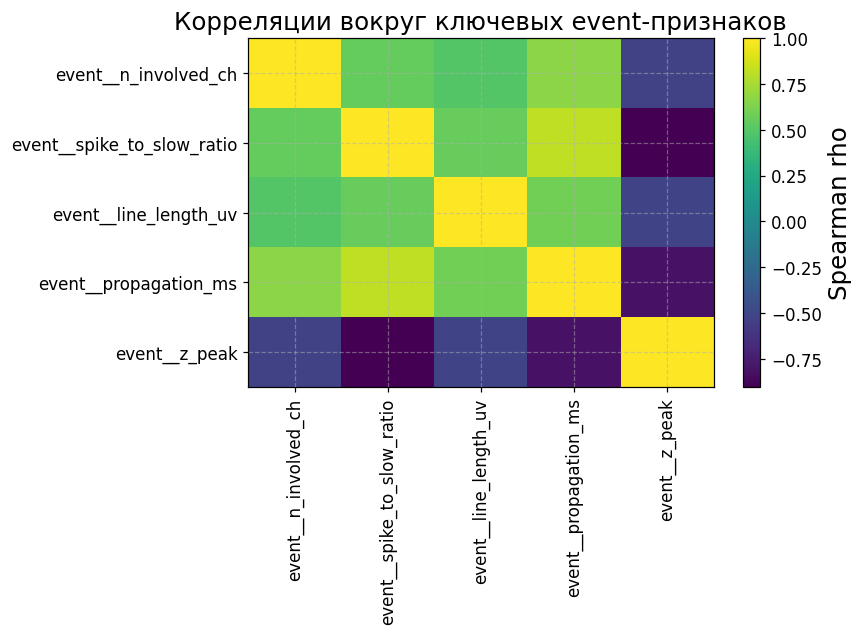

In [37]:
# @title 7.5. Событийные признаки: корреляционная структура


from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"
SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"

if not SUBJ_PATH.exists():
    SUBJ_PATH = Path("/mnt/data/subject_level_core_clean.csv")


# =========================================
# 1. Загрузка
# =========================================
df = pd.read_csv(SUBJ_PATH)

event_cols = [c for c in df.columns if c.startswith("event__")]

focus = [
    "event__z_peak",
    "event__propagation_ms",
    "event__spike_to_slow_ratio",
]

corr_rows = []
for feat in focus:
    s = pd.to_numeric(df[feat], errors="coerce")
    for other in event_cols:
        if other == feat:
            continue
        rho = s.corr(pd.to_numeric(df[other], errors="coerce"), method="spearman")
        corr_rows.append({
            "feature": feat,
            "other_event_feature": other,
            "spearman_rho": rho,
            "abs_rho": abs(rho) if pd.notna(rho) else None,
        })

corr_df = pd.DataFrame(corr_rows).sort_values(["feature", "abs_rho"], ascending=[True, False])
print("✅ Корреляции ключевых event-признаков с остальными event-признаками")
display(corr_df.groupby("feature").head(10).reset_index(drop=True))

# небольшая heatmap только для фокусных + топ связанных
top_related = set(focus)
for feat in focus:
    top_related.update(
        corr_df[corr_df["feature"] == feat]
        .head(3)["other_event_feature"]
        .tolist()
    )

top_related = [c for c in top_related if c in df.columns]
mat = df[top_related].apply(pd.to_numeric, errors="coerce").corr(method="spearman")

plt.figure(figsize=(8, 6))
plt.imshow(mat, aspect="auto")
plt.xticks(range(len(mat.columns)), mat.columns, rotation=90)
plt.yticks(range(len(mat.index)), mat.index)
plt.colorbar(label="Spearman rho")
plt.title("Корреляции вокруг ключевых event-признаков")
plt.tight_layout()
plt.show()

## 8. Интерпретация признаков и устойчивость модели

Здесь оценивается, какие признаки стабильно выбираются в честной CV и какие направления коэффициентов сохраняются между фолдами.

In [38]:
# @title 8.1. Интерпретация модели: стабильность отбора признаков и коэффициентов


from pathlib import Path
import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"

if not SUBJ_PATH.exists():
    SUBJ_PATH = Path("/mnt/data/subject_level_core_clean.csv")

OUT_FEATURE_STABILITY = EDA_DIR / "model_feature_stability_honest_cv.csv"
OUT_FOLD_DETAILS = EDA_DIR / "model_feature_stability_honest_cv_fold_details.csv"
OUT_BLOCK_STABILITY = EDA_DIR / "model_block_stability_honest_cv.csv"


# =========================================
# 1. Загрузка
# =========================================
df = pd.read_csv(SUBJ_PATH)
df["group"] = df["group"].astype(str).str.strip()
df["subject_id"] = df["subject_id"].astype(str).str.strip()

y = df["group"].map({"Control": 0, "TBI": 1}).astype(int).values

key_cols = ["group", "subject_id", "n_records_subject"]
feature_cols = [c for c in df.columns if c not in key_cols]
X_all = df[feature_cols].copy()


# =========================================
# 2. Вспомогательные функции
# =========================================
def get_block(col):
    if "__" in col:
        return col.split("__")[0]
    return "other"


def fdr_bh(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]

    q = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        q[i] = prev

    out = np.empty(n, dtype=float)
    out[order] = np.clip(q, 0, 1)
    return out


def select_features_train_only_fdr(X_train, y_train, q_threshold=0.05):
    cols = X_train.columns.tolist()
    grp1 = y_train == 1
    grp0 = y_train == 0

    pvals = []
    valid_cols = []

    for col in cols:
        x1 = pd.to_numeric(X_train.loc[grp1, col], errors="coerce").dropna()
        x0 = pd.to_numeric(X_train.loc[grp0, col], errors="coerce").dropna()

        if len(x1) < 2 or len(x0) < 2:
            continue
        if pd.concat([x1, x0]).nunique() <= 1:
            continue

        try:
            _, p = mannwhitneyu(x1, x0, alternative="two-sided")
        except Exception:
            continue

        valid_cols.append(col)
        pvals.append(p)

    if len(valid_cols) == 0:
        return []

    qvals = fdr_bh(np.array(pvals))
    selected = [c for c, q in zip(valid_cols, qvals) if q < q_threshold]

    if len(selected) == 0:
        order = np.argsort(pvals)
        selected = [valid_cols[i] for i in order[: min(20, len(order))]]

    return selected


def build_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            max_iter=5000,
            class_weight="balanced",
            random_state=42,
        )),
    ])


# =========================================
# 3. Honest CV с сохранением selected features и coefficients
# =========================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

selected_rows = []
coef_rows = []

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_all, y), start=1):
    X_train = X_all.iloc[train_idx].copy()
    y_train = y[train_idx]

    selected_features = select_features_train_only_fdr(
        X_train,
        y_train,
        q_threshold=0.05,
    )

    X_train_sel = X_train[selected_features].copy()

    pipe = build_pipeline()
    pipe.fit(X_train_sel, y_train)

    coefs = pipe.named_steps["clf"].coef_.ravel()

    for feat in selected_features:
        selected_rows.append({
            "fold": fold_idx,
            "feature": feat,
            "block": get_block(feat),
            "selected": 1,
        })

    for feat, coef in zip(selected_features, coefs):
        coef_rows.append({
            "fold": fold_idx,
            "feature": feat,
            "block": get_block(feat),
            "coef": float(coef),
            "coef_abs": abs(float(coef)),
            "coef_sign": "positive_for_TBI" if coef > 0 else "negative_for_TBI",
        })


selected_df = pd.DataFrame(selected_rows)
coef_df = pd.DataFrame(coef_rows)

fold_details_df = coef_df.copy()
fold_details_df.to_csv(OUT_FOLD_DETAILS, index=False, encoding="utf-8")


# =========================================
# 4. Итоговая стабильность признаков
# =========================================
n_folds = cv.get_n_splits()

sel_count = (
    selected_df.groupby(["feature", "block"], as_index=False)
    .agg(
        n_selected_folds=("selected", "sum"),
    )
)

coef_summary = (
    coef_df.groupby(["feature", "block"], as_index=False)
    .agg(
        mean_coef=("coef", "mean"),
        median_coef=("coef", "median"),
        mean_abs_coef=("coef_abs", "mean"),
        median_abs_coef=("coef_abs", "median"),
        std_coef=("coef", "std"),
        n_positive_for_TBI=("coef", lambda s: int((s > 0).sum())),
        n_negative_for_TBI=("coef", lambda s: int((s < 0).sum())),
    )
)

feature_stability = sel_count.merge(
    coef_summary,
    on=["feature", "block"],
    how="left"
)

feature_stability["selection_frequency"] = feature_stability["n_selected_folds"] / n_folds
feature_stability["stable_sign"] = np.where(
    feature_stability["n_positive_for_TBI"] == feature_stability["n_selected_folds"],
    "stable_positive_for_TBI",
    np.where(
        feature_stability["n_negative_for_TBI"] == feature_stability["n_selected_folds"],
        "stable_negative_for_TBI",
        "mixed_sign",
    )
)

feature_stability = feature_stability.sort_values(
    ["selection_frequency", "mean_abs_coef"],
    ascending=[False, False]
).reset_index(drop=True)

feature_stability.to_csv(OUT_FEATURE_STABILITY, index=False, encoding="utf-8")


# =========================================
# 5. Сводка по блокам
# =========================================
block_stability = (
    feature_stability.groupby("block", as_index=False)
    .agg(
        n_unique_selected_features=("feature", "count"),
        mean_selection_frequency=("selection_frequency", "mean"),
        median_selection_frequency=("selection_frequency", "median"),
        mean_abs_coef=("mean_abs_coef", "mean"),
        median_abs_coef=("mean_abs_coef", "median"),
        n_features_selected_all_folds=("n_selected_folds", lambda s: int((s == n_folds).sum())),
    )
    .sort_values(
        ["n_features_selected_all_folds", "mean_abs_coef"],
        ascending=[False, False]
    )
)

block_stability.to_csv(OUT_BLOCK_STABILITY, index=False, encoding="utf-8")


# =========================================
# 6. Вывод
# =========================================
print("✅ Стабильность признаков и коэффициентов рассчитана")
print("Признаки:", OUT_FEATURE_STABILITY)
print("Детали по fold:", OUT_FOLD_DETAILS)
print("Блоки:", OUT_BLOCK_STABILITY)

print("\n=== TOP STABLE FEATURES (selected in all folds) ===")
display(
    feature_stability[feature_stability["n_selected_folds"] == n_folds]
    .head(30)
)

print("\n=== TOP FEATURES BY SELECTION FREQUENCY AND |COEF| ===")
display(
    feature_stability.head(30)
)

print("\n=== BLOCK STABILITY SUMMARY ===")
display(block_stability)

✅ Стабильность признаков и коэффициентов рассчитана
Признаки: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/model_feature_stability_honest_cv.csv
Детали по fold: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/model_feature_stability_honest_cv_fold_details.csv
Блоки: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/model_block_stability_honest_cv.csv

=== TOP STABLE FEATURES (selected in all folds) ===


,feature,block,n_selected_folds,mean_coef,median_coef,mean_abs_coef,median_abs_coef,std_coef,n_positive_for_TBI,n_negative_for_TBI,selection_frequency,stable_sign
0,event__z_peak,event,5,-0.755145,-0.727343,0.755145,0.727343,0.041958,0,5,1.0,stable_negative_for_TBI
1,event__propagation_ms,event,5,0.587952,0.591886,0.587952,0.591886,0.050528,5,0,1.0,stable_positive_for_TBI
2,conn__asymmetry__dtf_beta,conn,5,-0.373852,-0.353180,0.373852,0.353180,0.043883,0,5,1.0,stable_negative_for_TBI
3,burst__median_ibi_sec__temporal_alpha,burst,5,-0.370607,-0.389507,0.370607,0.389507,0.062406,0,5,1.0,stable_negative_for_TBI
4,conn__hub_z_max__plv_beta,conn,5,-0.314798,-0.311298,0.314798,0.311298,0.026397,0,5,1.0,stable_negative_for_TBI
5,conn__small_worldness__pdc_delta,conn,5,0.299017,0.285150,0.299017,0.285150,0.040293,5,0,1.0,stable_positive_for_TBI
6,conn__global_efficiency__plv_theta,conn,5,-0.295845,-0.300555,0.295845,0.300555,0.063127,0,5,1.0,stable_negative_for_TBI
7,conn__asymmetry__dtf_gamma,conn,5,-0.286266,-0.267095,0.286266,0.267095,0.052071,0,5,1.0,stable_negative_for_TBI
8,event__n_involved_ch,event,5,0.278689,0.296430,0.278689,0.296430,0.038462,5,0,1.0,stable_positive_for_TBI
9,conn__clustering__pdc_beta,conn,5,0.277559,0.272873,0.277559,0.272873,0.084818,5,0,1.0,stable_positive_for_TBI



=== TOP FEATURES BY SELECTION FREQUENCY AND |COEF| ===


,feature,block,n_selected_folds,mean_coef,median_coef,mean_abs_coef,median_abs_coef,std_coef,n_positive_for_TBI,n_negative_for_TBI,selection_frequency,stable_sign
0,event__z_peak,event,5,-0.755145,-0.727343,0.755145,0.727343,0.041958,0,5,1.0,stable_negative_for_TBI
1,event__propagation_ms,event,5,0.587952,0.591886,0.587952,0.591886,0.050528,5,0,1.0,stable_positive_for_TBI
2,conn__asymmetry__dtf_beta,conn,5,-0.373852,-0.353180,0.373852,0.353180,0.043883,0,5,1.0,stable_negative_for_TBI
3,burst__median_ibi_sec__temporal_alpha,burst,5,-0.370607,-0.389507,0.370607,0.389507,0.062406,0,5,1.0,stable_negative_for_TBI
4,conn__hub_z_max__plv_beta,conn,5,-0.314798,-0.311298,0.314798,0.311298,0.026397,0,5,1.0,stable_negative_for_TBI
5,conn__small_worldness__pdc_delta,conn,5,0.299017,0.285150,0.299017,0.285150,0.040293,5,0,1.0,stable_positive_for_TBI
6,conn__global_efficiency__plv_theta,conn,5,-0.295845,-0.300555,0.295845,0.300555,0.063127,0,5,1.0,stable_negative_for_TBI
7,conn__asymmetry__dtf_gamma,conn,5,-0.286266,-0.267095,0.286266,0.267095,0.052071,0,5,1.0,stable_negative_for_TBI
8,event__n_involved_ch,event,5,0.278689,0.296430,0.278689,0.296430,0.038462,5,0,1.0,stable_positive_for_TBI
9,conn__clustering__pdc_beta,conn,5,0.277559,0.272873,0.277559,0.272873,0.084818,5,0,1.0,stable_positive_for_TBI



=== BLOCK STABILITY SUMMARY ===


,block,n_unique_selected_features,mean_selection_frequency,median_selection_frequency,mean_abs_coef,median_abs_coef,n_features_selected_all_folds
3,conn,85,0.788235,1.0,0.133429,0.129261,51
2,burst,57,0.821053,1.0,0.086327,0.065628,36
1,aper,17,0.941176,1.0,0.076652,0.077839,15
5,event,13,1.000000,1.0,0.208680,0.105987,13
7,spec_shape,15,0.906667,1.0,0.079739,0.071035,12
4,dfa,7,0.942857,1.0,0.096908,0.101644,6
0,alpha_peak,13,0.615385,0.8,0.052228,0.042320,5
6,gamma,6,0.800000,1.0,0.105773,0.096953,4
8,tfr,17,0.505882,0.4,0.090673,0.068445,4


In [39]:
# @title 8.2. Интерпретация модели: компактные таблицы для ВКР


from pathlib import Path
import pandas as pd


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

STAB_PATH = EDA_DIR / "model_feature_stability_honest_cv.csv"

if not STAB_PATH.exists():
    STAB_PATH = Path("/mnt/data/model_feature_stability_honest_cv.csv")

OUT_TOP20 = EDA_DIR / "table_top20_stable_model_features.csv"
OUT_TOP_EVENT = EDA_DIR / "table_top_event_model_features.csv"


# =========================================
# 1. Загрузка
# =========================================
stab = pd.read_csv(STAB_PATH)


# =========================================
# 2. Компактные обозначения
# =========================================
block_map = {
    "event": "Событийные",
    "aper": "Апериодические",
    "spec_shape": "Форма спектра",
    "conn": "Связность",
    "bp": "Спектральная мощность",
    "idx": "Спектральные индексы",
    "burst": "Бурст-динамика",
    "dfa": "DFA / LRTC",
    "gamma": "Гамма-активность",
    "alpha_peak": "Альфа-пик",
    "tfr": "Временно-частотные",
}

feat_map = {
    "event__z_peak": "Нормированная амплитуда пика события",
    "event__propagation_ms": "Время распространения события, мс",
    "event__spike_to_slow_ratio": "Отношение spike/slow-компонент",
    "event__n_involved_ch": "Число вовлечённых каналов события",
    "conn__clustering__plv_theta": "Коэффициент кластеризации PLV в тета-диапазоне",
    "aper__aperiodic_intercept_log10__parietal": "Aperiodic intercept, теменная область",
    "aper__aperiodic_intercept_log10__frontal": "Aperiodic intercept, лобная область",
    "aper__aperiodic_intercept_log10__temporal": "Aperiodic intercept, височная область",
    "aper__aperiodic_intercept_log10__central": "Aperiodic intercept, центральная область",
    "spec_shape__spectral_entropy_norm__central": "Нормированная спектральная энтропия, центральная область",
    "spec_shape__spectral_entropy_raw__central": "Спектральная энтропия, центральная область",
}

sign_map = {
    "stable_positive_for_TBI": "↑ вклад в ЧМТ",
    "stable_negative_for_TBI": "↓ вклад в ЧМТ",
    "mixed_sign": "смешанный знак",
}


# =========================================
# 3. Top stable all-fold features
# =========================================
top20 = (
    stab.sort_values(["selection_frequency", "mean_abs_coef"], ascending=[False, False])
    .head(20)
    .copy()
)

top20["Блок"] = top20["block"].map(lambda x: block_map.get(x, x))
top20["Признак"] = top20["feature"].map(lambda x: feat_map.get(x, x))
top20["Частота отбора"] = top20["selection_frequency"].round(2)
top20["Средний |коэффициент|"] = top20["mean_abs_coef"].round(3)
top20["Средний коэффициент"] = top20["mean_coef"].round(3)
top20["Знак эффекта"] = top20["stable_sign"].map(lambda x: sign_map.get(x, x))

table_top20 = top20[
    ["Признак", "Блок", "n_selected_folds", "Частота отбора", "Средний коэффициент", "Средний |коэффициент|", "Знак эффекта"]
].rename(columns={"n_selected_folds": "Число fold"})

table_top20.to_csv(OUT_TOP20, index=False, encoding="utf-8")


# =========================================
# 4. Top event stable features
# =========================================
top_event = (
    stab[stab["block"] == "event"]
    .sort_values(["selection_frequency", "mean_abs_coef"], ascending=[False, False])
    .copy()
)

top_event["Блок"] = "Событийные"
top_event["Признак"] = top_event["feature"].map(lambda x: feat_map.get(x, x))
top_event["Частота отбора"] = top_event["selection_frequency"].round(2)
top_event["Средний |коэффициент|"] = top_event["mean_abs_coef"].round(3)
top_event["Средний коэффициент"] = top_event["mean_coef"].round(3)
top_event["Знак эффекта"] = top_event["stable_sign"].map(lambda x: sign_map.get(x, x))

table_top_event = top_event[
    ["Признак", "Блок", "n_selected_folds", "Частота отбора", "Средний коэффициент", "Средний |коэффициент|", "Знак эффекта"]
].rename(columns={"n_selected_folds": "Число fold"})

table_top_event.to_csv(OUT_TOP_EVENT, index=False, encoding="utf-8")


# =========================================
# 5. Вывод
# =========================================
print("✅ Компактные таблицы для ВКР сохранены")
print("Top-20:", OUT_TOP20)
print("Event-only:", OUT_TOP_EVENT)

print("\n=== TOP-20 STABLE MODEL FEATURES ===")
display(table_top20)

print("\n=== EVENT FEATURES IN MODEL ===")
display(table_top_event)

✅ Компактные таблицы для ВКР сохранены
Top-20: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/table_top20_stable_model_features.csv
Event-only: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/table_top_event_model_features.csv

=== TOP-20 STABLE MODEL FEATURES ===


,Признак,Блок,Число fold,Частота отбора,Средний коэффициент,Средний |коэффициент|,Знак эффекта
0,Нормированная амплитуда пика события,Событийные,5,1.0,-0.755,0.755,↓ вклад в ЧМТ
1,"Время распространения события, мс",Событийные,5,1.0,0.588,0.588,↑ вклад в ЧМТ
2,conn__asymmetry__dtf_beta,Связность,5,1.0,-0.374,0.374,↓ вклад в ЧМТ
3,burst__median_ibi_sec__temporal_alpha,Бурст-динамика,5,1.0,-0.371,0.371,↓ вклад в ЧМТ
4,conn__hub_z_max__plv_beta,Связность,5,1.0,-0.315,0.315,↓ вклад в ЧМТ
5,conn__small_worldness__pdc_delta,Связность,5,1.0,0.299,0.299,↑ вклад в ЧМТ
6,conn__global_efficiency__plv_theta,Связность,5,1.0,-0.296,0.296,↓ вклад в ЧМТ
7,conn__asymmetry__dtf_gamma,Связность,5,1.0,-0.286,0.286,↓ вклад в ЧМТ
8,Число вовлечённых каналов события,Событийные,5,1.0,0.279,0.279,↑ вклад в ЧМТ
9,conn__clustering__pdc_beta,Связность,5,1.0,0.278,0.278,↑ вклад в ЧМТ



=== EVENT FEATURES IN MODEL ===


,Признак,Блок,Число fold,Частота отбора,Средний коэффициент,Средний |коэффициент|,Знак эффекта
0,Нормированная амплитуда пика события,Событийные,5,1.0,-0.755,0.755,↓ вклад в ЧМТ
1,"Время распространения события, мс",Событийные,5,1.0,0.588,0.588,↑ вклад в ЧМТ
8,Число вовлечённых каналов события,Событийные,5,1.0,0.279,0.279,↑ вклад в ЧМТ
12,Отношение spike/slow-компонент,Событийные,5,1.0,0.254,0.254,↑ вклад в ЧМТ
48,event__sharpness_uv,Событийные,5,1.0,0.132,0.132,↑ вклад в ЧМТ
61,event__slow_peak_uv,Событийные,5,1.0,0.115,0.115,↑ вклад в ЧМТ
68,event__slope_rise_uvs,Событийные,5,1.0,0.106,0.106,↑ вклад в ЧМТ
70,event__spread_rois,Событийные,5,1.0,0.100,0.100,↑ вклад в ЧМТ
73,event__slope_fall_uvs,Событийные,5,1.0,-0.094,0.094,↓ вклад в ЧМТ
77,event__peak_to_peak_uv,Событийные,5,1.0,0.092,0.092,↑ вклад в ЧМТ


## 9. Сравнение групп признаков

Блочное сравнение показывает вклад разных уровней описания ЭЭГ: спектральных, апериодических, временных, сетевых, событийных и мета-признаков.

In [40]:
# @title 9.1. Блочное сравнение моделей: честная CV по группам признаков


from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, f1_score, accuracy_score


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"

if not SUBJ_PATH.exists():
    SUBJ_PATH = Path("/mnt/data/subject_level_core_clean.csv")

OUT_PATH = EDA_DIR / "blockwise_honest_cv_results.csv"


# =========================================
# 1. Загрузка
# =========================================
df = pd.read_csv(SUBJ_PATH)
df["group"] = df["group"].astype(str).str.strip()

y = df["group"].map({"Control": 0, "TBI": 1}).astype(int).values

key_cols = ["group", "subject_id", "n_records_subject"]
feature_cols = [c for c in df.columns if c not in key_cols]


# =========================================
# 2. Блоки
# =========================================
def get_block(col):
    if "__" in col:
        return col.split("__")[0]
    return "other"

blocks = sorted(pd.Series(feature_cols).map(get_block).unique())
block_to_features = {
    block: [c for c in feature_cols if get_block(c) == block]
    for block in blocks
}


# =========================================
# 3. Pipeline
# =========================================
def build_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            max_iter=5000,
            class_weight="balanced",
            random_state=42,
        )),
    ])


# =========================================
# 4. Honest CV по каждому блоку
# =========================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []

for block, feats in block_to_features.items():
    X = df[feats].copy()

    fold_metrics = []
    oof_prob = np.full(len(df), np.nan)

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y[train_idx]
        y_test = y[test_idx]

        pipe = build_pipeline()
        pipe.fit(X_train, y_train)

        y_prob = pipe.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        oof_prob[test_idx] = y_prob

        fold_metrics.append({
            "fold": fold_idx,
            "roc_auc": roc_auc_score(y_test, y_prob),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "accuracy": accuracy_score(y_test, y_pred),
        })

    fold_df = pd.DataFrame(fold_metrics)

    rows.append({
        "block": block,
        "n_features": len(feats),
        "roc_auc_mean": fold_df["roc_auc"].mean(),
        "roc_auc_std": fold_df["roc_auc"].std(ddof=0),
        "balanced_accuracy_mean": fold_df["balanced_accuracy"].mean(),
        "balanced_accuracy_std": fold_df["balanced_accuracy"].std(ddof=0),
        "f1_mean": fold_df["f1"].mean(),
        "f1_std": fold_df["f1"].std(ddof=0),
        "accuracy_mean": fold_df["accuracy"].mean(),
        "accuracy_std": fold_df["accuracy"].std(ddof=0),
    })

res_df = pd.DataFrame(rows).sort_values(
    ["roc_auc_mean", "balanced_accuracy_mean"],
    ascending=False
).reset_index(drop=True)

res_df.to_csv(OUT_PATH, index=False, encoding="utf-8")

print("✅ Block-wise honest CV завершён")
print("Путь:", OUT_PATH)
display(res_df)

✅ Block-wise honest CV завершён
Путь: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/blockwise_honest_cv_results.csv


,block,n_features,roc_auc_mean,roc_auc_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,accuracy_mean,accuracy_std
0,event,14,0.966413,0.024478,0.930401,0.039345,0.931019,0.041079,0.927083,0.040911
1,conn,220,0.928048,0.030995,0.861487,0.062416,0.870556,0.058206,0.860038,0.061965
2,burst,80,0.891593,0.056862,0.793768,0.108721,0.806677,0.099730,0.791667,0.107405
3,tfr,30,0.813294,0.069933,0.678028,0.037125,0.731559,0.014598,0.689015,0.022486
4,aper,30,0.802618,0.061291,0.742657,0.075020,0.762682,0.085553,0.743939,0.077909
5,spec_shape,15,0.767769,0.052282,0.716124,0.039261,0.738090,0.063254,0.719508,0.048392
6,gamma,12,0.761133,0.065481,0.714695,0.076745,0.766612,0.052017,0.725568,0.069186
7,alpha_peak,15,0.761114,0.102720,0.686658,0.057793,0.716235,0.039696,0.688447,0.049250
8,dfa,10,0.733500,0.052024,0.661153,0.062026,0.694952,0.059462,0.664015,0.061774


In [41]:
# @title 9.2. Инкрементальный анализ: поэтапное добавление блоков


from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, f1_score, accuracy_score


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"

if not SUBJ_PATH.exists():
    SUBJ_PATH = Path("/mnt/data/subject_level_core_clean.csv")

OUT_PATH = EDA_DIR / "incremental_blockwise_honest_cv_results.csv"


# =========================================
# 1. Загрузка
# =========================================
df = pd.read_csv(SUBJ_PATH)
df["group"] = df["group"].astype(str).str.strip()

y = df["group"].map({"Control": 0, "TBI": 1}).astype(int).values

key_cols = ["group", "subject_id", "n_records_subject"]
feature_cols = [c for c in df.columns if c not in key_cols]


# =========================================
# 2. Блоки и порядок добавления
# =========================================
def get_block(col):
    if "__" in col:
        return col.split("__")[0]
    return "other"

block_to_features = {}
for c in feature_cols:
    block = get_block(c)
    block_to_features.setdefault(block, []).append(c)

# Осмысленный порядок: event как ядро, затем spec_shape, aper, conn, burst, dfa, затем остальные
incremental_order = [
    "event",
    "spec_shape",
    "aper",
    "conn",
    "burst",
    "dfa",
    "bp",
    "idx",
    "alpha_peak",
    "gamma",
    "tfr",
]

incremental_order = [b for b in incremental_order if b in block_to_features]


# =========================================
# 3. Pipeline
# =========================================
def build_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            max_iter=5000,
            class_weight="balanced",
            random_state=42,
        )),
    ])


# =========================================
# 4. Honest CV по шагам
# =========================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
current_blocks = []
current_features = []

for block in incremental_order:
    current_blocks.append(block)
    current_features.extend(block_to_features[block])

    X = df[current_features].copy()

    fold_metrics = []

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y[train_idx]
        y_test = y[test_idx]

        pipe = build_pipeline()
        pipe.fit(X_train, y_train)

        y_prob = pipe.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        fold_metrics.append({
            "fold": fold_idx,
            "roc_auc": roc_auc_score(y_test, y_prob),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "accuracy": accuracy_score(y_test, y_pred),
        })

    fold_df = pd.DataFrame(fold_metrics)

    rows.append({
        "step_name": " + ".join(current_blocks),
        "last_added_block": block,
        "n_blocks_used": len(current_blocks),
        "n_features_used": len(current_features),
        "roc_auc_mean": fold_df["roc_auc"].mean(),
        "roc_auc_std": fold_df["roc_auc"].std(ddof=0),
        "balanced_accuracy_mean": fold_df["balanced_accuracy"].mean(),
        "balanced_accuracy_std": fold_df["balanced_accuracy"].std(ddof=0),
        "f1_mean": fold_df["f1"].mean(),
        "f1_std": fold_df["f1"].std(ddof=0),
        "accuracy_mean": fold_df["accuracy"].mean(),
        "accuracy_std": fold_df["accuracy"].std(ddof=0),
    })

res_df = pd.DataFrame(rows)
res_df["delta_roc_auc_vs_prev"] = res_df["roc_auc_mean"].diff()
res_df["delta_bal_acc_vs_prev"] = res_df["balanced_accuracy_mean"].diff()

res_df.to_csv(OUT_PATH, index=False, encoding="utf-8")

print("✅ Incremental honest CV завершён")
print("Путь:", OUT_PATH)
display(res_df)

✅ Incremental honest CV завершён
Путь: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/incremental_blockwise_honest_cv_results.csv


,step_name,last_added_block,n_blocks_used,n_features_used,roc_auc_mean,roc_auc_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,accuracy_mean,accuracy_std,delta_roc_auc_vs_prev,delta_bal_acc_vs_prev
0,event,event,1,14,0.966413,0.024478,0.930401,0.039345,0.931019,0.041079,0.927083,0.040911,NaN,NaN
1,event + spec_shape,spec_shape,2,29,0.981303,0.019851,0.947886,0.028025,0.948459,0.030068,0.945265,0.029538,0.014890,0.017485
2,event + spec_shape + aper,aper,3,59,0.973166,0.021309,0.943734,0.035273,0.941598,0.039718,0.939394,0.038331,-0.008137,-0.004152
3,event + spec_shape + aper + conn,conn,4,279,0.985915,0.021128,0.965848,0.042996,0.965351,0.043324,0.963636,0.044536,0.012749,0.022114
4,event + spec_shape + aper + conn + burst,burst,5,359,0.988104,0.011099,0.949474,0.052832,0.946821,0.055432,0.945455,0.055546,0.002189,-0.016374
5,event + spec_shape + aper + conn + burst + dfa,dfa,6,369,0.987352,0.011409,0.960292,0.043604,0.959300,0.044157,0.957576,0.045353,-0.000752,0.010819
6,event + spec_shape + aper + conn + burst + dfa...,alpha_peak,7,384,0.987352,0.011409,0.949474,0.052832,0.946821,0.055432,0.945455,0.055546,0.000000,-0.010819
7,event + spec_shape + aper + conn + burst + dfa...,gamma,8,396,0.987352,0.011409,0.965848,0.034200,0.965687,0.033618,0.963636,0.035339,0.000000,0.016374
8,event + spec_shape + aper + conn + burst + dfa...,tfr,9,426,0.990273,0.011373,0.972515,0.017578,0.971401,0.018622,0.969508,0.019169,0.002921,0.006667


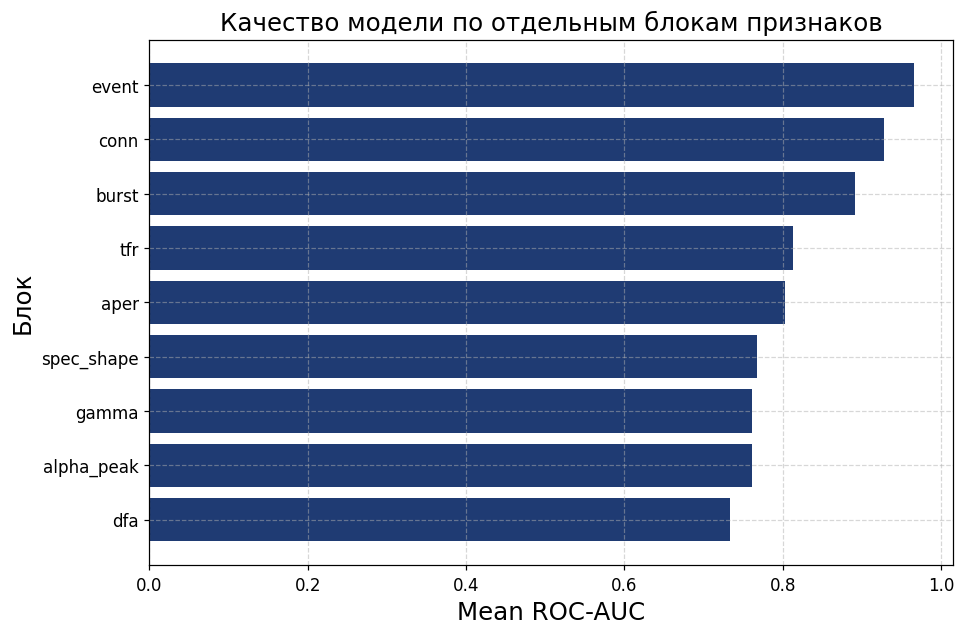

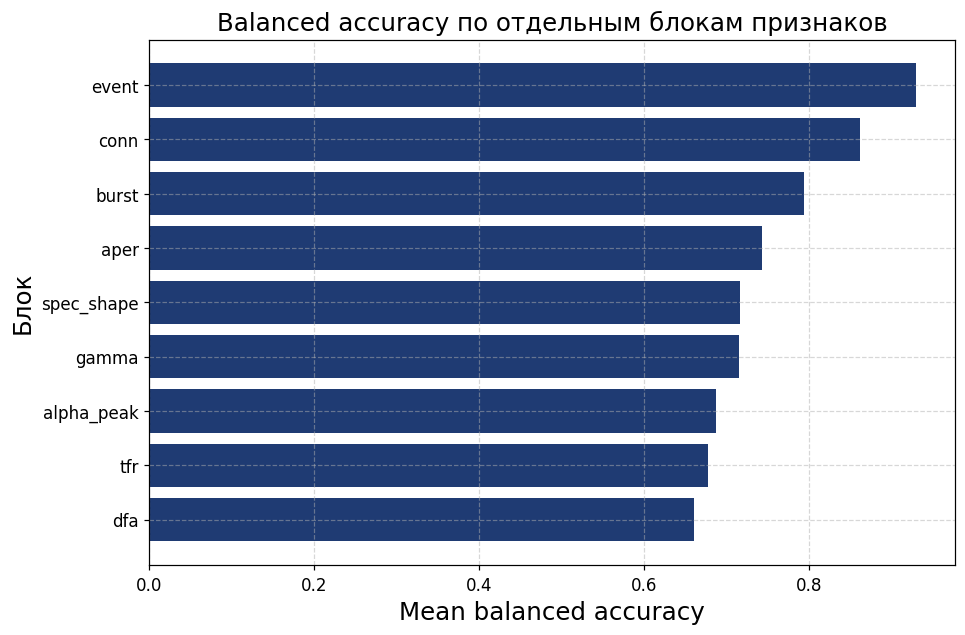

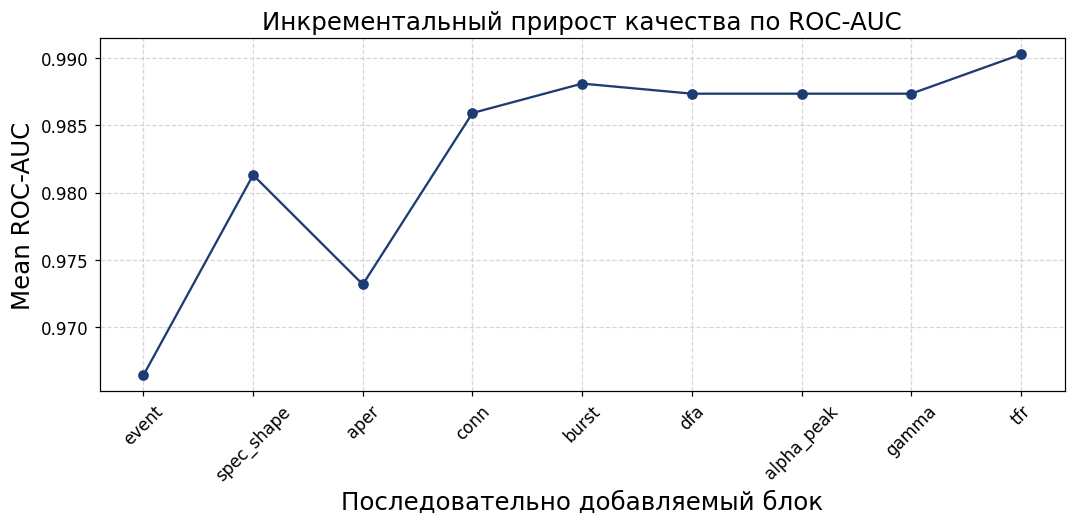

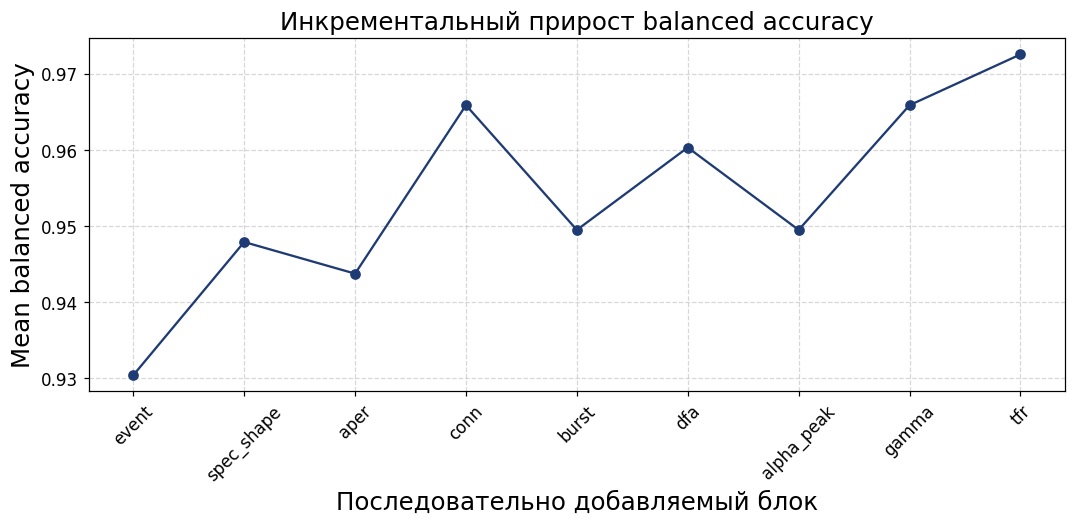

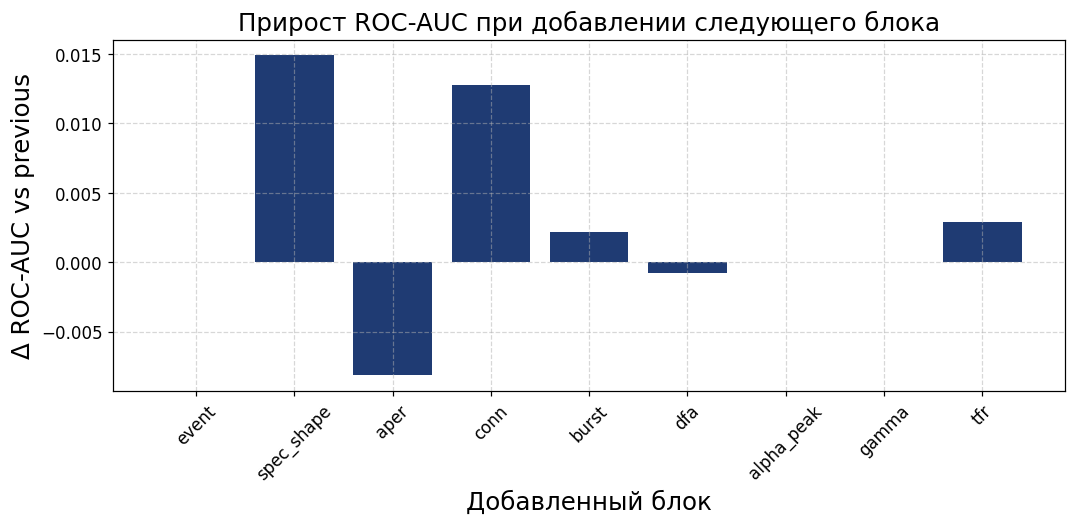

In [42]:
# @title 9.3. Визуализация блочного и инкрементального сравнения


from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

BLOCKWISE_PATH = EDA_DIR / "blockwise_honest_cv_results.csv"
INCREMENTAL_PATH = EDA_DIR / "incremental_blockwise_honest_cv_results.csv"

if not BLOCKWISE_PATH.exists():
    BLOCKWISE_PATH = Path("/mnt/data/blockwise_honest_cv_results.csv")

if not INCREMENTAL_PATH.exists():
    INCREMENTAL_PATH = Path("/mnt/data/incremental_blockwise_honest_cv_results.csv")


# =========================================
# 1. Загрузка
# =========================================
bw = pd.read_csv(BLOCKWISE_PATH)
inc = pd.read_csv(INCREMENTAL_PATH)


# =========================================
# 2. Block-wise ROC-AUC
# =========================================
tmp = bw.sort_values("roc_auc_mean", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(tmp["block"], tmp["roc_auc_mean"])
plt.xlabel("Mean ROC-AUC")
plt.ylabel("Блок")
plt.title("Качество модели по отдельным блокам признаков")
plt.tight_layout()
plt.show()


# =========================================
# 3. Block-wise balanced accuracy
# =========================================
tmp = bw.sort_values("balanced_accuracy_mean", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(tmp["block"], tmp["balanced_accuracy_mean"])
plt.xlabel("Mean balanced accuracy")
plt.ylabel("Блок")
plt.title("Balanced accuracy по отдельным блокам признаков")
plt.tight_layout()
plt.show()


# =========================================
# 4. Incremental ROC-AUC
# =========================================
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(inc) + 1), inc["roc_auc_mean"], marker="o")
plt.xticks(range(1, len(inc) + 1), inc["last_added_block"], rotation=45)
plt.xlabel("Последовательно добавляемый блок")
plt.ylabel("Mean ROC-AUC")
plt.title("Инкрементальный прирост качества по ROC-AUC")
plt.tight_layout()
plt.show()


# =========================================
# 5. Incremental balanced accuracy
# =========================================
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(inc) + 1), inc["balanced_accuracy_mean"], marker="o")
plt.xticks(range(1, len(inc) + 1), inc["last_added_block"], rotation=45)
plt.xlabel("Последовательно добавляемый блок")
plt.ylabel("Mean balanced accuracy")
plt.title("Инкрементальный прирост balanced accuracy")
plt.tight_layout()
plt.show()


# =========================================
# 6. Прирост по шагам
# =========================================
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(inc) + 1), inc["delta_roc_auc_vs_prev"].fillna(0))
plt.xticks(range(1, len(inc) + 1), inc["last_added_block"], rotation=45)
plt.xlabel("Добавленный блок")
plt.ylabel("Δ ROC-AUC vs previous")
plt.title("Прирост ROC-AUC при добавлении следующего блока")
plt.tight_layout()
plt.show()

## 10. Компактные и block-aware модели

Цель блока — проверить, можно ли сохранить высокое качество классификации при ограниченном числе признаков и более строгом train-only отборе внутри блоков.

In [ ]:
# @title 10.1. Компактные модели: event, event + spec_shape, event + spec_shape + conn, full


from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, f1_score, accuracy_score


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"

if not SUBJ_PATH.exists():
    SUBJ_PATH = Path("/mnt/data/subject_level_core_clean.csv")

OUT_RESULTS = EDA_DIR / "compact_core_models_honest_cv_results.csv"
OUT_OOF = EDA_DIR / "compact_core_models_honest_cv_oof.csv"


# =========================================
# 1. Загрузка
# =========================================
df = pd.read_csv(SUBJ_PATH)
df["group"] = df["group"].astype(str).str.strip()
df["subject_id"] = df["subject_id"].astype(str).str.strip()

y = df["group"].map({"Control": 0, "TBI": 1}).astype(int).values
subjects = df["subject_id"].values

key_cols = ["group", "subject_id", "n_records_subject"]
feature_cols = [c for c in df.columns if c not in key_cols]


# =========================================
# 2. Блоки
# =========================================
def get_block(col):
    if "__" in col:
        return col.split("__")[0]
    return "other"

block_to_features = {}
for c in feature_cols:
    block = get_block(c)
    block_to_features.setdefault(block, []).append(c)

event_feats = block_to_features.get("event", [])
spec_shape_feats = block_to_features.get("spec_shape", [])
conn_feats = block_to_features.get("conn", [])

feature_sets = {
    "event_only": event_feats,
    "event_plus_spec_shape": event_feats + spec_shape_feats,
    "event_plus_spec_shape_plus_conn": event_feats + spec_shape_feats + conn_feats,
    "full_546": feature_cols,
}


# =========================================
# 3. Pipeline
# =========================================
def build_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            max_iter=5000,
            class_weight="balanced",
            random_state=42,
        )),
    ])


# =========================================
# 4. Honest CV
# =========================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
oof_rows = []

for set_name, feats in feature_sets.items():
    X = df[feats].copy()

    fold_metrics = []

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y[train_idx]
        y_test = y[test_idx]

        pipe = build_pipeline()
        pipe.fit(X_train, y_train)

        y_prob = pipe.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        fold_metrics.append({
            "fold": fold_idx,
            "roc_auc": roc_auc_score(y_test, y_prob),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "accuracy": accuracy_score(y_test, y_pred),
        })

        for i, idx in enumerate(test_idx):
            oof_rows.append({
                "model_name": set_name,
                "fold": fold_idx,
                "subject_id": subjects[idx],
                "y_true": int(y_test[i]),
                "y_prob": float(y_prob[i]),
                "y_pred": int(y_pred[i]),
            })

    fold_df = pd.DataFrame(fold_metrics)

    rows.append({
        "model_name": set_name,
        "n_features": len(feats),
        "roc_auc_mean": fold_df["roc_auc"].mean(),
        "roc_auc_std": fold_df["roc_auc"].std(ddof=0),
        "balanced_accuracy_mean": fold_df["balanced_accuracy"].mean(),
        "balanced_accuracy_std": fold_df["balanced_accuracy"].std(ddof=0),
        "f1_mean": fold_df["f1"].mean(),
        "f1_std": fold_df["f1"].std(ddof=0),
        "accuracy_mean": fold_df["accuracy"].mean(),
        "accuracy_std": fold_df["accuracy"].std(ddof=0),
    })

res_df = pd.DataFrame(rows).sort_values(
    ["roc_auc_mean", "balanced_accuracy_mean"],
    ascending=False
).reset_index(drop=True)

# приращения относительно предыдущей компактной модели
order = [
    "event_only",
    "event_plus_spec_shape",
    "event_plus_spec_shape_plus_conn",
    "full_546",
]
res_df["order_idx"] = res_df["model_name"].map({name: i for i, name in enumerate(order)})
res_df = res_df.sort_values("order_idx").reset_index(drop=True)
res_df["delta_roc_auc_vs_prev"] = res_df["roc_auc_mean"].diff()
res_df["delta_bal_acc_vs_prev"] = res_df["balanced_accuracy_mean"].diff()
res_df = res_df.drop(columns=["order_idx"])

oof_df = pd.DataFrame(oof_rows)

res_df.to_csv(OUT_RESULTS, index=False, encoding="utf-8")
oof_df.to_csv(OUT_OOF, index=False, encoding="utf-8")

print("✅ Компактные core-модели посчитаны")
print("Результаты:", OUT_RESULTS)
print("OOF predictions:", OUT_OOF)
display(res_df)

✅ Компактные core-модели посчитаны
Результаты: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/compact_core_models_honest_cv_results.csv
OOF predictions: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/compact_core_models_honest_cv_oof.csv


,model_name,n_features,roc_auc_mean,roc_auc_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,accuracy_mean,accuracy_std,delta_roc_auc_vs_prev,delta_bal_acc_vs_prev
0,event_only,14,0.966413,0.024478,0.930401,0.039345,0.931019,0.041079,0.927083,0.040911,NaN,NaN
1,event_plus_spec_shape,29,0.981303,0.019851,0.947886,0.028025,0.948459,0.030068,0.945265,0.029538,0.014890,0.017485
2,event_plus_spec_shape_plus_conn,249,0.987407,0.021672,0.969524,0.032571,0.972015,0.031320,0.969697,0.033195,0.006104,0.021637
3,full_546,546,0.990273,0.011373,0.948997,0.027662,0.947831,0.029290,0.945076,0.029778,0.002865,-0.020526


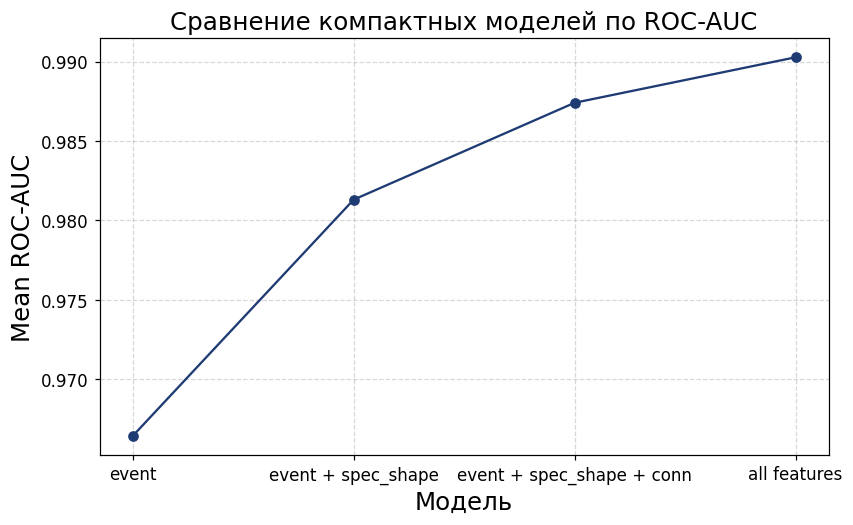

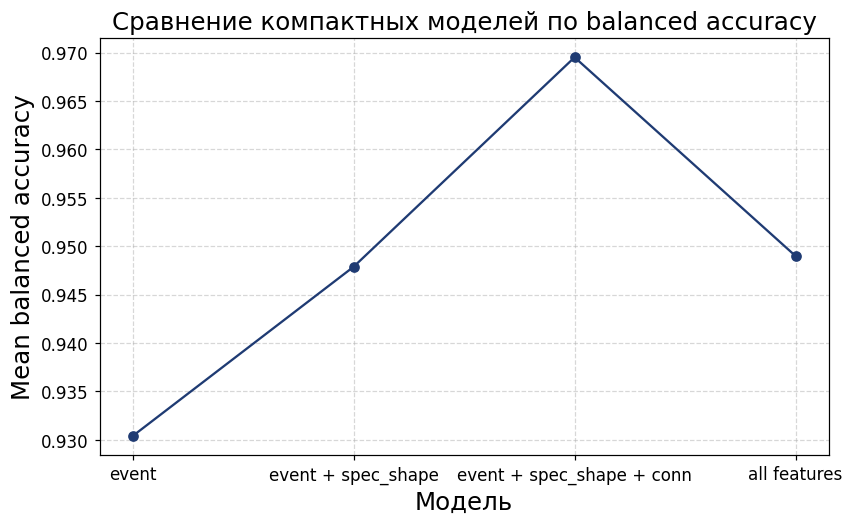

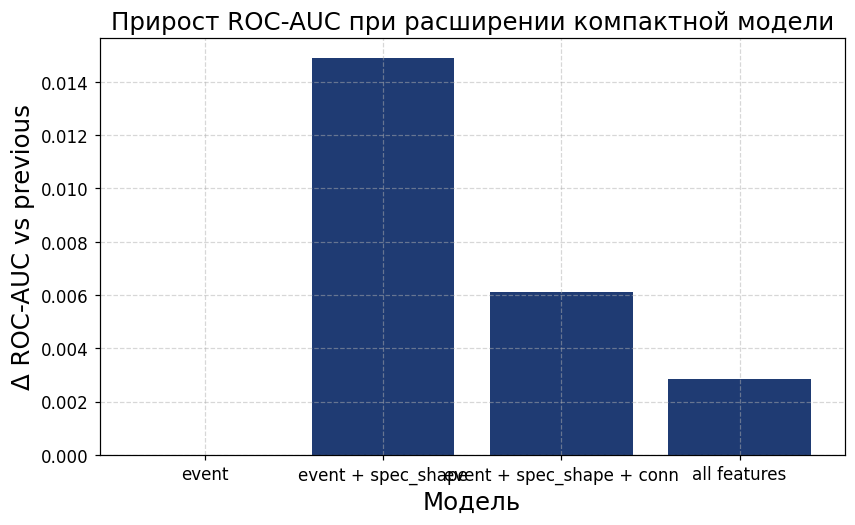

In [43]:
# @title 10.2. Компактные модели: визуализация сравнения качества


from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"
RESULTS_PATH = EDA_DIR / "compact_core_models_honest_cv_results.csv"

if not RESULTS_PATH.exists():
    RESULTS_PATH = Path("/mnt/data/compact_core_models_honest_cv_results.csv")


# =========================================
# 1. Загрузка
# =========================================
res = pd.read_csv(RESULTS_PATH)

pretty_map = {
    "event_only": "event",
    "event_plus_spec_shape": "event + spec_shape",
    "event_plus_spec_shape_plus_conn": "event + spec_shape + conn",
    "full_546": "all features",
}
res["label"] = res["model_name"].map(pretty_map)

# сохраняем порядок
order = ["event", "event + spec_shape", "event + spec_shape + conn", "all features"]
res["label"] = pd.Categorical(res["label"], categories=order, ordered=True)
res = res.sort_values("label")


# =========================================
# 2. ROC-AUC
# =========================================
plt.figure(figsize=(8, 5))
plt.plot(res["label"], res["roc_auc_mean"], marker="o")
plt.ylabel("Mean ROC-AUC")
plt.xlabel("Модель")
plt.title("Сравнение компактных моделей по ROC-AUC")
plt.tight_layout()
plt.show()


# =========================================
# 3. Balanced accuracy
# =========================================
plt.figure(figsize=(8, 5))
plt.plot(res["label"], res["balanced_accuracy_mean"], marker="o")
plt.ylabel("Mean balanced accuracy")
plt.xlabel("Модель")
plt.title("Сравнение компактных моделей по balanced accuracy")
plt.tight_layout()
plt.show()


# =========================================
# 4. Прирост по ROC-AUC
# =========================================
plt.figure(figsize=(8, 5))
plt.bar(res["label"], res["delta_roc_auc_vs_prev"].fillna(0))
plt.ylabel("Δ ROC-AUC vs previous")
plt.xlabel("Модель")
plt.title("Прирост ROC-AUC при расширении компактной модели")
plt.tight_layout()
plt.show()

In [44]:
# @title 10.3. Block-aware compact models: train-only top-k внутри блоков


from pathlib import Path
import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, f1_score, accuracy_score


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"

if not SUBJ_PATH.exists():
    SUBJ_PATH = Path("/mnt/data/subject_level_core_clean.csv")

OUT_RESULTS = EDA_DIR / "block_aware_compact_models_honest_cv_results.csv"
OUT_DETAILS = EDA_DIR / "block_aware_compact_models_selected_features.csv"


# =========================================
# 1. Загрузка
# =========================================
df = pd.read_csv(SUBJ_PATH)
df["group"] = df["group"].astype(str).str.strip()
df["subject_id"] = df["subject_id"].astype(str).str.strip()

y = df["group"].map({"Control": 0, "TBI": 1}).astype(int).values
subjects = df["subject_id"].values

key_cols = ["group", "subject_id", "n_records_subject"]
feature_cols = [c for c in df.columns if c not in key_cols]


# =========================================
# 2. Блоки
# =========================================
def get_block(col):
    if "__" in col:
        return col.split("__")[0]
    return "other"

block_to_features = {}
for c in feature_cols:
    block = get_block(c)
    block_to_features.setdefault(block, []).append(c)

event_feats = block_to_features.get("event", [])
spec_shape_feats = block_to_features.get("spec_shape", [])
conn_feats = block_to_features.get("conn", [])


# =========================================
# 3. Вспомогательные функции
# =========================================
def score_features_train_only(X_train, y_train, feats):
    grp1 = y_train == 1
    grp0 = y_train == 0

    rows = []
    for feat in feats:
        x1 = pd.to_numeric(X_train.loc[grp1, feat], errors="coerce").dropna()
        x0 = pd.to_numeric(X_train.loc[grp0, feat], errors="coerce").dropna()

        if len(x1) < 2 or len(x0) < 2:
            continue
        if pd.concat([x1, x0]).nunique() <= 1:
            continue

        try:
            _, p = mannwhitneyu(x1, x0, alternative="two-sided")
        except Exception:
            continue

        mean_diff = x1.mean() - x0.mean()

        rows.append({
            "feature": feat,
            "p_value": float(p),
            "abs_mean_diff": abs(float(mean_diff)),
        })

    if len(rows) == 0:
        return pd.DataFrame(columns=["feature", "p_value", "abs_mean_diff"])

    out = pd.DataFrame(rows).sort_values(
        ["p_value", "abs_mean_diff"],
        ascending=[True, False]
    ).reset_index(drop=True)

    return out


def select_topk_within_block_train_only(X_train, y_train, feats, top_k):
    ranked = score_features_train_only(X_train, y_train, feats)
    if ranked.empty:
        return []
    return ranked["feature"].head(min(top_k, len(ranked))).tolist()


def build_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            max_iter=5000,
            class_weight="balanced",
            random_state=42,
        )),
    ])


# =========================================
# 4. Конфигурации моделей
# =========================================
# Последняя цифра — top-k на блок
configs = [
    {
        "model_name": "event_top5",
        "blocks": [("event", 5)],
    },
    {
        "model_name": "event_top5_plus_spec_shape_top5",
        "blocks": [("event", 5), ("spec_shape", 5)],
    },
    {
        "model_name": "event_top5_plus_spec_shape_top5_plus_conn_top5",
        "blocks": [("event", 5), ("spec_shape", 5), ("conn", 5)],
    },
    {
        "model_name": "event_top10_plus_spec_shape_top5_plus_conn_top10",
        "blocks": [("event", 10), ("spec_shape", 5), ("conn", 10)],
    },
]


# =========================================
# 5. Honest CV
# =========================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
detail_rows = []

for cfg in configs:
    fold_metrics = []
    selected_counts = []

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(df, y), start=1):
        X_train = df.iloc[train_idx][feature_cols].copy()
        X_test = df.iloc[test_idx][feature_cols].copy()
        y_train = y[train_idx]
        y_test = y[test_idx]

        selected_features = []

        for block_name, top_k in cfg["blocks"]:
            feats = block_to_features.get(block_name, [])
            chosen = select_topk_within_block_train_only(X_train, y_train, feats, top_k)
            selected_features.extend(chosen)

            for feat in chosen:
                detail_rows.append({
                    "model_name": cfg["model_name"],
                    "fold": fold_idx,
                    "block": block_name,
                    "feature": feat,
                })

        # уникализируем, сохраняя порядок
        selected_features = list(dict.fromkeys(selected_features))
        selected_counts.append(len(selected_features))

        X_train_sel = X_train[selected_features].copy()
        X_test_sel = X_test[selected_features].copy()

        pipe = build_pipeline()
        pipe.fit(X_train_sel, y_train)

        y_prob = pipe.predict_proba(X_test_sel)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        fold_metrics.append({
            "fold": fold_idx,
            "roc_auc": roc_auc_score(y_test, y_prob),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "accuracy": accuracy_score(y_test, y_pred),
        })

    fold_df = pd.DataFrame(fold_metrics)

    rows.append({
        "model_name": cfg["model_name"],
        "mean_n_selected_features": np.mean(selected_counts),
        "min_n_selected_features": np.min(selected_counts),
        "max_n_selected_features": np.max(selected_counts),
        "roc_auc_mean": fold_df["roc_auc"].mean(),
        "roc_auc_std": fold_df["roc_auc"].std(ddof=0),
        "balanced_accuracy_mean": fold_df["balanced_accuracy"].mean(),
        "balanced_accuracy_std": fold_df["balanced_accuracy"].std(ddof=0),
        "f1_mean": fold_df["f1"].mean(),
        "f1_std": fold_df["f1"].std(ddof=0),
        "accuracy_mean": fold_df["accuracy"].mean(),
        "accuracy_std": fold_df["accuracy"].std(ddof=0),
    })

res_df = pd.DataFrame(rows)
detail_df = pd.DataFrame(detail_rows)

# порядок вывода
order = {
    "event_top5": 0,
    "event_top5_plus_spec_shape_top5": 1,
    "event_top5_plus_spec_shape_top5_plus_conn_top5": 2,
    "event_top10_plus_spec_shape_top5_plus_conn_top10": 3,
}
res_df["order_idx"] = res_df["model_name"].map(order)
res_df = res_df.sort_values("order_idx").reset_index(drop=True)
res_df["delta_roc_auc_vs_prev"] = res_df["roc_auc_mean"].diff()
res_df["delta_bal_acc_vs_prev"] = res_df["balanced_accuracy_mean"].diff()
res_df = res_df.drop(columns=["order_idx"])

res_df.to_csv(OUT_RESULTS, index=False, encoding="utf-8")
detail_df.to_csv(OUT_DETAILS, index=False, encoding="utf-8")

print("✅ Block-aware compact models завершены")
print("Результаты:", OUT_RESULTS)
print("Выбранные признаки по fold:", OUT_DETAILS)
display(res_df)

✅ Block-aware compact models завершены
Результаты: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/block_aware_compact_models_honest_cv_results.csv
Выбранные признаки по fold: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/block_aware_compact_models_selected_features.csv


,model_name,mean_n_selected_features,min_n_selected_features,max_n_selected_features,roc_auc_mean,roc_auc_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,accuracy_mean,accuracy_std,delta_roc_auc_vs_prev,delta_bal_acc_vs_prev
0,event_top5,5.0,5,5,0.970785,0.028499,0.931805,0.051095,0.928997,0.056181,0.927083,0.056062,NaN,NaN
1,event_top5_plus_spec_shape_top5,10.0,10,10,0.978351,0.021016,0.948705,0.044681,0.946292,0.049471,0.945455,0.048485,0.007566,0.016901
2,event_top5_plus_spec_shape_top5_plus_conn_top5,15.0,15,15,0.974659,0.024448,0.957594,0.030373,0.960935,0.029203,0.957386,0.030831,-0.003693,0.008889
3,event_top10_plus_spec_shape_top5_plus_conn_top10,25.0,25,25,0.977655,0.023870,0.958705,0.034642,0.960181,0.035194,0.957576,0.036364,0.002996,0.001111


In [45]:
# @title 10.4. Block-aware compact models: частота выбора признаков


from pathlib import Path
import pandas as pd


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

DETAILS_PATH = EDA_DIR / "block_aware_compact_models_selected_features.csv"

if not DETAILS_PATH.exists():
    DETAILS_PATH = Path("/mnt/data/block_aware_compact_models_selected_features.csv")


# =========================================
# 1. Загрузка
# =========================================
det = pd.read_csv(DETAILS_PATH)


# =========================================
# 2. Частота выбора
# =========================================
freq_df = (
    det.groupby(["model_name", "block", "feature"], as_index=False)
    .agg(
        n_selected_folds=("fold", "nunique")
    )
    .sort_values(["model_name", "n_selected_folds", "feature"], ascending=[True, False, True])
    .reset_index(drop=True)
)

print("✅ Частота выбора признаков внутри block-aware compact models")
for model_name in freq_df["model_name"].unique():
    print(f"\n=== {model_name} ===")
    display(freq_df[freq_df["model_name"] == model_name].head(30))

✅ Частота выбора признаков внутри block-aware compact models

=== event_top10_plus_spec_shape_top5_plus_conn_top10 ===


,model_name,block,feature,n_selected_folds
0,event_top10_plus_spec_shape_top5_plus_conn_top10,conn,conn__clustering__coh_theta,5
1,event_top10_plus_spec_shape_top5_plus_conn_top10,conn,conn__clustering__plv_theta,5
2,event_top10_plus_spec_shape_top5_plus_conn_top10,conn,conn__hub_z_max__dtf_delta,5
3,event_top10_plus_spec_shape_top5_plus_conn_top10,conn,conn__hub_z_max__plv_delta,5
4,event_top10_plus_spec_shape_top5_plus_conn_top10,conn,conn__n_hubs__coh_delta,5
5,event_top10_plus_spec_shape_top5_plus_conn_top10,event,event__line_length_uv,5
6,event_top10_plus_spec_shape_top5_plus_conn_top10,event,event__n_involved_ch,5
7,event_top10_plus_spec_shape_top5_plus_conn_top10,event,event__peak_to_peak_uv,5
8,event_top10_plus_spec_shape_top5_plus_conn_top10,event,event__propagation_ms,5
9,event_top10_plus_spec_shape_top5_plus_conn_top10,event,event__slope_rise_uvs,5



=== event_top5 ===


,model_name,block,feature,n_selected_folds
34,event_top5,event,event__line_length_uv,5
35,event_top5,event,event__n_involved_ch,5
36,event_top5,event,event__propagation_ms,5
37,event_top5,event,event__spike_to_slow_ratio,5
38,event_top5,event,event__z_peak,5



=== event_top5_plus_spec_shape_top5 ===


,model_name,block,feature,n_selected_folds
39,event_top5_plus_spec_shape_top5,event,event__line_length_uv,5
40,event_top5_plus_spec_shape_top5,event,event__n_involved_ch,5
41,event_top5_plus_spec_shape_top5,event,event__propagation_ms,5
42,event_top5_plus_spec_shape_top5,event,event__spike_to_slow_ratio,5
43,event_top5_plus_spec_shape_top5,event,event__z_peak,5
44,event_top5_plus_spec_shape_top5,spec_shape,spec_shape__spectral_entropy_norm__central,5
45,event_top5_plus_spec_shape_top5,spec_shape,spec_shape__spectral_entropy_norm__frontal,5
46,event_top5_plus_spec_shape_top5,spec_shape,spec_shape__spectral_entropy_raw__central,5
47,event_top5_plus_spec_shape_top5,spec_shape,spec_shape__spectral_entropy_raw__frontal,5
48,event_top5_plus_spec_shape_top5,spec_shape,spec_shape__sef95_hz__frontal,3



=== event_top5_plus_spec_shape_top5_plus_conn_top5 ===


,model_name,block,feature,n_selected_folds
50,event_top5_plus_spec_shape_top5_plus_conn_top5,conn,conn__clustering__plv_theta,5
51,event_top5_plus_spec_shape_top5_plus_conn_top5,event,event__line_length_uv,5
52,event_top5_plus_spec_shape_top5_plus_conn_top5,event,event__n_involved_ch,5
53,event_top5_plus_spec_shape_top5_plus_conn_top5,event,event__propagation_ms,5
54,event_top5_plus_spec_shape_top5_plus_conn_top5,event,event__spike_to_slow_ratio,5
55,event_top5_plus_spec_shape_top5_plus_conn_top5,event,event__z_peak,5
56,event_top5_plus_spec_shape_top5_plus_conn_top5,spec_shape,spec_shape__spectral_entropy_norm__central,5
57,event_top5_plus_spec_shape_top5_plus_conn_top5,spec_shape,spec_shape__spectral_entropy_norm__frontal,5
58,event_top5_plus_spec_shape_top5_plus_conn_top5,spec_shape,spec_shape__spectral_entropy_raw__central,5
59,event_top5_plus_spec_shape_top5_plus_conn_top5,spec_shape,spec_shape__spectral_entropy_raw__frontal,5


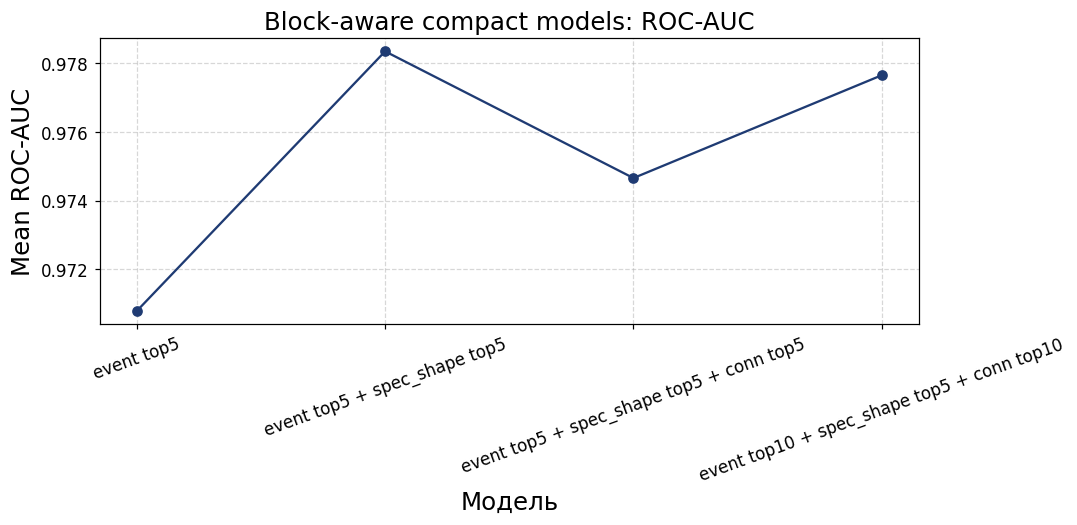

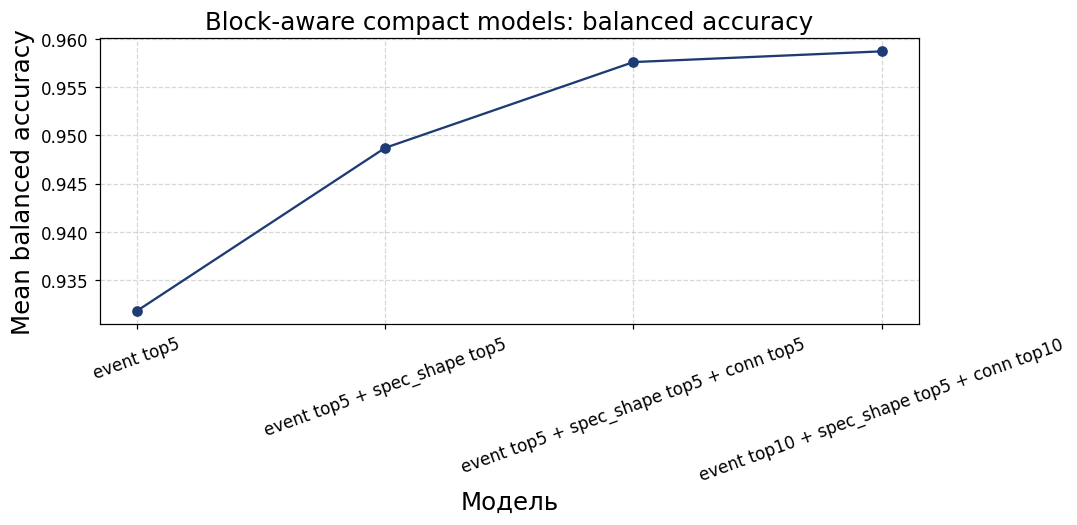

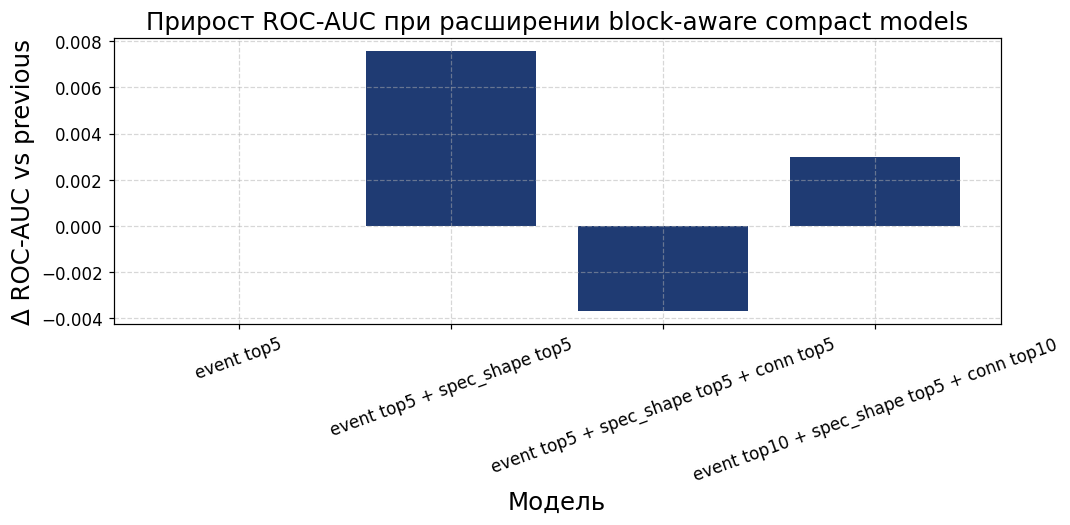

In [46]:
# @title 10.5. Block-aware compact models: визуализация качества


from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

RESULTS_PATH = EDA_DIR / "block_aware_compact_models_honest_cv_results.csv"

if not RESULTS_PATH.exists():
    RESULTS_PATH = Path("/mnt/data/block_aware_compact_models_honest_cv_results.csv")


# =========================================
# 1. Загрузка
# =========================================
res = pd.read_csv(RESULTS_PATH)

pretty_map = {
    "event_top5": "event top5",
    "event_top5_plus_spec_shape_top5": "event top5 + spec_shape top5",
    "event_top5_plus_spec_shape_top5_plus_conn_top5": "event top5 + spec_shape top5 + conn top5",
    "event_top10_plus_spec_shape_top5_plus_conn_top10": "event top10 + spec_shape top5 + conn top10",
}

res["label"] = res["model_name"].map(pretty_map)

order = [
    "event top5",
    "event top5 + spec_shape top5",
    "event top5 + spec_shape top5 + conn top5",
    "event top10 + spec_shape top5 + conn top10",
]
res["label"] = pd.Categorical(res["label"], categories=order, ordered=True)
res = res.sort_values("label")


# =========================================
# 2. ROC-AUC
# =========================================
plt.figure(figsize=(10, 5))
plt.plot(res["label"], res["roc_auc_mean"], marker="o")
plt.ylabel("Mean ROC-AUC")
plt.xlabel("Модель")
plt.title("Block-aware compact models: ROC-AUC")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# =========================================
# 3. Balanced accuracy
# =========================================
plt.figure(figsize=(10, 5))
plt.plot(res["label"], res["balanced_accuracy_mean"], marker="o")
plt.ylabel("Mean balanced accuracy")
plt.xlabel("Модель")
plt.title("Block-aware compact models: balanced accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# =========================================
# 4. Прирост ROC-AUC
# =========================================
plt.figure(figsize=(10, 5))
plt.bar(res["label"], res["delta_roc_auc_vs_prev"].fillna(0))
plt.ylabel("Δ ROC-AUC vs previous")
plt.xlabel("Модель")
plt.title("Прирост ROC-AUC при расширении block-aware compact models")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 11. Инкрементальный анализ по всем блокам признаков

Здесь признаки добавляются поэтапно, чтобы оценить, какие блоки дают наибольший прирост качества относительно уже включённых групп.

In [48]:
# @title 11.1. Инкрементальный анализ по 11 блокам признаков


from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, f1_score, accuracy_score


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

SUBJ_PATH = EDA_DIR / "subject_level_core_clean.csv"

if not SUBJ_PATH.exists():
    SUBJ_PATH = Path("/mnt/data/subject_level_core_clean.csv")

OUT_RESULTS = EDA_DIR / "incremental_all11_ordered_honest_cv_results.csv"


# =========================================
# 1. Загрузка
# =========================================
df = pd.read_csv(SUBJ_PATH)
df["group"] = df["group"].astype(str).str.strip()

y = df["group"].map({"Control": 0, "TBI": 1}).astype(int).values

key_cols = ["group", "subject_id", "n_records_subject"]
feature_cols = [c for c in df.columns if c not in key_cols]


# =========================================
# 2. Блоки и порядок
# =========================================
def get_block(col):
    if "__" in col:
        return col.split("__")[0]
    return "other"


block_to_features = {}
for c in feature_cols:
    block = get_block(c)
    block_to_features.setdefault(block, []).append(c)

ordered_blocks = [
    "bp",
    "idx",
    "spec_shape",
    "aper",
    "alpha_peak",
    "gamma",
    "dfa",
    "burst",
    "conn",
    "event",
    "tfr",
]

ordered_blocks = [b for b in ordered_blocks if b in block_to_features]

print("Блоки для анализа:")
print(ordered_blocks)


# =========================================
# 3. Pipeline
# =========================================
def build_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="liblinear",
            max_iter=5000,
            class_weight="balanced",
            random_state=42,
        )),
    ])


# =========================================
# 4. Honest CV по шагам
# =========================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
current_blocks = []
current_features = []

for block in ordered_blocks:
    current_blocks.append(block)
    current_features.extend(block_to_features[block])

    X = df[current_features].copy()
    fold_metrics = []

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y[train_idx]
        y_test = y[test_idx]

        pipe = build_pipeline()
        pipe.fit(X_train, y_train)

        y_prob = pipe.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        fold_metrics.append({
            "fold": fold_idx,
            "roc_auc": roc_auc_score(y_test, y_prob),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "accuracy": accuracy_score(y_test, y_pred),
        })

    fold_df = pd.DataFrame(fold_metrics)

    rows.append({
        "step_name": " + ".join(current_blocks),
        "last_added_block": block,
        "n_blocks_used": len(current_blocks),
        "n_features_used": len(current_features),
        "roc_auc_mean": fold_df["roc_auc"].mean(),
        "roc_auc_std": fold_df["roc_auc"].std(ddof=0),
        "balanced_accuracy_mean": fold_df["balanced_accuracy"].mean(),
        "balanced_accuracy_std": fold_df["balanced_accuracy"].std(ddof=0),
        "f1_mean": fold_df["f1"].mean(),
        "f1_std": fold_df["f1"].std(ddof=0),
        "accuracy_mean": fold_df["accuracy"].mean(),
        "accuracy_std": fold_df["accuracy"].std(ddof=0),
    })

res_df = pd.DataFrame(rows)
res_df["delta_roc_auc_vs_prev"] = res_df["roc_auc_mean"].diff()
res_df["delta_bal_acc_vs_prev"] = res_df["balanced_accuracy_mean"].diff()
res_df["delta_f1_vs_prev"] = res_df["f1_mean"].diff()
res_df["delta_acc_vs_prev"] = res_df["accuracy_mean"].diff()

# накопленный максимум для удобства интерпретации
res_df["best_roc_auc_so_far"] = res_df["roc_auc_mean"].cummax()
res_df["best_bal_acc_so_far"] = res_df["balanced_accuracy_mean"].cummax()

res_df.to_csv(OUT_RESULTS, index=False, encoding="utf-8")

print("✅ Incremental-анализ по всем 11 блокам завершён")
print("Путь:", OUT_RESULTS)
display(res_df)

Блоки для анализа:
['spec_shape', 'aper', 'alpha_peak', 'gamma', 'dfa', 'burst', 'conn', 'event', 'tfr']
✅ Incremental-анализ по всем 11 блокам завершён
Путь: /content/drive/MyDrive/VKR/TBI/work/output/spectral/tables/eda_record_level_core/incremental_all11_ordered_honest_cv_results.csv


,step_name,last_added_block,n_blocks_used,n_features_used,roc_auc_mean,roc_auc_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,accuracy_mean,accuracy_std,delta_roc_auc_vs_prev,delta_bal_acc_vs_prev,delta_f1_vs_prev,delta_acc_vs_prev,best_roc_auc_so_far,best_bal_acc_so_far
0,spec_shape,spec_shape,1,15,0.767769,0.052282,0.716124,0.039261,0.738090,0.063254,0.719508,0.048392,NaN,NaN,NaN,NaN,0.767769,0.716124
1,spec_shape + aper,aper,2,45,0.810086,0.066011,0.769983,0.061678,0.778629,0.079022,0.767992,0.066461,0.042317,0.053860,0.040540,0.048485,0.810086,0.769983
2,spec_shape + aper + alpha_peak,alpha_peak,3,60,0.824923,0.067094,0.768396,0.064596,0.783917,0.070576,0.767992,0.066461,0.014837,-0.001587,0.005287,0.000000,0.824923,0.769983
3,spec_shape + aper + alpha_peak + gamma,gamma,4,72,0.822089,0.047155,0.751128,0.070006,0.765871,0.075365,0.750000,0.072664,-0.002835,-0.017268,-0.018046,-0.017992,0.824923,0.769983
4,spec_shape + aper + alpha_peak + gamma + dfa,dfa,5,82,0.848602,0.036703,0.744536,0.066178,0.764505,0.055512,0.743750,0.062985,0.026514,-0.006591,-0.001366,-0.006250,0.848602,0.769983
5,spec_shape + aper + alpha_peak + gamma + dfa +...,burst,6,162,0.901055,0.034478,0.841997,0.061844,0.842096,0.059378,0.835417,0.062242,0.052453,0.097460,0.077591,0.091667,0.901055,0.841997
6,spec_shape + aper + alpha_peak + gamma + dfa +...,conn,7,382,0.980629,0.013788,0.941036,0.025988,0.944065,0.025294,0.939205,0.026894,0.079574,0.099039,0.101969,0.103788,0.980629,0.941036
7,spec_shape + aper + alpha_peak + gamma + dfa +...,event,8,396,0.987352,0.011409,0.965848,0.034200,0.965687,0.033618,0.963636,0.035339,0.006722,0.024812,0.021622,0.024432,0.987352,0.965848
8,spec_shape + aper + alpha_peak + gamma + dfa +...,tfr,9,426,0.990273,0.011373,0.972515,0.017578,0.971401,0.018622,0.969508,0.019169,0.002921,0.006667,0.005714,0.005871,0.990273,0.972515


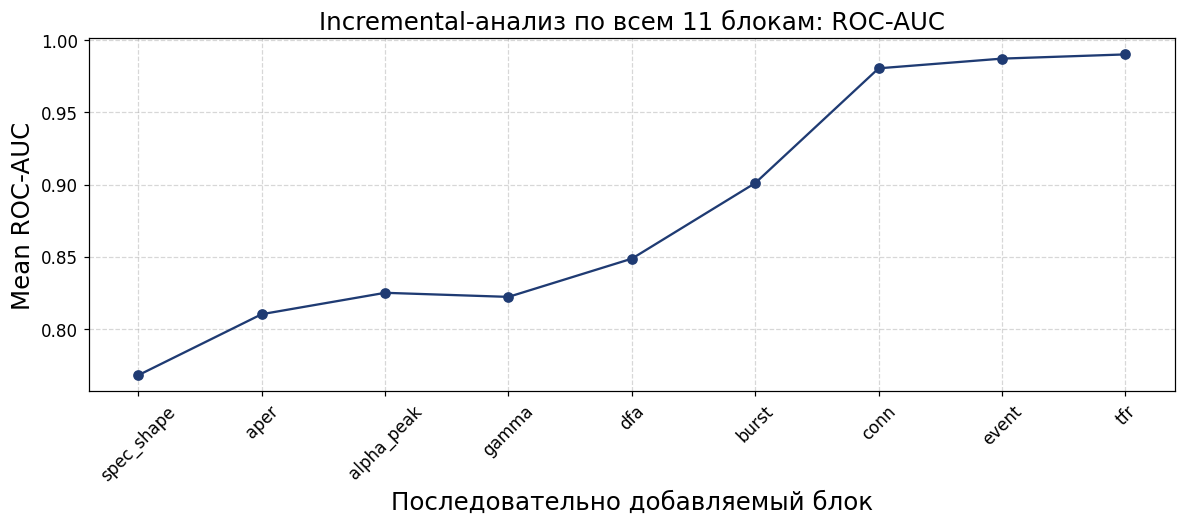

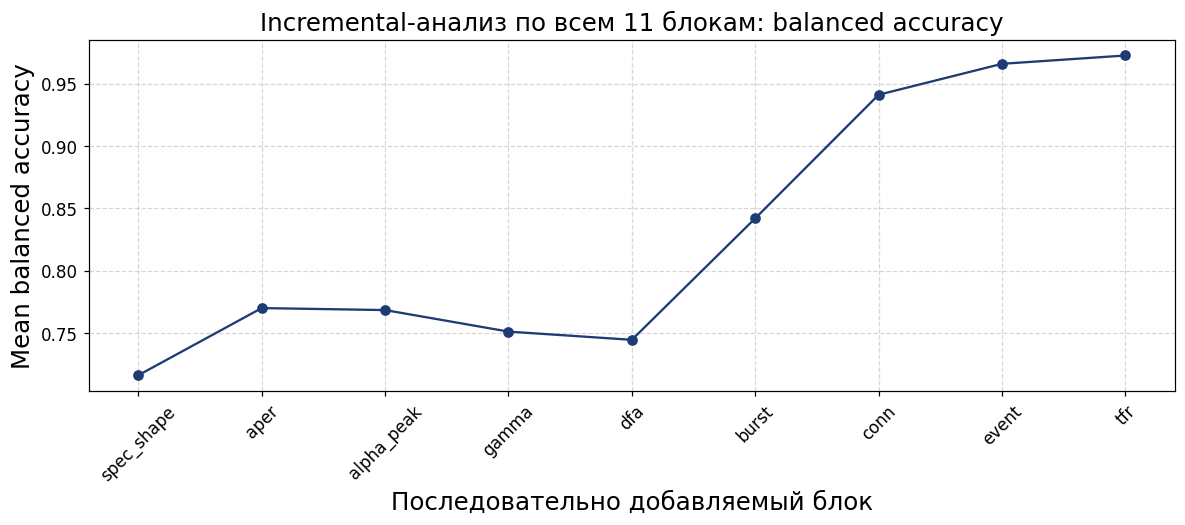

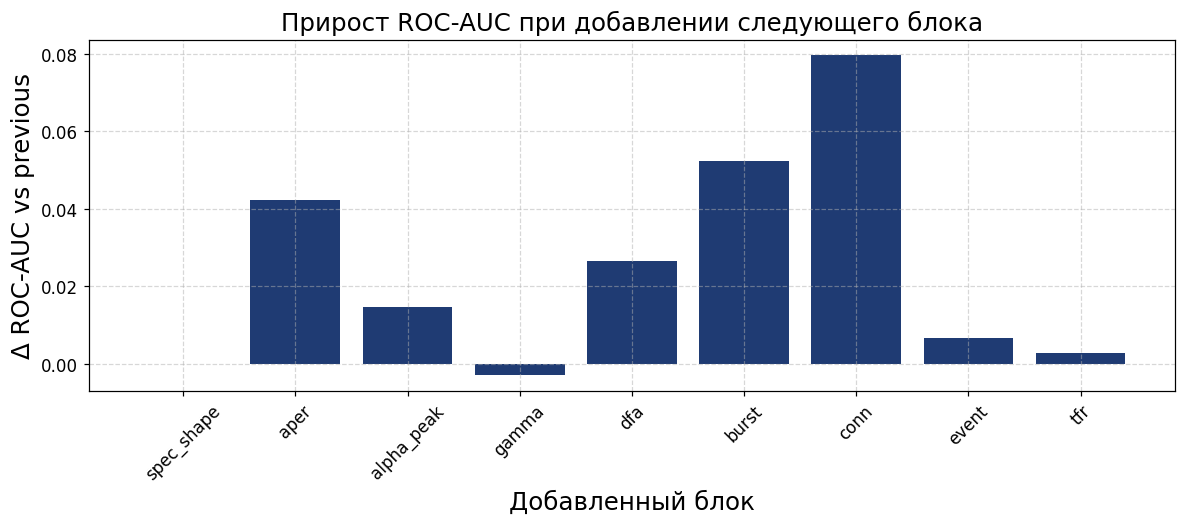

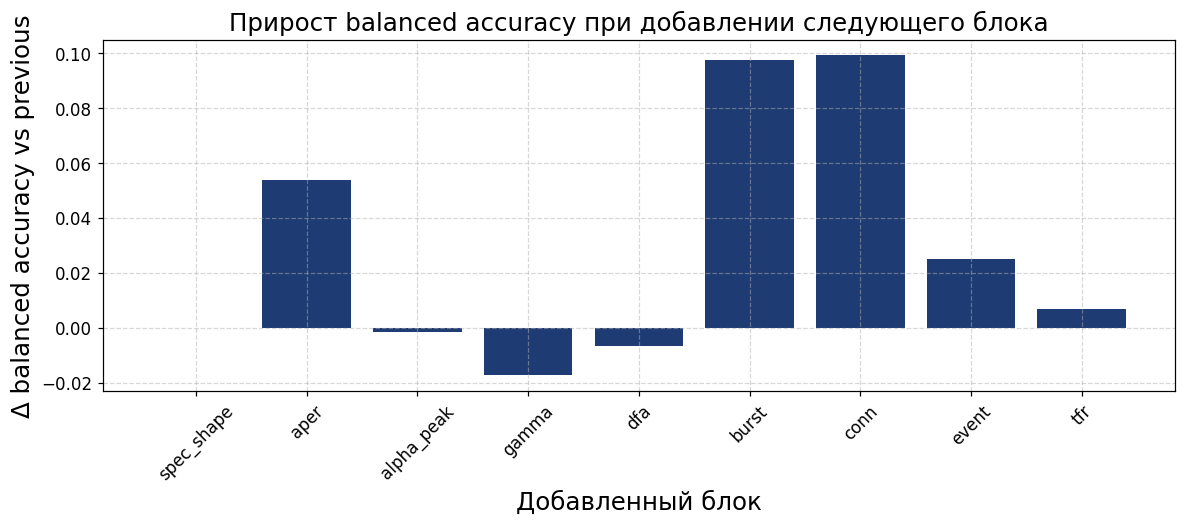

In [49]:
# @title 11.2. Инкрементальный анализ по 11 блокам: визуализация


from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

RESULTS_PATH = EDA_DIR / "incremental_all11_ordered_honest_cv_results.csv"

if not RESULTS_PATH.exists():
    RESULTS_PATH = Path("/mnt/data/incremental_all11_ordered_honest_cv_results.csv")


# =========================================
# 1. Загрузка
# =========================================
res = pd.read_csv(RESULTS_PATH)


# =========================================
# 2. ROC-AUC по шагам
# =========================================
plt.figure(figsize=(11, 5))
plt.plot(range(1, len(res) + 1), res["roc_auc_mean"], marker="o")
plt.xticks(range(1, len(res) + 1), res["last_added_block"], rotation=45)
plt.xlabel("Последовательно добавляемый блок")
plt.ylabel("Mean ROC-AUC")
plt.title("Incremental-анализ по всем 11 блокам: ROC-AUC")
plt.tight_layout()
plt.show()


# =========================================
# 3. Balanced accuracy по шагам
# =========================================
plt.figure(figsize=(11, 5))
plt.plot(range(1, len(res) + 1), res["balanced_accuracy_mean"], marker="o")
plt.xticks(range(1, len(res) + 1), res["last_added_block"], rotation=45)
plt.xlabel("Последовательно добавляемый блок")
plt.ylabel("Mean balanced accuracy")
plt.title("Incremental-анализ по всем 11 блокам: balanced accuracy")
plt.tight_layout()
plt.show()


# =========================================
# 4. Прирост ROC-AUC
# =========================================
plt.figure(figsize=(11, 5))
plt.bar(range(1, len(res) + 1), res["delta_roc_auc_vs_prev"].fillna(0))
plt.xticks(range(1, len(res) + 1), res["last_added_block"], rotation=45)
plt.xlabel("Добавленный блок")
plt.ylabel("Δ ROC-AUC vs previous")
plt.title("Прирост ROC-AUC при добавлении следующего блока")
plt.tight_layout()
plt.show()


# =========================================
# 5. Прирост balanced accuracy
# =========================================
plt.figure(figsize=(11, 5))
plt.bar(range(1, len(res) + 1), res["delta_bal_acc_vs_prev"].fillna(0))
plt.xticks(range(1, len(res) + 1), res["last_added_block"], rotation=45)
plt.xlabel("Добавленный блок")
plt.ylabel("Δ balanced accuracy vs previous")
plt.title("Прирост balanced accuracy при добавлении следующего блока")
plt.tight_layout()
plt.show()

In [50]:
# @title 11.3. Инкрементальный анализ: ключевые шаги и лучшие приросты

from pathlib import Path
import pandas as pd


# =========================================
# 0. Пути
# =========================================
BASE_DIR = Path("/content/drive/MyDrive/VKR/TBI/work/output/spectral/tables")
EDA_DIR = BASE_DIR / "eda_record_level_core"

RESULTS_PATH = EDA_DIR / "incremental_all11_ordered_honest_cv_results.csv"

if not RESULTS_PATH.exists():
    RESULTS_PATH = Path("/mnt/data/incremental_all11_ordered_honest_cv_results.csv")


# =========================================
# 1. Загрузка
# =========================================
res = pd.read_csv(RESULTS_PATH)


# =========================================
# 2. Ключевые шаги
# =========================================
print("=== KEY STEPS ===")
display(
    res[
        [
            "last_added_block",
            "n_blocks_used",
            "n_features_used",
            "roc_auc_mean",
            "balanced_accuracy_mean",
            "delta_roc_auc_vs_prev",
            "delta_bal_acc_vs_prev",
        ]
    ]
)

print("\n=== TOP GAINS BY ROC-AUC ===")
display(
    res.sort_values("delta_roc_auc_vs_prev", ascending=False)[
        [
            "last_added_block",
            "delta_roc_auc_vs_prev",
            "delta_bal_acc_vs_prev",
            "roc_auc_mean",
            "balanced_accuracy_mean",
        ]
    ].head(5)
)

print("\n=== TOP GAINS BY BALANCED ACCURACY ===")
display(
    res.sort_values("delta_bal_acc_vs_prev", ascending=False)[
        [
            "last_added_block",
            "delta_roc_auc_vs_prev",
            "delta_bal_acc_vs_prev",
            "roc_auc_mean",
            "balanced_accuracy_mean",
        ]
    ].head(5)
)

=== KEY STEPS ===


,last_added_block,n_blocks_used,n_features_used,roc_auc_mean,balanced_accuracy_mean,delta_roc_auc_vs_prev,delta_bal_acc_vs_prev
0,spec_shape,1,15,0.767769,0.716124,NaN,NaN
1,aper,2,45,0.810086,0.769983,0.042317,0.053860
2,alpha_peak,3,60,0.824923,0.768396,0.014837,-0.001587
3,gamma,4,72,0.822089,0.751128,-0.002835,-0.017268
4,dfa,5,82,0.848602,0.744536,0.026514,-0.006591
5,burst,6,162,0.901055,0.841997,0.052453,0.097460
6,conn,7,382,0.980629,0.941036,0.079574,0.099039
7,event,8,396,0.987352,0.965848,0.006722,0.024812
8,tfr,9,426,0.990273,0.972515,0.002921,0.006667



=== TOP GAINS BY ROC-AUC ===


,last_added_block,delta_roc_auc_vs_prev,delta_bal_acc_vs_prev,roc_auc_mean,balanced_accuracy_mean
6,conn,0.079574,0.099039,0.980629,0.941036
5,burst,0.052453,0.097460,0.901055,0.841997
1,aper,0.042317,0.053860,0.810086,0.769983
4,dfa,0.026514,-0.006591,0.848602,0.744536
2,alpha_peak,0.014837,-0.001587,0.824923,0.768396



=== TOP GAINS BY BALANCED ACCURACY ===


,last_added_block,delta_roc_auc_vs_prev,delta_bal_acc_vs_prev,roc_auc_mean,balanced_accuracy_mean
6,conn,0.079574,0.099039,0.980629,0.941036
5,burst,0.052453,0.097460,0.901055,0.841997
1,aper,0.042317,0.053860,0.810086,0.769983
7,event,0.006722,0.024812,0.987352,0.965848
8,tfr,0.002921,0.006667,0.990273,0.972515


## 12. Финальная компактная событийная модель

Финальный блок проверяет модель на двух событийных признаках: нормированной амплитуде пика события и времени пространственного распространения события. Этот блок можно использовать как основу для раздела ВКР о компактной событийной модели.

Обнаружены метки классов: ['Control', 'TBI']
Использовано кодирование: {'Control': 0, 'TBI': 1}

=== TWO-FEATURE EVENT MODEL ===
n_subjects: 164
n_features: 2
features: ['event__z_peak', 'event__propagation_ms']
cv_roc_auc_mean: 0.972309
cv_roc_auc_std: 0.028075
cv_bal_acc_mean: 0.928814
cv_bal_acc_std: 0.060564
cv_f1_mean: 0.932036
cv_f1_std: 0.058841
cv_acc_mean: 0.927083
cv_acc_std: 0.062679
oof_roc_auc: 0.976298
oof_balanced_accuracy: 0.928744
oof_f1: 0.933333
oof_accuracy: 0.926829

Fold-wise ROC-AUC: [0.9852 0.9444 1.     0.9398 0.9921]
Fold-wise balanced accuracy: [0.9444 0.85   1.     0.8853 0.9643]


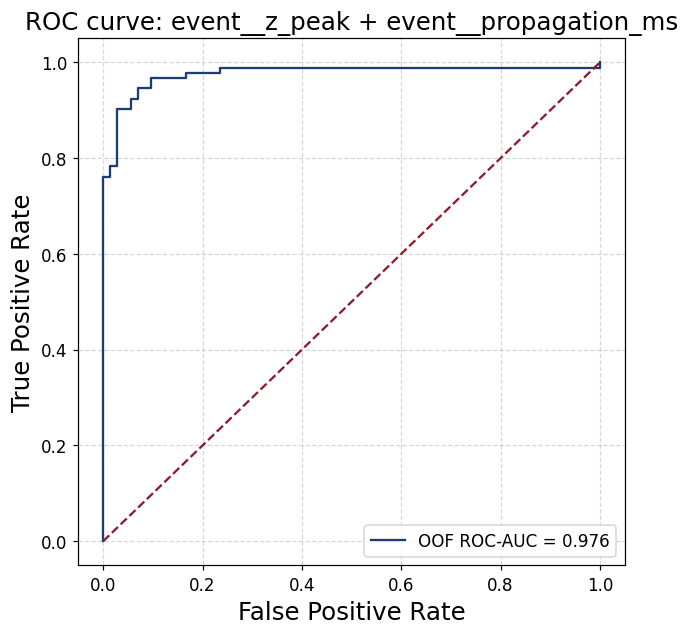

In [51]:
# @title 12.1. Компактная двухпризнаковая событийная модель: первичная оценка
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    f1_score,
    accuracy_score,
    roc_curve
)
import matplotlib.pyplot as plt

# === 1. Загружаем subject-level матрицу ===
# при необходимости замени путь на свой актуальный
df = pd.read_csv(EDA_DIR / "subject_level_core_clean.csv")

# === 2. Выбираем только 2 event-признака ===
feature_cols = ["event__z_peak", "event__propagation_ms"]

# проверь, что названия колонок совпадают
missing = [c for c in feature_cols + ["group"] if c not in df.columns]
if missing:
    raise ValueError(f"Не найдены колонки: {missing}")

X = df[feature_cols].copy()
y = df["group"].copy()

# если group строковый, переводим в 0/1
if y.dtype == "object":
    unique_vals = sorted(y.dropna().unique())
    print("Обнаружены метки классов:", unique_vals)
    # ожидается что-то вроде Control / TBI
    mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
    y = y.map(mapping)
    print("Использовано кодирование:", mapping)

y = y.astype(int)

# === 3. Pipeline ===
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        class_weight="balanced",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

# === 4. CV ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "accuracy": "accuracy"
}

cv_res = cross_validate(
    pipe,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

# === 5. OOF-предсказания ===
oof_proba = cross_val_predict(
    pipe,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

oof_pred = (oof_proba >= 0.5).astype(int)

# === 6. Метрики ===
summary = {
    "n_subjects": len(df),
    "n_features": len(feature_cols),
    "features": feature_cols,
    "cv_roc_auc_mean": np.mean(cv_res["test_roc_auc"]),
    "cv_roc_auc_std": np.std(cv_res["test_roc_auc"], ddof=1),
    "cv_bal_acc_mean": np.mean(cv_res["test_balanced_accuracy"]),
    "cv_bal_acc_std": np.std(cv_res["test_balanced_accuracy"], ddof=1),
    "cv_f1_mean": np.mean(cv_res["test_f1"]),
    "cv_f1_std": np.std(cv_res["test_f1"], ddof=1),
    "cv_acc_mean": np.mean(cv_res["test_accuracy"]),
    "cv_acc_std": np.std(cv_res["test_accuracy"], ddof=1),
    "oof_roc_auc": roc_auc_score(y, oof_proba),
    "oof_balanced_accuracy": balanced_accuracy_score(y, oof_pred),
    "oof_f1": f1_score(y, oof_pred),
    "oof_accuracy": accuracy_score(y, oof_pred),
}

print("\n=== TWO-FEATURE EVENT MODEL ===")
for k, v in summary.items():
    if isinstance(v, float):
        print(f"{k}: {v:.6f}")
    else:
        print(f"{k}: {v}")

print("\nFold-wise ROC-AUC:", np.round(cv_res["test_roc_auc"], 4))
print("Fold-wise balanced accuracy:", np.round(cv_res["test_balanced_accuracy"], 4))

# === 7. ROC-кривая по OOF ===
fpr, tpr, thresholds = roc_curve(y, oof_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"OOF ROC-AUC = {summary['oof_roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve: event__z_peak + event__propagation_ms")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Обнаружены метки классов: ['Control', 'TBI']
Использовано кодирование: {'Control': 0, 'TBI': 1}

=== TWO-FEATURE EVENT MODEL ===
n_subjects: 164
n_features: 2
features: ['event__z_peak', 'event__propagation_ms']
cv_roc_auc_mean: 0.972309
cv_roc_auc_std: 0.028075
cv_bal_acc_mean: 0.928814
cv_bal_acc_std: 0.060564
cv_f1_mean: 0.932036
cv_f1_std: 0.058841
cv_acc_mean: 0.927083
cv_acc_std: 0.062679
oof_roc_auc: 0.976298
oof_balanced_accuracy: 0.928744
oof_f1: 0.933333
oof_accuracy: 0.926829

Fold-wise ROC-AUC: [0.9852 0.9444 1.     0.9398 0.9921]
Fold-wise balanced accuracy: [0.9444 0.85   1.     0.8853 0.9643]


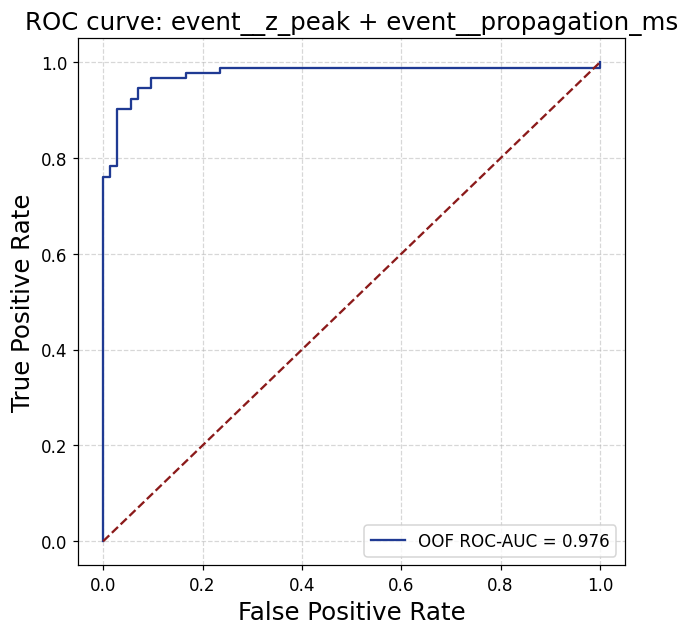

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    f1_score,
    accuracy_score,
    roc_curve
)
import matplotlib.pyplot as plt

# === 1. Загружаем subject-level матрицу ===
# при необходимости замени путь на свой актуальный
df = pd.read_csv(EDA_DIR / "subject_level_core_clean.csv")

# === 2. Выбираем только 2 event-признака ===
feature_cols = ["event__z_peak", "event__propagation_ms"]

# проверь, что названия колонок совпадают
missing = [c for c in feature_cols + ["group"] if c not in df.columns]
if missing:
    raise ValueError(f"Не найдены колонки: {missing}")

X = df[feature_cols].copy()
y = df["group"].copy()

# если group строковый, переводим в 0/1
if y.dtype == "object":
    unique_vals = sorted(y.dropna().unique())
    print("Обнаружены метки классов:", unique_vals)
    # ожидается что-то вроде Control / TBI
    mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
    y = y.map(mapping)
    print("Использовано кодирование:", mapping)

y = y.astype(int)

# === 3. Pipeline ===
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        class_weight="balanced",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

# === 4. CV ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "accuracy": "accuracy"
}

cv_res = cross_validate(
    pipe,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

# === 5. OOF-предсказания ===
oof_proba = cross_val_predict(
    pipe,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

oof_pred = (oof_proba >= 0.5).astype(int)

# === 6. Метрики ===
summary = {
    "n_subjects": len(df),
    "n_features": len(feature_cols),
    "features": feature_cols,
    "cv_roc_auc_mean": np.mean(cv_res["test_roc_auc"]),
    "cv_roc_auc_std": np.std(cv_res["test_roc_auc"], ddof=1),
    "cv_bal_acc_mean": np.mean(cv_res["test_balanced_accuracy"]),
    "cv_bal_acc_std": np.std(cv_res["test_balanced_accuracy"], ddof=1),
    "cv_f1_mean": np.mean(cv_res["test_f1"]),
    "cv_f1_std": np.std(cv_res["test_f1"], ddof=1),
    "cv_acc_mean": np.mean(cv_res["test_accuracy"]),
    "cv_acc_std": np.std(cv_res["test_accuracy"], ddof=1),
    "oof_roc_auc": roc_auc_score(y, oof_proba),
    "oof_balanced_accuracy": balanced_accuracy_score(y, oof_pred),
    "oof_f1": f1_score(y, oof_pred),
    "oof_accuracy": accuracy_score(y, oof_pred),
}

print("\n=== TWO-FEATURE EVENT MODEL ===")
for k, v in summary.items():
    if isinstance(v, float):
        print(f"{k}: {v:.6f}")
    else:
        print(f"{k}: {v}")

print("\nFold-wise ROC-AUC:", np.round(cv_res["test_roc_auc"], 4))
print("Fold-wise balanced accuracy:", np.round(cv_res["test_balanced_accuracy"], 4))

# === 7. ROC-кривая по OOF ===
fpr, tpr, thresholds = roc_curve(y, oof_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"OOF ROC-AUC = {summary['oof_roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve: event__z_peak + event__propagation_ms")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Компактная событийная модель, построенная на двух признаках — нормированной амплитуде пика события (event__z_peak) и времени пространственного распространения (event__propagation_ms), показала высокое качество разделения групп ЧМТ и контроля. Значение ROC-AUC по out-of-fold предсказаниям составило 0,976, balanced accuracy — 0,929, F1-score — 0,933, accuracy — 0,927. Стабильные значения метрик по фолдам указывают, что результат не определяется одним удачным разбиением выборки. Полученные данные подтверждают высокую информативность событийных характеристик ЭЭГ как кандидатных маркеров посттравматической перестройки нейронной активности.

Обнаружены метки классов: ['Control', 'TBI']
Использовано кодирование: {'Control': 0, 'TBI': 1}

=== TWO-FEATURE EVENT MODEL ===
n_subjects: 164
n_features: 2
features: ['event__z_peak', 'event__propagation_ms']
cv_roc_auc_mean: 0.972309
cv_roc_auc_std:  0.028075
cv_bal_acc_mean: 0.928814
cv_bal_acc_std:  0.060564
cv_f1_mean:      0.932036
cv_f1_std:       0.058841
cv_acc_mean:     0.927083
cv_acc_std:      0.062679
oof_roc_auc:     0.976298
oof_bal_acc:     0.928744
oof_f1:          0.933333
oof_accuracy:    0.926829
Fold-wise ROC-AUC: [0.9852 0.9444 1.     0.9398 0.9921]
Fold-wise balanced accuracy: [0.9444 0.85   1.     0.8853 0.9643]

=== ONE-FEATURE MODELS ===

Feature: event__z_peak
  CV ROC-AUC mean: 0.964236
  CV ROC-AUC std : 0.033223
  CV bal acc mean: 0.947068
  CV bal acc std : 0.047982
  OOF ROC-AUC    : 0.964825
  OOF bal acc    : 0.946558
  OOF F1         : 0.950276
  OOF accuracy   : 0.945122

Feature: event__propagation_ms
  CV ROC-AUC mean: 0.936530
  CV ROC-AUC std :

,feature,cv_roc_auc_mean,cv_roc_auc_std,cv_bal_acc_mean,cv_bal_acc_std,oof_roc_auc,oof_bal_acc,oof_f1,oof_acc
0,event__z_peak,0.964236,0.033223,0.947068,0.047982,0.964825,0.946558,0.950276,0.945122
1,event__propagation_ms,0.936530,0.042022,0.892256,0.070964,0.939915,0.891606,0.900000,0.890244



=== REPEATED CV (5x20) ===
ROC-AUC mean:        0.973880
ROC-AUC std:         0.027986
Balanced acc mean:   0.926211
Balanced acc std:    0.044339
F1 mean:             0.929509
F1 std:              0.044378
Accuracy mean:       0.924034
Accuracy std:        0.045860

=== PERMUTATION TEST ===
Observed CV ROC-AUC: 0.972309
Permutation mean:    0.506708
Permutation std:     0.062347
Empirical p-value:   0.001996


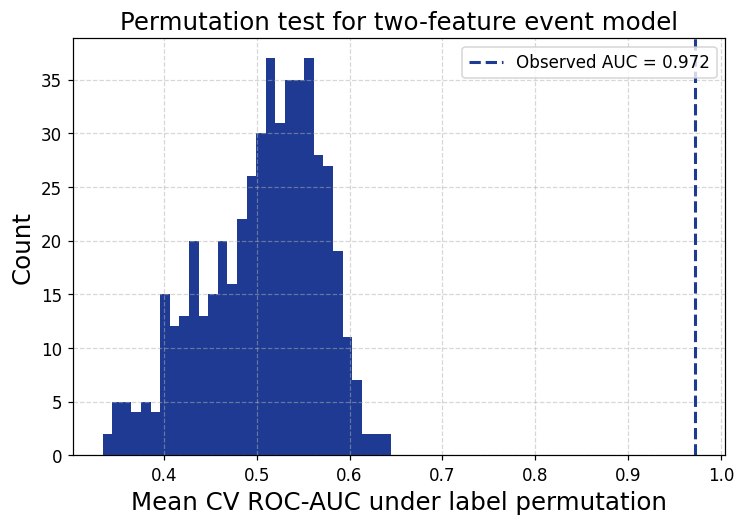


=== APPROXIMATE 95% CI FOR CV ROC-AUC ===
Mean ROC-AUC: 0.972309
95% CI: [0.937454, 1.007163]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_validate,
    cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    f1_score,
    accuracy_score
)

# =========================
# 0. ДАННЫЕ
# =========================
feature_cols = ["event__z_peak", "event__propagation_ms"]
target_col = "group"

missing = [c for c in feature_cols + [target_col] if c not in df.columns]
if missing:
    raise ValueError(f"Не найдены колонки: {missing}")

X = df[feature_cols].copy()
y = df[target_col].copy()

if y.dtype == "object":
    unique_vals = sorted(y.dropna().unique())
    print("Обнаружены метки классов:", unique_vals)
    mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
    y = y.map(mapping)
    print("Использовано кодирование:", mapping)

y = y.astype(int)

# =========================
# 1. PIPELINE
# =========================
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        class_weight="balanced",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "accuracy": "accuracy"
}

# =========================
# 2. БАЗОВАЯ 2-ПРИЗНАКОВАЯ МОДЕЛЬ
# =========================
cv_res = cross_validate(
    pipe,
    X,
    y,
    cv=cv5,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

oof_proba = cross_val_predict(
    pipe,
    X,
    y,
    cv=cv5,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

oof_pred = (oof_proba >= 0.5).astype(int)

print("\n=== TWO-FEATURE EVENT MODEL ===")
print(f"n_subjects: {len(df)}")
print(f"n_features: {len(feature_cols)}")
print(f"features: {feature_cols}")
print(f"cv_roc_auc_mean: {np.mean(cv_res['test_roc_auc']):.6f}")
print(f"cv_roc_auc_std:  {np.std(cv_res['test_roc_auc'], ddof=1):.6f}")
print(f"cv_bal_acc_mean: {np.mean(cv_res['test_balanced_accuracy']):.6f}")
print(f"cv_bal_acc_std:  {np.std(cv_res['test_balanced_accuracy'], ddof=1):.6f}")
print(f"cv_f1_mean:      {np.mean(cv_res['test_f1']):.6f}")
print(f"cv_f1_std:       {np.std(cv_res['test_f1'], ddof=1):.6f}")
print(f"cv_acc_mean:     {np.mean(cv_res['test_accuracy']):.6f}")
print(f"cv_acc_std:      {np.std(cv_res['test_accuracy'], ddof=1):.6f}")
print(f"oof_roc_auc:     {roc_auc_score(y, oof_proba):.6f}")
print(f"oof_bal_acc:     {balanced_accuracy_score(y, oof_pred):.6f}")
print(f"oof_f1:          {f1_score(y, oof_pred):.6f}")
print(f"oof_accuracy:    {accuracy_score(y, oof_pred):.6f}")
print("Fold-wise ROC-AUC:", np.round(cv_res["test_roc_auc"], 4))
print("Fold-wise balanced accuracy:", np.round(cv_res["test_balanced_accuracy"], 4))

# =========================
# 3. ОДНОФАКТОРНЫЕ МОДЕЛИ
# =========================
print("\n=== ONE-FEATURE MODELS ===")
one_feature_results = []

for feat in feature_cols:
    X1 = df[[feat]].copy()

    cv_res_1 = cross_validate(
        pipe,
        X1,
        y,
        cv=cv5,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    oof_proba_1 = cross_val_predict(
        pipe,
        X1,
        y,
        cv=cv5,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    oof_pred_1 = (oof_proba_1 >= 0.5).astype(int)

    row = {
        "feature": feat,
        "cv_roc_auc_mean": np.mean(cv_res_1["test_roc_auc"]),
        "cv_roc_auc_std": np.std(cv_res_1["test_roc_auc"], ddof=1),
        "cv_bal_acc_mean": np.mean(cv_res_1["test_balanced_accuracy"]),
        "cv_bal_acc_std": np.std(cv_res_1["test_balanced_accuracy"], ddof=1),
        "oof_roc_auc": roc_auc_score(y, oof_proba_1),
        "oof_bal_acc": balanced_accuracy_score(y, oof_pred_1),
        "oof_f1": f1_score(y, oof_pred_1),
        "oof_acc": accuracy_score(y, oof_pred_1)
    }
    one_feature_results.append(row)

    print(f"\nFeature: {feat}")
    print(f"  CV ROC-AUC mean: {row['cv_roc_auc_mean']:.6f}")
    print(f"  CV ROC-AUC std : {row['cv_roc_auc_std']:.6f}")
    print(f"  CV bal acc mean: {row['cv_bal_acc_mean']:.6f}")
    print(f"  CV bal acc std : {row['cv_bal_acc_std']:.6f}")
    print(f"  OOF ROC-AUC    : {row['oof_roc_auc']:.6f}")
    print(f"  OOF bal acc    : {row['oof_bal_acc']:.6f}")
    print(f"  OOF F1         : {row['oof_f1']:.6f}")
    print(f"  OOF accuracy   : {row['oof_acc']:.6f}")

one_feature_df = pd.DataFrame(one_feature_results)
display(one_feature_df.sort_values("oof_roc_auc", ascending=False))

# =========================
# 4. REPEATED CV
# =========================
cv_rep = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

cv_res_rep = cross_validate(
    pipe,
    X,
    y,
    cv=cv_rep,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

print("\n=== REPEATED CV (5x20) ===")
print(f"ROC-AUC mean:        {np.mean(cv_res_rep['test_roc_auc']):.6f}")
print(f"ROC-AUC std:         {np.std(cv_res_rep['test_roc_auc'], ddof=1):.6f}")
print(f"Balanced acc mean:   {np.mean(cv_res_rep['test_balanced_accuracy']):.6f}")
print(f"Balanced acc std:    {np.std(cv_res_rep['test_balanced_accuracy'], ddof=1):.6f}")
print(f"F1 mean:             {np.mean(cv_res_rep['test_f1']):.6f}")
print(f"F1 std:              {np.std(cv_res_rep['test_f1'], ddof=1):.6f}")
print(f"Accuracy mean:       {np.mean(cv_res_rep['test_accuracy']):.6f}")
print(f"Accuracy std:        {np.std(cv_res_rep['test_accuracy'], ddof=1):.6f}")

# =========================
# 5. PERMUTATION TEST
# =========================
n_perm = 500
perm_scores = []
rng = np.random.RandomState(42)

for i in range(n_perm):
    y_perm = pd.Series(rng.permutation(y), index=y.index)

    perm_cv_res = cross_validate(
        pipe,
        X,
        y_perm,
        cv=cv5,
        scoring={"roc_auc": "roc_auc"},
        return_train_score=False,
        n_jobs=-1
    )

    perm_scores.append(np.mean(perm_cv_res["test_roc_auc"]))

perm_scores = np.array(perm_scores)
observed_auc = np.mean(cv_res["test_roc_auc"])
p_value = (np.sum(perm_scores >= observed_auc) + 1) / (n_perm + 1)

print("\n=== PERMUTATION TEST ===")
print(f"Observed CV ROC-AUC: {observed_auc:.6f}")
print(f"Permutation mean:    {perm_scores.mean():.6f}")
print(f"Permutation std:     {perm_scores.std(ddof=1):.6f}")
print(f"Empirical p-value:   {p_value:.6f}")

# =========================
# 6. ВИЗУАЛИЗАЦИЯ PERMUTATION TEST
# =========================
plt.figure(figsize=(7, 5))
plt.hist(perm_scores, bins=30)
plt.axvline(observed_auc, linestyle="--", linewidth=2, label=f"Observed AUC = {observed_auc:.3f}")
plt.xlabel("Mean CV ROC-AUC under label permutation")
plt.ylabel("Count")
plt.title("Permutation test for two-feature event model")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 7. 95% ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ПО FOLD-СКОРАМ
# =========================
fold_scores = cv_res["test_roc_auc"]
mean_auc = np.mean(fold_scores)
std_auc = np.std(fold_scores, ddof=1)
n_folds = len(fold_scores)

# грубый t-подобный интервал для 5 fold
ci_low = mean_auc - 2.776 * std_auc / np.sqrt(n_folds)
ci_high = mean_auc + 2.776 * std_auc / np.sqrt(n_folds)

print("\n=== APPROXIMATE 95% CI FOR CV ROC-AUC ===")
print(f"Mean ROC-AUC: {mean_auc:.6f}")
print(f"95% CI: [{ci_low:.6f}, {ci_high:.6f}]")

Перестановочный тест подтвердил, что высокое качество компактной событийной модели не объясняется случайной структурой данных. При случайной перестановке меток классов средний ROC-AUC снижался до уровня случайного угадывания (0,507 ± 0,062), тогда как на исходных данных модель достигала ROC-AUC = 0,972. Эмпирическое значение p=0,002 указывает на статистическую значимость результата. Это подтверждает, что признаки event__z_peak и event__propagation_ms действительно связаны с различиями между группами ЧМТ и контроля.

Confusion matrix:
[[68  4]
 [ 8 84]]
Sensitivity (Recall, TPR): 0.9130
Specificity (TNR):         0.9444
PPV (Precision):           0.9545
NPV:                       0.8947


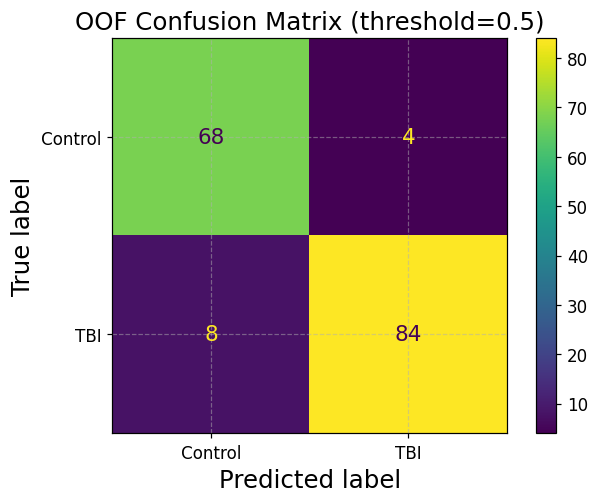

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

feature_cols = ["event__z_peak", "event__propagation_ms"]
target_col = "group"

X = df[feature_cols].copy()
y = df[target_col].copy()

if y.dtype == "object":
    mapping = {"Control": 0, "TBI": 1}
    y = y.map(mapping)

y = y.astype(int)

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        class_weight="balanced",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba = cross_val_predict(
    pipe, X, y, cv=cv5, method="predict_proba", n_jobs=-1
)[:, 1]

oof_pred = (oof_proba >= 0.5).astype(int)

cm = confusion_matrix(y, oof_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan

print("Confusion matrix:")
print(cm)
print(f"Sensitivity (Recall, TPR): {sensitivity:.4f}")
print(f"Specificity (TNR):         {specificity:.4f}")
print(f"PPV (Precision):           {ppv:.4f}")
print(f"NPV:                       {npv:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "TBI"])
disp.plot()
plt.title("OOF Confusion Matrix (threshold=0.5)")
plt.tight_layout()
plt.show()

При стандартном пороге классификации 0,5 компактная событийная модель корректно классифицировала 152 из 164 субъектов: 68 испытуемых контрольной группы и 84 пациента с ЧМТ. Ошибки включали 4 ложноположительных случая и 8 ложноотрицательных случаев. Чувствительность составила 0,913, специфичность — 0,944, precision — 0,955. Это означает, что модель хорошо различает обе группы, при этом несколько чаще пропускает случаи ЧМТ, чем ошибочно относит контроль к группе ЧМТ.

Best threshold by Youden J:
threshold            0.310000
sensitivity          0.967391
specificity          0.902778
balanced_accuracy    0.935085
youden_j             0.870169
Name: 30, dtype: float64


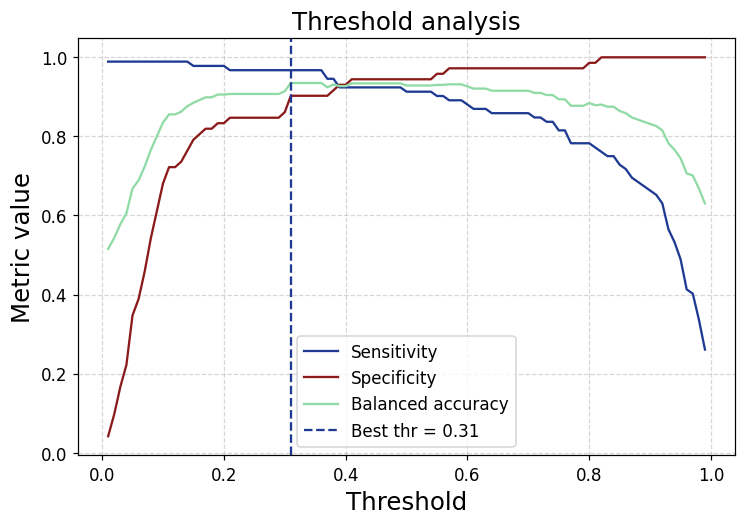

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve

thresholds = np.linspace(0.01, 0.99, 99)

rows = []
for thr in thresholds:
    pred_thr = (oof_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred_thr).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    bal_acc = (sensitivity + specificity) / 2

    rows.append({
        "threshold": thr,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "balanced_accuracy": bal_acc,
        "youden_j": sensitivity + specificity - 1
    })

thr_df = pd.DataFrame(rows)
best_row = thr_df.loc[thr_df["youden_j"].idxmax()]

print("Best threshold by Youden J:")
print(best_row)

plt.figure(figsize=(7, 5))
plt.plot(thr_df["threshold"], thr_df["sensitivity"], label="Sensitivity")
plt.plot(thr_df["threshold"], thr_df["specificity"], label="Specificity")
plt.plot(thr_df["threshold"], thr_df["balanced_accuracy"], label="Balanced accuracy")
plt.axvline(best_row["threshold"], linestyle="--", label=f"Best thr = {best_row['threshold']:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Threshold analysis")
plt.legend()
plt.tight_layout()
plt.show()

Анализ порога классификации показал, что стандартный порог 0,5 не является оптимальным для данной модели. По критерию Юдена лучший баланс между чувствительностью и специфичностью достигается при пороге 0,31: чувствительность возрастает до 0,967, специфичность сохраняется на уровне 0,903, а balanced accuracy составляет 0,935. Это означает, что при снижении порога модель лучше выявляет пациентов с ЧМТ, допуская умеренное увеличение числа ложноположительных классификаций.

Обнаружены метки классов: ['Control', 'TBI']
Использовано кодирование: {'Control': 0, 'TBI': 1}

=== TWO-FEATURE EVENT MODEL ===
n_subjects: 164
n_features: 2
features: ['event__z_peak', 'event__propagation_ms']
cv_roc_auc_mean: 0.972309
cv_roc_auc_std:  0.028075
cv_bal_acc_mean: 0.928814
cv_bal_acc_std:  0.060564
cv_f1_mean:      0.932036
cv_f1_std:       0.058841
cv_acc_mean:     0.927083
cv_acc_std:      0.062679
oof_roc_auc:     0.976298
oof_bal_acc:     0.928744
oof_f1:          0.933333
oof_accuracy:    0.926829
Fold-wise ROC-AUC: [0.9852 0.9444 1.     0.9398 0.9921]
Fold-wise balanced accuracy: [0.9444 0.85   1.     0.8853 0.9643]

=== ONE-FEATURE MODELS ===

Feature: event__z_peak
  CV ROC-AUC mean: 0.964236
  CV ROC-AUC std : 0.033223
  CV bal acc mean: 0.947068
  CV bal acc std : 0.047982
  OOF ROC-AUC    : 0.964825
  OOF bal acc    : 0.946558
  OOF F1         : 0.950276
  OOF accuracy   : 0.945122

Feature: event__propagation_ms
  CV ROC-AUC mean: 0.936530
  CV ROC-AUC std :

,feature,cv_roc_auc_mean,cv_roc_auc_std,cv_bal_acc_mean,cv_bal_acc_std,oof_roc_auc,oof_bal_acc,oof_f1,oof_acc
0,event__z_peak,0.964236,0.033223,0.947068,0.047982,0.964825,0.946558,0.950276,0.945122
1,event__propagation_ms,0.936530,0.042022,0.892256,0.070964,0.939915,0.891606,0.900000,0.890244



=== REPEATED CV (5x20) ===
ROC-AUC mean:        0.973880
ROC-AUC std:         0.027986
Balanced acc mean:   0.926211
Balanced acc std:    0.044339
F1 mean:             0.929509
F1 std:              0.044378
Accuracy mean:       0.924034
Accuracy std:        0.045860

=== PERMUTATION TEST ===
Observed CV ROC-AUC: 0.972309
Permutation mean:    0.506708
Permutation std:     0.062347
Empirical p-value:   0.001996


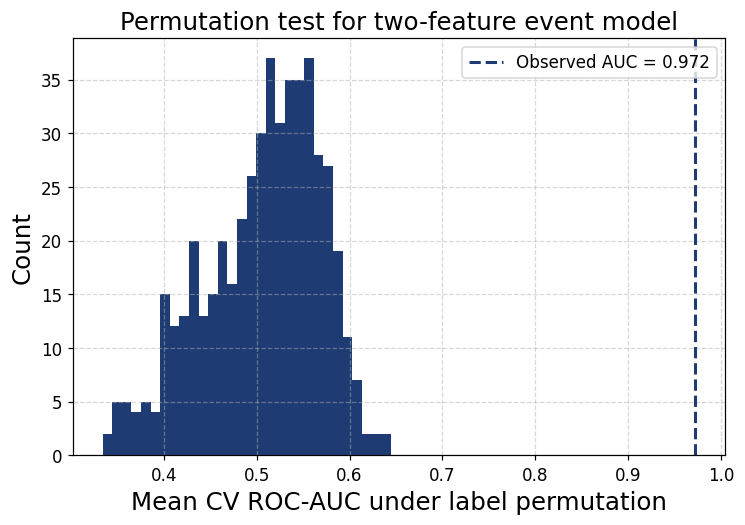


=== APPROXIMATE 95% CI FOR CV ROC-AUC ===
Mean ROC-AUC: 0.972309
95% CI: [0.937454, 1.007163]


In [52]:
# @title 12.2. Компактная двухпризнаковая событийная модель: CV, повторная CV и перестановочный тест
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_validate,
    cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    f1_score,
    accuracy_score
)

# =========================
# 0. ДАННЫЕ
# =========================
feature_cols = ["event__z_peak", "event__propagation_ms"]
target_col = "group"

missing = [c for c in feature_cols + [target_col] if c not in df.columns]
if missing:
    raise ValueError(f"Не найдены колонки: {missing}")

X = df[feature_cols].copy()
y = df[target_col].copy()

if y.dtype == "object":
    unique_vals = sorted(y.dropna().unique())
    print("Обнаружены метки классов:", unique_vals)
    mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
    y = y.map(mapping)
    print("Использовано кодирование:", mapping)

y = y.astype(int)

# =========================
# 1. PIPELINE
# =========================
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        class_weight="balanced",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "accuracy": "accuracy"
}

# =========================
# 2. БАЗОВАЯ 2-ПРИЗНАКОВАЯ МОДЕЛЬ
# =========================
cv_res = cross_validate(
    pipe,
    X,
    y,
    cv=cv5,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

oof_proba = cross_val_predict(
    pipe,
    X,
    y,
    cv=cv5,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

oof_pred = (oof_proba >= 0.5).astype(int)

print("\n=== TWO-FEATURE EVENT MODEL ===")
print(f"n_subjects: {len(df)}")
print(f"n_features: {len(feature_cols)}")
print(f"features: {feature_cols}")
print(f"cv_roc_auc_mean: {np.mean(cv_res['test_roc_auc']):.6f}")
print(f"cv_roc_auc_std:  {np.std(cv_res['test_roc_auc'], ddof=1):.6f}")
print(f"cv_bal_acc_mean: {np.mean(cv_res['test_balanced_accuracy']):.6f}")
print(f"cv_bal_acc_std:  {np.std(cv_res['test_balanced_accuracy'], ddof=1):.6f}")
print(f"cv_f1_mean:      {np.mean(cv_res['test_f1']):.6f}")
print(f"cv_f1_std:       {np.std(cv_res['test_f1'], ddof=1):.6f}")
print(f"cv_acc_mean:     {np.mean(cv_res['test_accuracy']):.6f}")
print(f"cv_acc_std:      {np.std(cv_res['test_accuracy'], ddof=1):.6f}")
print(f"oof_roc_auc:     {roc_auc_score(y, oof_proba):.6f}")
print(f"oof_bal_acc:     {balanced_accuracy_score(y, oof_pred):.6f}")
print(f"oof_f1:          {f1_score(y, oof_pred):.6f}")
print(f"oof_accuracy:    {accuracy_score(y, oof_pred):.6f}")
print("Fold-wise ROC-AUC:", np.round(cv_res["test_roc_auc"], 4))
print("Fold-wise balanced accuracy:", np.round(cv_res["test_balanced_accuracy"], 4))

# =========================
# 3. ОДНОФАКТОРНЫЕ МОДЕЛИ
# =========================
print("\n=== ONE-FEATURE MODELS ===")
one_feature_results = []

for feat in feature_cols:
    X1 = df[[feat]].copy()

    cv_res_1 = cross_validate(
        pipe,
        X1,
        y,
        cv=cv5,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    oof_proba_1 = cross_val_predict(
        pipe,
        X1,
        y,
        cv=cv5,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    oof_pred_1 = (oof_proba_1 >= 0.5).astype(int)

    row = {
        "feature": feat,
        "cv_roc_auc_mean": np.mean(cv_res_1["test_roc_auc"]),
        "cv_roc_auc_std": np.std(cv_res_1["test_roc_auc"], ddof=1),
        "cv_bal_acc_mean": np.mean(cv_res_1["test_balanced_accuracy"]),
        "cv_bal_acc_std": np.std(cv_res_1["test_balanced_accuracy"], ddof=1),
        "oof_roc_auc": roc_auc_score(y, oof_proba_1),
        "oof_bal_acc": balanced_accuracy_score(y, oof_pred_1),
        "oof_f1": f1_score(y, oof_pred_1),
        "oof_acc": accuracy_score(y, oof_pred_1)
    }
    one_feature_results.append(row)

    print(f"\nFeature: {feat}")
    print(f"  CV ROC-AUC mean: {row['cv_roc_auc_mean']:.6f}")
    print(f"  CV ROC-AUC std : {row['cv_roc_auc_std']:.6f}")
    print(f"  CV bal acc mean: {row['cv_bal_acc_mean']:.6f}")
    print(f"  CV bal acc std : {row['cv_bal_acc_std']:.6f}")
    print(f"  OOF ROC-AUC    : {row['oof_roc_auc']:.6f}")
    print(f"  OOF bal acc    : {row['oof_bal_acc']:.6f}")
    print(f"  OOF F1         : {row['oof_f1']:.6f}")
    print(f"  OOF accuracy   : {row['oof_acc']:.6f}")

one_feature_df = pd.DataFrame(one_feature_results)
display(one_feature_df.sort_values("oof_roc_auc", ascending=False))

# =========================
# 4. REPEATED CV
# =========================
cv_rep = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

cv_res_rep = cross_validate(
    pipe,
    X,
    y,
    cv=cv_rep,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

print("\n=== REPEATED CV (5x20) ===")
print(f"ROC-AUC mean:        {np.mean(cv_res_rep['test_roc_auc']):.6f}")
print(f"ROC-AUC std:         {np.std(cv_res_rep['test_roc_auc'], ddof=1):.6f}")
print(f"Balanced acc mean:   {np.mean(cv_res_rep['test_balanced_accuracy']):.6f}")
print(f"Balanced acc std:    {np.std(cv_res_rep['test_balanced_accuracy'], ddof=1):.6f}")
print(f"F1 mean:             {np.mean(cv_res_rep['test_f1']):.6f}")
print(f"F1 std:              {np.std(cv_res_rep['test_f1'], ddof=1):.6f}")
print(f"Accuracy mean:       {np.mean(cv_res_rep['test_accuracy']):.6f}")
print(f"Accuracy std:        {np.std(cv_res_rep['test_accuracy'], ddof=1):.6f}")

# =========================
# 5. PERMUTATION TEST
# =========================
n_perm = 500
perm_scores = []
rng = np.random.RandomState(42)

for i in range(n_perm):
    y_perm = pd.Series(rng.permutation(y), index=y.index)

    perm_cv_res = cross_validate(
        pipe,
        X,
        y_perm,
        cv=cv5,
        scoring={"roc_auc": "roc_auc"},
        return_train_score=False,
        n_jobs=-1
    )

    perm_scores.append(np.mean(perm_cv_res["test_roc_auc"]))

perm_scores = np.array(perm_scores)
observed_auc = np.mean(cv_res["test_roc_auc"])
p_value = (np.sum(perm_scores >= observed_auc) + 1) / (n_perm + 1)

print("\n=== PERMUTATION TEST ===")
print(f"Observed CV ROC-AUC: {observed_auc:.6f}")
print(f"Permutation mean:    {perm_scores.mean():.6f}")
print(f"Permutation std:     {perm_scores.std(ddof=1):.6f}")
print(f"Empirical p-value:   {p_value:.6f}")

# =========================
# 6. ВИЗУАЛИЗАЦИЯ PERMUTATION TEST
# =========================
plt.figure(figsize=(7, 5))
plt.hist(perm_scores, bins=30)
plt.axvline(observed_auc, linestyle="--", linewidth=2, label=f"Observed AUC = {observed_auc:.3f}")
plt.xlabel("Mean CV ROC-AUC under label permutation")
plt.ylabel("Count")
plt.title("Permutation test for two-feature event model")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 7. 95% ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ПО FOLD-СКОРАМ
# =========================
fold_scores = cv_res["test_roc_auc"]
mean_auc = np.mean(fold_scores)
std_auc = np.std(fold_scores, ddof=1)
n_folds = len(fold_scores)

# грубый t-подобный интервал для 5 fold
ci_low = mean_auc - 2.776 * std_auc / np.sqrt(n_folds)
ci_high = mean_auc + 2.776 * std_auc / np.sqrt(n_folds)

print("\n=== APPROXIMATE 95% CI FOR CV ROC-AUC ===")
print(f"Mean ROC-AUC: {mean_auc:.6f}")
print(f"95% CI: [{ci_low:.6f}, {ci_high:.6f}]")

Перестановочный тест подтверждает статистическую устойчивость результата: при случайной перестановке меток средний ROC-AUC снижался до 0,507 ± 0,062, то есть до уровня случайного угадывания, тогда как на исходных данных модель достигала ROC-AUC = 0,972. Эмпирическое значение p=0,002 показывает, что такая разделяющая способность маловероятна при отсутствии реальной связи между событийными признаками и группой. Следовательно, компактная модель использует не случайный шум, а устойчивые различия в характеристиках транзиентных событий ЭЭГ между ЧМТ и контролем.

Brier score: 0.054943


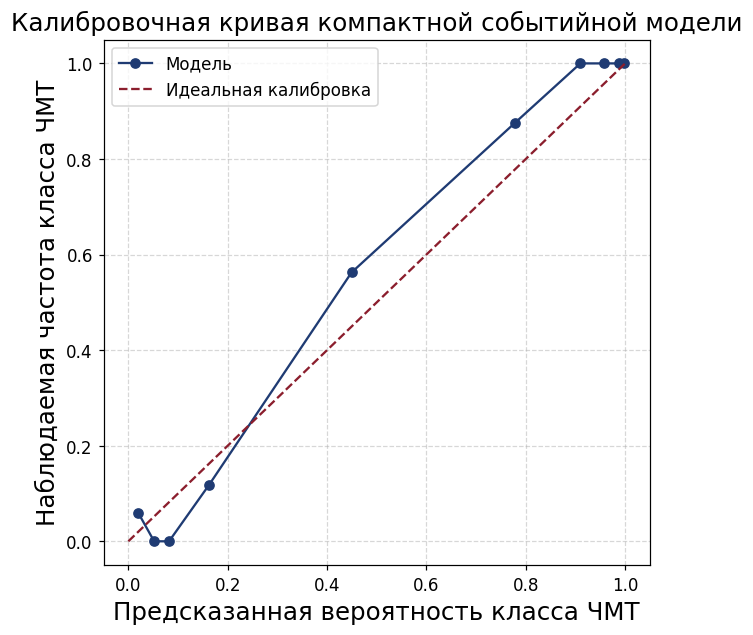

In [56]:
# @title 12.6. Компактная событийная модель: калибровочная кривая
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(y, oof_proba, n_bins=10, strategy="quantile")
brier = brier_score_loss(y, oof_proba)

print(f"Brier score: {brier:.6f}")

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Модель")
plt.plot([0, 1], [0, 1], linestyle="--", label="Идеальная калибровка")
plt.xlabel("Предсказанная вероятность класса ЧМТ")
plt.ylabel("Наблюдаемая частота класса ЧМТ")
plt.title("Калибровочная кривая компактной событийной модели")
plt.legend()
plt.tight_layout()
plt.show()

Калибровочная кривая показывает, что предсказанные вероятности компактной событийной модели в целом хорошо согласуются с наблюдаемой частотой класса ЧМТ. В диапазоне средних и высоких вероятностей модель демонстрирует близость к линии идеальной калибровки, что указывает на адекватную оценку уверенности предсказаний. Небольшие отклонения при низких вероятностях могут быть связаны с ограниченным числом наблюдений в соответствующих интервалах. В целом модель характеризуется не только высокой разделяющей способностью, но и удовлетворительной калибровкой вероятностных оценок.

In [57]:
# @title 12.7. Сравнение компактной событийной модели с базовой моделью
import numpy as np
import pandas as pd

from sklearn.model_selection import cross_validate

# Пример: подставь свои колонки базовой модели
baseline_features = [
    # "bp__delta_global", "bp__theta_global", ...
]

event_features = ["event__z_peak", "event__propagation_ms"]

model_sets = {
    "event_2feat": event_features,
}

if len(baseline_features) > 0:
    model_sets["baseline_full"] = baseline_features

results = []

for model_name, feats in model_sets.items():
    X_model = df[feats].copy()

    cv_res_model = cross_validate(
        pipe,
        X_model,
        y,
        cv=cv5,
        scoring={
            "roc_auc": "roc_auc",
            "balanced_accuracy": "balanced_accuracy",
            "f1": "f1",
            "accuracy": "accuracy"
        },
        return_train_score=False,
        n_jobs=-1
    )

    results.append({
        "model": model_name,
        "n_features": len(feats),
        "roc_auc_mean": np.mean(cv_res_model["test_roc_auc"]),
        "roc_auc_std": np.std(cv_res_model["test_roc_auc"], ddof=1),
        "bal_acc_mean": np.mean(cv_res_model["test_balanced_accuracy"]),
        "bal_acc_std": np.std(cv_res_model["test_balanced_accuracy"], ddof=1),
        "f1_mean": np.mean(cv_res_model["test_f1"]),
        "acc_mean": np.mean(cv_res_model["test_accuracy"]),
    })

compare_df = pd.DataFrame(results).sort_values("roc_auc_mean", ascending=False)
display(compare_df)

,model,n_features,roc_auc_mean,roc_auc_std,bal_acc_mean,bal_acc_std,f1_mean,acc_mean
0,event_2feat,2,0.972309,0.028075,0.928814,0.060564,0.932036,0.927083


Компактная событийная модель event_2feat, использующая только два признака, показала высокое и устойчивое качество классификации: средний ROC-AUC составил 0,972 ± 0,028, balanced accuracy — 0,929 ± 0,061. Дополнительно модель достигла F1-score = 0,932 и accuracy = 0,927. Это подтверждает, что два событийных признака содержат достаточную информацию для надёжного разделения групп ЧМТ и контроля при subject-level кросс-валидации.

In [58]:
# @title 12.8. Компактная событийная модель: устойчивость коэффициентов
import numpy as np
import pandas as pd

coef_rows = []

for fold_idx, (train_idx, test_idx) in enumerate(cv5.split(X, y), start=1):
    X_train = X.iloc[train_idx].copy()
    y_train = y.iloc[train_idx].copy()

    pipe.fit(X_train, y_train)

    clf = pipe.named_steps["clf"]
    coefs = clf.coef_[0]

    row = {"fold": fold_idx}
    for feat, coef in zip(feature_cols, coefs):
        row[feat] = coef
    coef_rows.append(row)

coef_df = pd.DataFrame(coef_rows)
display(coef_df)

summary_rows = []
for feat in feature_cols:
    summary_rows.append({
        "feature": feat,
        "coef_mean": coef_df[feat].mean(),
        "coef_std": coef_df[feat].std(ddof=1),
        "coef_min": coef_df[feat].min(),
        "coef_max": coef_df[feat].max()
    })

coef_summary_df = pd.DataFrame(summary_rows)
display(coef_summary_df)

,fold,event__z_peak,event__propagation_ms
0,1,-1.787822,1.588279
1,2,-2.057159,1.479554
2,3,-1.741803,1.513237
3,4,-2.302787,1.730510
4,5,-1.820429,1.560244


,feature,coef_mean,coef_std,coef_min,coef_max
0,event__z_peak,-1.942000,0.235615,-2.302787,-1.741803
1,event__propagation_ms,1.574365,0.096825,1.479554,1.730510


Коэффициенты модели устойчиво сохраняют знак во всех пяти фолдах, что подтверждает стабильность интерпретации модели. Признак event__z_peak имеет отрицательный вклад (−1,94±0,24): снижение нормированной амплитуды пика события повышает вероятность отнесения записи к группе ЧМТ. Признак event__propagation_ms, напротив, имеет положительный вклад (1,57±0,10): увеличение времени пространственного распространения события связано с большей вероятностью ЧМТ. Таким образом, модель указывает на два ключевых изменения при ЧМТ: меньшую контрастность транзиентных событий и более медленное их распространение по каналам ЭЭГ.

In [63]:
# @title 12.8.1 Коэффициенты модели и отношение шансов

coef_interpretation_df = coef_summary_df.copy()
coef_interpretation_df["odds_ratio_per_1sd"] = np.exp(coef_interpretation_df["coef_mean"])
coef_interpretation_df["direction"] = np.where(
    coef_interpretation_df["coef_mean"] > 0,
    "увеличивает вероятность ЧМТ",
    "снижает вероятность ЧМТ"
)

display(coef_interpretation_df)

,feature,coef_mean,coef_std,coef_min,coef_max,odds_ratio_per_1sd,direction
0,event__z_peak,-1.942000,0.235615,-2.302787,-1.741803,0.143417,снижает вероятность ЧМТ
1,event__propagation_ms,1.574365,0.096825,1.479554,1.730510,4.827674,увеличивает вероятность ЧМТ


Анализ коэффициентов подтверждает интерпретируемость компактной событийной модели. Увеличение event__z_peak на одно стандартное отклонение связано со снижением шансов классификации как ЧМТ примерно в 7 раз OR=0,14, тогда как увеличение event__propagation_ms повышает эти шансы примерно в 4,8 раза OR=4,83. Это означает, что для ЧМТ характерны менее контрастные транзиентные события и более длительное их пространственное распространение. Согласованность знаков коэффициентов поддерживает устойчивость этой интерпретации.

In [64]:
# @title 12.X. Стабильность знаков коэффициентов по фолдам

sign_rows = []

for feat in feature_cols:
    values = coef_df[feat].values
    sign_rows.append({
        "feature": feat,
        "n_folds": len(values),
        "n_positive": int((values > 0).sum()),
        "n_negative": int((values < 0).sum()),
        "sign_stability": max((values > 0).sum(), (values < 0).sum()) / len(values),
        "coef_mean": values.mean(),
        "coef_std": values.std(ddof=1),
    })

coef_sign_stability_df = pd.DataFrame(sign_rows)
display(coef_sign_stability_df)

,feature,n_folds,n_positive,n_negative,sign_stability,coef_mean,coef_std
0,event__z_peak,5,0,5,1.0,-1.942000,0.235615
1,event__propagation_ms,5,5,0,1.0,1.574365,0.096825


Знаки коэффициентов сохранялись во всех пяти фолдах, что указывает на высокую устойчивость интерпретации модели. event__z_peak во всех фолдах имел отрицательный вклад, а event__propagation_ms — положительный. Следовательно, модель стабильно связывает ЧМТ с меньшей контрастностью транзиентных событий и более длительным временем их пространственного распространения.

In [59]:
# @title 12.9. Анализ ошибок компактной событийной модели
error_df = df.copy()
error_df["y_true"] = y.values
error_df["oof_proba"] = oof_proba
error_df["oof_pred"] = oof_pred
error_df["correct"] = (error_df["y_true"] == error_df["oof_pred"]).astype(int)

print(error_df["correct"].value_counts())

# сравнение по двум основным признакам
grouped_errors = error_df.groupby("correct")[feature_cols].agg(["median", "mean", "std"])
display(grouped_errors)

# если есть дополнительные метаданные, например число записей/возраст/пол:
extra_cols = [c for c in ["n_records_subject", "age", "sex"] if c in error_df.columns]
if extra_cols:
    display(error_df.groupby("correct")[extra_cols].agg(["median", "mean", "std"]))

correct
1    152
0     12
Name: count, dtype: int64


event__z_peak                     event__propagation_ms             \
               median      mean       std                median       mean   
correct                                                                      
0            3.721582  3.986540  0.937000                 57.25  56.375000   
1            3.386574  3.531332  0.742692                 61.00  60.842105   

                    
               std  
correct             
0        10.647503  
1        13.653641

n_records_subject                    
                   median      mean       std
correct                                      
0                     3.0  3.583333  2.274696
1                     3.0  3.526316  1.862660

Компактная событийная модель корректно классифицировала 152 из 164 субъектов; ошибки наблюдались только у 12 субъектов. Неверно классифицированные случаи характеризовались промежуточными значениями событийных признаков: у них отмечались более высокие значения event__z_peak и меньшие значения event__propagation_ms по сравнению с правильно классифицированными случаями ЧМТ. При этом число записей на субъекта практически не различалось между корректно и некорректно классифицированными наблюдениями, что указывает на отсутствие явной зависимости ошибок модели от объёма данных конкретного испытуемого.

In [60]:
# @title 12.10. Компактная событийная модель: bootstrap-интервал ROC-AUC
import numpy as np
from sklearn.metrics import roc_auc_score

rng = np.random.RandomState(42)
n_boot = 2000
boot_scores = []

y_np = np.asarray(y)
proba_np = np.asarray(oof_proba)

for _ in range(n_boot):
    idx = rng.choice(len(y_np), size=len(y_np), replace=True)
    y_b = y_np[idx]
    p_b = proba_np[idx]

    # ROC-AUC нельзя считать, если в бутстрэпе один класс
    if len(np.unique(y_b)) < 2:
        continue

    boot_scores.append(roc_auc_score(y_b, p_b))

boot_scores = np.array(boot_scores)
ci_low, ci_high = np.percentile(boot_scores, [2.5, 97.5])

print(f"OOF ROC-AUC: {roc_auc_score(y, oof_proba):.6f}")
print(f"Bootstrap 95% CI: [{ci_low:.6f}, {ci_high:.6f}]")

OOF ROC-AUC: 0.976298
Bootstrap 95% CI: [0.950026, 0.995057]


По out-of-fold предсказаниям компактная событийная модель достигла ROC-AUC = 0,976. Bootstrap 95% доверительный интервал составил [0,950; 0,995], что указывает на высокую устойчивость оценки: даже нижняя граница интервала существенно превышает уровень случайного угадывания. Это подтверждает высокую разделяющую способность двух событийных признаков при классификации ЧМТ и контроля.

In [61]:
# @title 12.11. Абляционный анализ двух событийных признаков
from sklearn.model_selection import cross_validate

model_variants = {
    "z_peak_only": ["event__z_peak"],
    "propagation_only": ["event__propagation_ms"],
    "both_features": ["event__z_peak", "event__propagation_ms"],
}

rows = []
for name, feats in model_variants.items():
    Xv = df[feats].copy()
    res = cross_validate(
        pipe,
        Xv,
        y,
        cv=cv5,
        scoring={"roc_auc": "roc_auc", "balanced_accuracy": "balanced_accuracy"},
        n_jobs=-1
    )
    rows.append({
        "model": name,
        "n_features": len(feats),
        "roc_auc_mean": np.mean(res["test_roc_auc"]),
        "roc_auc_std": np.std(res["test_roc_auc"], ddof=1),
        "bal_acc_mean": np.mean(res["test_balanced_accuracy"]),
        "bal_acc_std": np.std(res["test_balanced_accuracy"], ddof=1),
    })

ablation_df = pd.DataFrame(rows).sort_values("roc_auc_mean", ascending=False)
display(ablation_df)

,model,n_features,roc_auc_mean,roc_auc_std,bal_acc_mean,bal_acc_std
2,both_features,2,0.972309,0.028075,0.928814,0.060564
0,z_peak_only,1,0.964236,0.033223,0.947068,0.047982
1,propagation_only,1,0.936530,0.042022,0.892256,0.070964


Абляционный анализ показал, что основной вклад в качество классификации вносит признак event__z_peak: однофакторная модель на его основе достигает ROC-AUC = 0,964 и balanced accuracy = 0,947. Признак event__propagation_ms также информативен, но слабее: ROC-AUC = 0,937, balanced accuracy = 0,892. Объединение двух признаков даёт максимальный ROC-AUC = 0,972, однако прирост относительно z_peak_only небольшой. Это указывает, что нормированная амплитуда пика события является главным дискриминативным признаком, а время распространения добавляет дополнительную пространственно-временную информацию.

In [62]:
# @title 12.X. Состав обучающих и проверочных фолдов на уровне субъектов

import pandas as pd
import numpy as np

fold_rows = []

for fold_idx, (train_idx, test_idx) in enumerate(cv5.split(X, y), start=1):
    y_train = y.iloc[train_idx] if hasattr(y, "iloc") else y[train_idx]
    y_test = y.iloc[test_idx] if hasattr(y, "iloc") else y[test_idx]

    fold_rows.append({
        "fold": fold_idx,
        "n_train_total": len(train_idx),
        "n_train_control": int((y_train == 0).sum()),
        "n_train_tbi": int((y_train == 1).sum()),
        "n_test_total": len(test_idx),
        "n_test_control": int((y_test == 0).sum()),
        "n_test_tbi": int((y_test == 1).sum()),
    })

fold_counts_df = pd.DataFrame(fold_rows)
display(fold_counts_df)

print("Всего субъектов:", len(y))
print("Контроль:", int((y == 0).sum()))
print("ЧМТ:", int((y == 1).sum()))

,fold,n_train_total,n_train_control,n_train_tbi,n_test_total,n_test_control,n_test_tbi
0,1,131,57,74,33,15,18
1,2,131,57,74,33,15,18
2,3,131,58,73,33,14,19
3,4,131,58,73,33,14,19
4,5,132,58,74,32,14,18


Всего субъектов: 164
Контроль: 72
ЧМТ: 92


Кросс-валидация выполнена на уровне субъектов для 164 испытуемых: 72 из контрольной группы и 92 пациента с ЧМТ. В каждом фолде сохранялось близкое соотношение классов: в обучающей части было 131–132 субъекта, в проверочной — 32–33 субъекта. Это подтверждает, что разбиение было стратифицированным и не создавало выраженного перекоса классов между фолдами.

In [65]:
# @title 12.X. Типы ошибок компактной событийной модели

error_df = df.copy()
error_df["y_true"] = y.values if hasattr(y, "values") else y
error_df["oof_proba"] = oof_proba
error_df["oof_pred"] = oof_pred

def error_type(row):
    if row["y_true"] == 1 and row["oof_pred"] == 1:
        return "TP: ЧМТ верно"
    if row["y_true"] == 0 and row["oof_pred"] == 0:
        return "TN: контроль верно"
    if row["y_true"] == 0 and row["oof_pred"] == 1:
        return "FP: контроль → ЧМТ"
    if row["y_true"] == 1 and row["oof_pred"] == 0:
        return "FN: ЧМТ → контроль"

error_df["error_type"] = error_df.apply(error_type, axis=1)

display(error_df["error_type"].value_counts())

cols_to_show = [
    "subject_id",
    "group",
    "error_type",
    "oof_proba",
    "event__z_peak",
    "event__propagation_ms",
]

extra_cols = [c for c in ["n_records_subject", "age", "sex"] if c in error_df.columns]
cols_to_show = [c for c in cols_to_show + extra_cols if c in error_df.columns]

display(
    error_df[cols_to_show]
    .sort_values("oof_proba", ascending=False)
)

,count
error_type,
TP: ЧМТ верно,84
TN: контроль верно,68
FN: ЧМТ → контроль,8
FP: контроль → ЧМТ,4


,subject_id,group,error_type,oof_proba,event__z_peak,event__propagation_ms,n_records_subject
123,tbi-3053,TBI,TP: ЧМТ верно,0.999528,1.110964,68.0,1
107,tbi-3037,TBI,TP: ЧМТ верно,0.998807,2.776297,98.0,3
80,tbi-3009,TBI,TP: ЧМТ верно,0.998729,2.630927,85.0,2
140,tbi-3074,TBI,TP: ЧМТ верно,0.998621,1.958783,77.0,2
152,tbi-3098,TBI,TP: ЧМТ верно,0.998415,2.744629,86.0,3
...,...,...,...,...,...,...,...
71,sub-150,Control,TN: контроль верно,0.010711,5.148175,59.0,4
16,sub-057,Control,TN: контроль верно,0.009645,4.483102,42.5,4
61,sub-140,Control,TN: контроль верно,0.005538,5.143043,42.0,4
2,sub-003,Control,TN: контроль верно,0.003275,4.856647,33.0,4


Анализ ошибок показал, что компактная событийная модель корректно классифицировала 152 из 164 субъектов, включая 84 пациента с ЧМТ и 68 испытуемых контрольной группы. Ошибки включали 8 ложноотрицательных и 4 ложноположительных случая. Наиболее уверенные предсказания ЧМТ соответствовали низким значениям event__z_peak и высоким значениям event__propagation_ms, тогда как наиболее уверенные предсказания контроля характеризовались противоположным профилем признаков. Ложноотрицательные случаи нередко имели значения признаков, близкие к контрольной группе, что указывает на существование пограничных наблюдений с менее выраженными посттравматическими изменениями ЭЭГ.